# H-Neurons em Modelos de Linguagem de Pequena Escala
## Investigação da Existência de Neurônios Associados a Alucinações na Família Pythia

---

### Contexto e Motivação

Este notebook implementa e estende a metodologia proposta por **Gao et al. (2025)** no artigo *"H-Neurons: On the Existence, Impact, and Origin of Hallucination-Associated Neurons in LLMs"* (arXiv:2512.01797).

O artigo original demonstrou que, em LLMs grandes (7B–70B parâmetros), um subconjunto extremamente esparso de neurônios — menos de **0,1% do total** — consegue prever com alta acurácia se o modelo vai alucinar ou não. Esses neurônios foram denominados **H-Neurons** (Hallucination-associated Neurons).

A descoberta é feita "de dentro para fora": em vez de observar apenas o comportamento externo do modelo, o método mergulha nas ativações internas das camadas feedforward (FFN) para encontrar um sinal neural que precede a alucinação.

### A Lacuna que Este Projeto Preenche

O artigo original **só testou modelos grandes** (mínimo: Mistral-7B). Isso deixa uma pergunta sem resposta:

> **H-Neurons existem em modelos de pequena escala? Ou são um fenômeno emergente que só aparece acima de certo limiar de parâmetros?**

Este projeto investiga essa questão usando a família **Pythia** (EleutherAI), modelos de 70M, 160M e 410M parâmetros, projetados especificamente para pesquisa de interpretabilidade e viáveis em CPU.

### Hipóteses

- **H1 (Existência):** H-Neurons existem mesmo em modelos pequenos, indicando que o fenômeno é fundamental à arquitetura transformer.
- **H2 (Escala):** A acurácia do classificador baseado em H-Neurons aumenta com o tamanho do modelo, mesmo dentro da faixa pequena.
- **H3 (Generalização):** H-Neurons identificados com TriviaQA generalizam para domínios diferentes (NQ-Open).

### Como Usar Este Notebook

O notebook é estruturado em **10 blocos independentes**. Os blocos 0–9 devem ser rodados **um modelo por vez** (escolha o modelo na Célula 2.2). Após rodar os três modelos e salvar os resultados, o Bloco 10 realiza a análise comparativa.

**Ordem recomendada:**
1. Sessão 1: rodar com `pythia-70m` → salvar resultados
2. Sessão 2: rodar com `pythia-160m` → salvar resultados
3. Sessão 3: rodar com `pythia-410m` → salvar resultados
4. Sessão 4: rodar apenas o Bloco 10 para comparação

### Referências
- Gao et al. (2025). H-Neurons. arXiv:2512.01797
- Biderman et al. (2023). Pythia: A Suite for Analyzing Large Language Models. arXiv:2304.01373
- Joshi et al. (2017). TriviaQA. ACL 2017.

---

## Bloco 0.5 — Montagem do Google Drive

Este bloco monta o Google Drive na sessão do Colab e redireciona todos os caminhos de saída para uma pasta persistente no Drive.

**Por que isso é fundamental?**
O Colab gratuito encerra a sessão após ~90 minutos de inatividade ou ~12 horas no total. Sem o Drive montado, todos os arquivos salvos em `/content/` — incluindo o dataset contrastivo, as ativações extraídas e os resultados do classificador — são **permanentemente perdidos** quando a sessão cai. Com o Drive montado, esses arquivos ficam persistidos na sua conta Google e podem ser retomados em sessões futuras sem precisar re-executar o pipeline do zero.

**Estrutura de pastas criada no Drive:**
```
Meu Drive/
  h_neurons_project/
    pythia-70m_contrastive_dataset.json
    pythia-70m_cett_features.npz
    pythia-70m_h_neurons.json
    pythia-70m_metrics.json
    pythia-70m_final_results.json
    pythia-160m_*  /  pythia-410m_*
    fig1_accuracy_by_scale.png
    fig2_sparsity_by_scale.png
    fig3_h_neurons_by_layer.png
```

**Importante:** Execute este bloco **sempre** ao iniciar uma nova sessão do Colab, antes de qualquer outro bloco. Se os arquivos de sessões anteriores já existirem no Drive, os blocos subsequentes os reconhecerão automaticamente.


### Célula 0.5.1 — Montagem do Drive e Configuração de Paths

Monta o Google Drive e define o diretório raiz do projeto. O Colab pedirá permissão de acesso ao Drive — clique em **Conectar ao Google Drive** e autorize com sua conta Google.

Se preferir não usar o Drive (ex: experimento rápido ou ambiente local Jupyter), defina `USE_DRIVE = False`. Nesse caso os arquivos serão salvos em `/content/h_neurons_results/` e **serão perdidos** ao encerrar a sessão.


In [2]:
import os

# ============================================================
# DEFINA AQUI SE QUER USAR O GOOGLE DRIVE
# True  -> monta o Drive e salva tudo la (RECOMENDADO no Colab)
# False -> salva localmente no Colab (arquivos perdidos ao fechar sessao)
# ============================================================
USE_DRIVE = True

if USE_DRIVE:
    # Importa o modulo de integracao do Colab com o Google Drive
    # Ao executar, o Colab exibira um popup de autorizacao.
    # Clique em 'Conectar ao Google Drive' e faca login com sua conta.
    # Apos autorizar, o Drive estara disponivel em /content/drive/MyDrive/
    from google.colab import drive
    drive.mount('/content/drive')

    # Diretorio raiz do projeto no Drive.
    # Altere o nome da pasta se quiser organizar diferente.
    DRIVE_PROJECT_DIR = '/content/drive/MyDrive/IA376/h_neurons_project'

    # Cria a pasta do projeto no Drive caso ainda nao exista
    os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

    # RESULTS_DIR e a variavel global usada por todos os blocos seguintes
    # para saber onde salvar e carregar arquivos
    RESULTS_DIR = DRIVE_PROJECT_DIR

    print('Drive montado com sucesso.')
    print(f'Arquivos do projeto serao salvos em: {RESULTS_DIR}')

    # Lista arquivos ja existentes (de sessoes anteriores)
    existing = sorted(os.listdir(RESULTS_DIR))
    if existing:
        print(f'\nArquivos encontrados de sessoes anteriores ({len(existing)} arquivos):')
        for fname in existing:
            fpath = os.path.join(RESULTS_DIR, fname)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {fname}  ({size_kb:.1f} KB)')
    else:
        print('\nDiretorio vazio -- este e o primeiro experimento.')

else:
    # Sem Drive: salva localmente no Colab
    # ATENCAO: arquivos serao perdidos ao encerrar a sessao!
    RESULTS_DIR = '/content/drive/MyDrive/IA376/h_neurons_results'
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print('AVISO: Google Drive NAO montado.')
    print(f'Arquivos salvos localmente em: {RESULTS_DIR}')
    print('ATENCAO: estes arquivos serao perdidos ao encerrar a sessao!')

print(f'\nRESULTS_DIR = {RESULTS_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado com sucesso.
Arquivos do projeto serao salvos em: /content/drive/MyDrive/IA376/h_neurons_project

Arquivos encontrados de sessoes anteriores (144 arquivos):
  .ipynb_checkpoints  (4.0 KB)
  fig1_accuracy_by_scale.png  (122.3 KB)
  fig1_h_neurons_por_camada.png  (63.9 KB)
  fig2_h_neurons_vs_baseline.png  (65.3 KB)
  fig2_sparsity_by_scale.png  (64.5 KB)
  fig3_esparsidade.png  (53.7 KB)
  fig3_h_neurons_by_layer.png  (293.2 KB)
  fig4_matriz_confusao.png  (33.1 KB)
  pythia-1.4b_checkpoint.json  (97.9 KB)
  pythia-1.4b_contrastive_dataset.json  (66.4 KB)
  pythia-1.4b_contrastive_dataset_fixed.json  (110.9 KB)
  pythia-1.4b_fig1_h_neurons_por_camada.png  (68.2 KB)
  pythia-1.4b_fig2_h_neurons_vs_baseline.png  (65.6 KB)
  pythia-1.4b_fig3_esparsidade.png  (54.2 KB)
  pythia-1.4b_final_results.json  (225.2 KB)
  pythia-1.4b_fixed_activations.npz  

### Célula 0.5.2 — Verificação de Progresso de Sessões Anteriores

Verifica quais etapas já foram concluídas para cada modelo com base nos arquivos salvos no Drive. Isso permite retomar o experimento exatamente de onde parou, sem re-executar etapas já concluídas.

**Como usar a tabela de status:**
- `OK` = arquivo existe, etapa concluída, pode pular o bloco correspondente
- `--` = arquivo não existe, etapa pendente, precisa executar o bloco


In [3]:
import os

# Mapa de arquivos esperados por etapa do pipeline
# Chave: nome descritivo da etapa
# Valor: sufixo do arquivo gerado por aquela etapa
PIPELINE_STAGES = {
    'Dataset (Bloco 4)':   'contrastive_dataset.json',
    'Ativacoes (Bloco 5)': 'activations.npz',
    'CETT (Bloco 6)':      'cett_features.npz',
    'H-Neurons (Bloco 7)': 'h_neurons.json',
    'OOD (Bloco 8)':       'ood_results.json',
    'Final (Bloco 9)':     'final_results.json',
}

# Lista completa de modelos suportados + detecção automática
# de qualquer modelo com arquivos salvos no Drive
KNOWN_MODELS = [
    'pythia-70m',
    'pythia-160m',
    'pythia-410m',
    'pythia-1b',
    'pythia-1.4b',
    'pythia-2.8b',
    'pythia-6.9b',
    'pythia-12b',
]

# Detecta modelos com arquivos no Drive não listados acima
detected_models = set()
if os.path.exists(RESULTS_DIR):
    for fname in os.listdir(RESULTS_DIR):
        for suffix in PIPELINE_STAGES.values():
            if fname.endswith(suffix):
                model_name = fname.replace(f"_{suffix}", "")
                detected_models.add(model_name)

# Une lista conhecida com detectados — remove duplicatas mantendo ordem
all_models = list(dict.fromkeys(
    KNOWN_MODELS + sorted(detected_models - set(KNOWN_MODELS))
))

# Mostra apenas modelos que têm pelo menos um arquivo no Drive
# Os demais ficam ocultos para não poluir a tabela
models_to_show = [m for m in all_models if m in detected_models]

# Se nenhum arquivo encontrado ainda, mostra os três básicos
if not models_to_show:
    models_to_show = ['pythia-70m', 'pythia-160m', 'pythia-410m']

# Cabeçalho da tabela
stage_names = list(PIPELINE_STAGES.keys())
col_w = 18 + 22 * len(stage_names)
header = f"{'Modelo':<18}" + "".join(f"{s:<22}" for s in stage_names)

print("STATUS DO EXPERIMENTO")
print("=" * col_w)
print(header)
print("-" * col_w)

for model in models_to_show:
    row = f"{model:<18}"
    for stage, suffix in PIPELINE_STAGES.items():
        fpath = os.path.join(RESULTS_DIR, f"{model}_{suffix}")
        if os.path.exists(fpath):
            size_kb = os.path.getsize(fpath) / 1024
            status = f"OK ({size_kb:.0f}KB)"
        else:
            status = "--"
        row += f"{status:<22}"
    print(row)

print("=" * col_w)
print("\nOK = arquivo encontrado no Drive (etapa concluida)")
print("-- = arquivo nao encontrado (etapa pendente)")
print("\nDica: se 'Dataset' e 'CETT' forem OK, voce pode pular")
print("os Blocos 4, 5 e 6 nesta sessao e ir direto para o Bloco 7.")

STATUS DO EXPERIMENTO
Modelo            Dataset (Bloco 4)     Ativacoes (Bloco 5)   CETT (Bloco 6)        H-Neurons (Bloco 7)   OOD (Bloco 8)         Final (Bloco 9)       
------------------------------------------------------------------------------------------------------------------------------------------------------
pythia-70m        OK (55KB)             --                    --                    --                    --                    OK (185KB)            
pythia-160m       OK (72KB)             --                    --                    --                    --                    OK (225KB)            
pythia-410m       OK (65KB)             --                    --                    --                    --                    OK (226KB)            
pythia-1b         OK (76KB)             --                    --                    --                    --                    OK (225KB)            
pythia-1.4b       OK (66KB)             --                    --        

## Bloco 1 — Instalação e Imports

Este bloco prepara o ambiente de execução. Todas as dependências são instaladas e importadas aqui para garantir que o restante do notebook funcione sem interrupções.

**Bibliotecas principais:**
- `transformers`: carregamento dos modelos Pythia via HuggingFace
- `datasets`: acesso ao TriviaQA e NQ-Open diretamente da HuggingFace Hub
- `scikit-learn`: implementação do classificador logístico com regularização L1
- `torch`: manipulação de tensores e hooks para extração de ativações
- `matplotlib` / `seaborn`: visualizações dos resultados

### Célula 1.1 — Instalação das Dependências

Instala os pacotes necessários. O flag `-q` suprime a saída verbosa do pip. A célula só precisa ser executada uma vez por sessão do Colab — após isso, os pacotes ficam disponíveis até a sessão ser encerrada.

In [4]:
# Instalação silenciosa das dependências principais
# transformers: carregamento de modelos HuggingFace
# datasets: acesso a TriviaQA e NQ-Open
# scikit-learn: classificador L1 (LogisticRegression)
# tqdm: barras de progresso nos loops longos
# seaborn: visualizações estatísticas
!pip install -q transformers datasets scikit-learn tqdm seaborn
!pip install -q word2number
!pip install -q --upgrade "bitsandbytes>=0.46.1"

# # Confirma instalação
# !pip install -q transformers datasets scikit-learn tqdm seaborn
# !pip install -q bitsandbytes>=0.46.1
from IPython.display import clear_output
clear_output()
print("✓ Dependências instaladas com sucesso.")

✓ Dependências instaladas com sucesso.


### Célula 1.2 — Imports e Configurações Globais

Importa todas as bibliotecas e define configurações globais de reprodutibilidade. A fixação de seeds em PyTorch, NumPy e Python garante que os resultados sejam idênticos entre execuções — fundamental para um experimento científico reproduzível.

In [5]:
# === Imports padrão ===
import os
import json
import random
import string
import re
import numpy as np
from pathlib import Path
from tqdm import tqdm

# === PyTorch ===
import torch
import torch.nn as nn

# === HuggingFace ===
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset

# === Machine Learning ===
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler

# === Visualização ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === Configuração de reprodutibilidade ===
# Fixar seeds garante que amostragens aleatórias sejam idênticas
# entre execuções diferentes do notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Dispositivo ===
# Detecta automaticamente se há GPU disponível e a utiliza.
# Caso contrário, cai para CPU como fallback.
# GPU reduz significativamente o tempo de inferência:
#   Pythia-410M: ~4s/pergunta (CPU) → ~0.3s/pergunta (GPU T4)
#   Pythia-1.4B: ~10s/pergunta (CPU) → ~0.8s/pergunta (GPU T4)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Dispositivo configurado: {DEVICE}")
print(f"✓ Seed de reprodutibilidade: {SEED}")

# Informações adicionais sobre a GPU se disponível
if DEVICE.type == "cuda":
    print(f"✓ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"✓ VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ GPU não disponível — usando CPU.")
    print("  Para ativar GPU no Colab: Ambiente de execução → Alterar tipo de ambiente de execução → GPU T4")

✓ Dispositivo configurado: cuda
✓ Seed de reprodutibilidade: 42
✓ GPU detectada: Tesla T4
✓ VRAM disponível: 15.6 GB


## Bloco 2 — Configuração do Experimento

Este bloco centraliza **todos os hiperparâmetros** do experimento em um único lugar. A vantagem dessa abordagem é que qualquer ajuste — mudar o modelo, aumentar o dataset, alterar a temperatura de amostragem — é feito aqui, sem precisar caçar valores espalhados pelo notebook.

O design em dicionário também facilita salvar a configuração junto com os resultados, garantindo rastreabilidade do experimento.

### Célula 2.1 — Parâmetros Globais do Experimento

Define o dicionário `CONFIG` com todos os hiperparâmetros. Cada parâmetro está comentado com sua justificativa, incluindo a referência ao artigo quando aplicável.

In [6]:
CONFIG = {

    # === Modelo ===
    # Será sobrescrito pela Célula 2.2 — definido aqui como fallback
    "model_id": "EleutherAI/pythia-1.4b",

    # === Geração de respostas ===
    # O artigo gera 10 amostras por pergunta e exige consistência total (10/10).
    # Mantemos 10 amostras; o threshold pode ser ajustado se o modelo for
    # muito pequeno e raramente acertar (ver discussão na Célula 4.3).

    # ##### Modelos maiores que 1b parametros
    # "n_samples_per_question": 10,
    # "consistency_threshold": 8,   # min acertos para "correto"; 0 para "incorreto"

    # ##### Modelos menors que 1b parametros (1 pergunta apenas)
    # "n_samples_per_question": 1,
    # "consistency_threshold": 1,   # min acertos para "correto"; 0 para "incorreto"

    # === Dataset contrastivo ===
    # Buscamos N exemplos balanceados: N/2 corretos + N/2 incorretos.
    # O artigo usa 1000 (500+500). Iniciamos com 200 para viabilidade em CPU;
    # aumentar se o tempo permitir.
    "n_target_correct": 50,
    "n_target_incorrect": 50,

    # Limite de perguntas do TriviaQA a escanear antes de desistir.
    # Evita loops infinitos se o modelo for muito ruim ou muito bom.
    "max_questions_to_scan": 18000,

    # === Parâmetros de geração de texto ===
    # Seguindo o artigo: temperatura 1.0, top_k=50, top_p=0.9
    # para garantir diversidade entre as 10 amostras.
    "max_new_tokens": 16,    # respostas curtas — TriviaQA tem respostas concisas
    "temperature": 1.0,      # temperatura alta = mais diversidade entre amostras
    "top_k": 50,
    "top_p": 0.9,
    "do_sample": True,       # amostragem estocástica (não greedy) - gera respostas diferentes

    # === Filtro de respostas geradas ===
    # Fundamental para as redes nao entrarem em loop na resposta
    "max_response_words": 10,
    "max_response_chars": 100,

    # === Classificador ===
    # Grid de valores de C (inverso da regularização L1) para busca.
    # C pequeno = mais esparsidade (menos neurônios selecionados).
    # C grande = menos esparsidade (mais neurônios, risco de ruído).
    # O artigo seleciona C que maximiza acurácia + desempenho sob supressão.
    "C_grid": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "test_size": 0.2,        # 80% treino, 20% validação

    # === Paths de saída ===
    # Os resultados são salvos em disco para análise comparativa posterior.
    # Monte o Google Drive no Colab para persistência entre sessões.
    # Usa RESULTS_DIR definido no Bloco 0.5 (Google Drive ou local).
    # globals().get garante fallback seguro se o Bloco 0.5 nao foi executado.
    "results_dir": globals().get("RESULTS_DIR", "./h_neurons_project"),
}

# Cria diretório de resultados se não existir
Path(CONFIG["results_dir"]).mkdir(parents=True, exist_ok=True)

print("✓ Configuração carregada:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

✓ Configuração carregada:
   model_id: EleutherAI/pythia-1.4b
   n_target_correct: 50
   n_target_incorrect: 50
   max_questions_to_scan: 18000
   max_new_tokens: 16
   temperature: 1.0
   top_k: 50
   top_p: 0.9
   do_sample: True
   max_response_words: 10
   max_response_chars: 100
   C_grid: [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
   test_size: 0.2
   results_dir: /content/drive/MyDrive/IA376/h_neurons_project


### Célula 2.2 — Seleção do Modelo

**Esta é a única célula que muda entre sessões.** Descomente o modelo que deseja rodar nesta sessão e mantenha os demais comentados. O restante do notebook se adapta automaticamente ao modelo escolhido.

**Ordem recomendada de execução:** 70M → 160M → 410M (do mais rápido para o mais lento).

In [7]:
from transformers import AutoConfig;

def get_pythia_size_b(model_id: str) -> float:
    model_name = model_id.split("/")[-1].lower()
    size = model_name.replace("pythia-", "")

    if size.endswith("m"):
        return float(size[:-1]) / 1000

    if size.endswith("b"):
        return float(size[:-1])

    raise ValueError(f"Não consegui inferir tamanho do modelo: {model_id}")


def apply_model_dependent_config(config: dict):
    size_b = get_pythia_size_b(config["model_id"])

    if size_b < 1.0:
        config["n_samples_per_question"] = 1
        config["consistency_threshold"] = 1
    else:
        config["n_samples_per_question"] = 10
        config["consistency_threshold"] = 8

    print(f"✓ Config dependente do modelo aplicada:")
    print(f"   Modelo: {config['model_id']}")
    print(f"   Tamanho estimado: {size_b:.2f}B")
    print(f"   n_samples_per_question: {config['n_samples_per_question']}")
    print(f"   consistency_threshold: {config['consistency_threshold']}")

# ============================================================
# SELECIONE O MODELO PARA ESTA SESSÃO
# Descomente APENAS UMA linha abaixo
# ============================================================

# --- Família Pythia — CPU (float32) ---
# CONFIG["model_id"] = "EleutherAI/pythia-70m"    # ~0.5GB RAM  | ~1h para 100 exemplos  | ⚠ taxa de acerto muito baixa no TriviaQA
# CONFIG["model_id"] = "EleutherAI/pythia-160m"   # ~1.0GB RAM  | ~2h para 100 exemplos
# CONFIG["model_id"] = "EleutherAI/pythia-410m"     # ~2.5GB RAM  | ~25min para 100 exemplos | ✓ executado e validado

# --- Família Pythia — GPU recomendada (float32 ou 4-bit) ---
# CONFIG["model_id"] = "EleutherAI/pythia-1b"     # ~4.0GB RAM  | ~10s/pergunta CPU | ~0.5s/pergunta GPU
# CONFIG["model_id"] = "EleutherAI/pythia-1.4b"   # ~6.0GB RAM  | ~15s/pergunta CPU | ~0.8s/pergunta GPU
# CONFIG["model_id"] = "EleutherAI/pythia-2.8b"   # ~11.0GB RAM | GPU obrigatória   | ~1.5s/pergunta GPU T4
CONFIG["model_id"] = "EleutherAI/pythia-6.9b"   # ~28.0GB RAM | GPU obrigatória   | ⚠ risco de OOM no Colab gratuito
# CONFIG["model_id"] = "EleutherAI/pythia-12b"    # ~48.0GB RAM | GPU obrigatória   | ✗ inviável no Colab gratuito

apply_model_dependent_config(CONFIG)

# Nome curto para usar em nomes de arquivo (ex: "pythia-410m")
MODEL_SHORT = CONFIG["model_id"].split("/")[-1]

print(f"✓ Modelo selecionado: {CONFIG['model_id']}")
print(f"✓ Identificador curto: {MODEL_SHORT}")
print(f"✓ Dispositivo ativo: {DEVICE}")
print(f"✓ Resultados serão salvos em: {CONFIG['results_dir']}/{MODEL_SHORT}_*")
print(f"{AutoConfig.from_pretrained(CONFIG['model_id']).num_hidden_layers} layers")

# Aviso se modelo grande for selecionado em CPU
large_models = ["pythia-1b", "pythia-1.4b", "pythia-2.8b", "pythia-6.9b", "pythia-12b"]
if any(m in CONFIG["model_id"] for m in large_models) and DEVICE.type == "cpu":
    print(f"\n⚠ ATENÇÃO: {MODEL_SHORT} em CPU pode ser muito lento.")
    print("  Considere ativar GPU: Ambiente de execução → Alterar tipo de ambiente de execução → GPU T4")

✓ Config dependente do modelo aplicada:
   Modelo: EleutherAI/pythia-6.9b
   Tamanho estimado: 6.90B
   n_samples_per_question: 10
   consistency_threshold: 8
✓ Modelo selecionado: EleutherAI/pythia-6.9b
✓ Identificador curto: pythia-6.9b
✓ Dispositivo ativo: cuda
✓ Resultados serão salvos em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_*
32 layers


## Bloco 3 — Carregamento do Modelo

Este bloco carrega o modelo Pythia selecionado e inspeciona sua arquitetura interna, com foco nas camadas FFN (feedforward networks) — que são exatamente onde os H-Neurons residem.

**Por que focar nas camadas FFN?**
Em modelos transformer, as camadas FFN funcionam como memórias de conhecimento — é onde o modelo "armazena" fatos durante o pré-treino. O artigo demonstra que os neurônios nessas camadas são os responsáveis pelos padrões de alucinação. As camadas de atenção, por outro lado, lidam com o roteamento de informação entre tokens, não com o conteúdo factual em si.

### Célula 3.1 — Carregamento do Tokenizer e Modelo

Carrega o tokenizer e o modelo Pythia selecionado com estratégia adaptativa:
quando GPU está disponível, utiliza quantização 4-bit (nf4) via BitsAndBytes,
reduzindo o uso de VRAM à metade com impacto mínimo na precisão. Quando apenas
CPU está disponível, carrega em float32 sem quantização.

A estratégia de carregamento é escolhida automaticamente com base no dispositivo
detectado na Célula 1.2 — nenhuma alteração manual é necessária aqui.

Referência de uso de memória e tempo estimado por modelo:

| Modelo        | CPU — RAM (float32) | GPU — VRAM (4-bit) | Tempo/pergunta CPU | Tempo/pergunta GPU T4 |
|---------------|---------------------|--------------------|--------------------|-----------------------|
| Pythia-70M    | ~0,5 GB             | —                  | ~1s                | ~0,1s                 |
| Pythia-160M   | ~1,0 GB             | —                  | ~2s                | ~0,2s                 |
| Pythia-410M   | ~2,5 GB             | ~0,2 GB            | ~4s                | ~0,3s                 |
| Pythia-1B     | ~4,0 GB             | ~0,5 GB            | ~8s                | ~0,5s                 |
| Pythia-1.4B   | ~6,0 GB             | ~0,7 GB            | ~12s               | ~0,8s                 |
| Pythia-2.8B   | ~11,0 GB            | ~1,4 GB            | ~25s               | ~1,5s                 |
| Pythia-6.9B   | ✗ inviável          | ~3,5 GB            | —                  | ~3,0s                 |
| Pythia-12B    | ✗ inviável          | ~6,0 GB            | —                  | ~5,0s                 |

**Recomendações:**
- Modelos ≤ 410M: CPU é suficiente
- Modelos ≥ 1B: GPU recomendada para viabilizar o experimento em tempo hábil
- Modelos ≥ 6.9B: GPU obrigatória — CPU inviável por limite de RAM
- Colab gratuito (GPU T4, 15GB VRAM): suporta até Pythia-2.8B com quantização 4-bit

In [8]:
# #####
# ########### USAR APENAS CPU
# #####

# print(f"Carregando tokenizer: {CONFIG['model_id']}...")

# # Carrega o tokenizer — responsável por converter texto em IDs de tokens
# # e vice-versa. O Pythia usa o mesmo tokenizer do GPT-NeoX.
# tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])

# # O Pythia não tem padding token por padrão (é um modelo de geração).
# # Adicionamos o EOS token como padding para permitir batches.
# # Isso não afeta a geração — só é usado quando precisamos de tensores
# # de tamanho fixo.
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# print(f"✓ Tokenizer carregado. Vocabulário: {tokenizer.vocab_size} tokens")
# print(f"\nCarregando modelo: {CONFIG['model_id']}...")

# # === Estratégia de carregamento baseada no dispositivo disponível ===
# #
# # GPU disponível → quantização 4-bit (BitsAndBytes)
# #   Reduz o uso de VRAM pela metade mantendo boa precisão numérica.
# #   nf4 (NormalFloat4) é o formato recomendado para LLMs.
# #   compute_dtype=float16 garante que os cálculos intermediários
# #   sejam feitos em meia precisão, não em int4 puro.
# #   device_map="auto" distribui o modelo automaticamente entre
# #   GPU e CPU se necessário (útil para modelos maiores).
# #
# # CPU → float32 sem quantização
# #   Quantização 4-bit requer CUDA e não funciona em CPU.
# #   low_cpu_mem_usage=True carrega os pesos de forma incremental,
# #   reduzindo o pico de uso de RAM durante o carregamento.

# if DEVICE.type == "cuda":
#     print("✓ GPU detectada — carregando com quantização 4-bit (nf4)...")
#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True,
#         bnb_4bit_quant_type="nf4",              # NormalFloat4 — melhor para LLMs
#         bnb_4bit_compute_dtype=torch.float16,   # cálculos em float16
#         bnb_4bit_use_double_quant=True,         # quantização dupla — menos VRAM
#     )
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         quantization_config=bnb_config,
#         device_map="auto",                      # distribui automaticamente na GPU
#     )
# else:
#     print("⚠ CPU detectada — carregando em float32 sem quantização...")
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         torch_dtype=torch.float32,
#         low_cpu_mem_usage=True,                 # carregamento incremental
#     )
#     # Move explicitamente para CPU
#     # (com device_map="auto" em GPU isso é feito automaticamente)
#     model = model.to(DEVICE)

# # Coloca o modelo em modo de avaliação (desativa dropout, batch norm, etc.)
# # Fundamental para experimentos de interpretabilidade — queremos o
# # comportamento determinístico do modelo, não o comportamento de treino.
# model.eval()

# # Conta parâmetros totais e estima uso de memória
# total_params = sum(p.numel() for p in model.parameters())
# mem_float32 = total_params * 4 / 1e6   # estimativa em float32
# mem_4bit    = total_params * 0.5 / 1e6 # estimativa em 4-bit

# print(f"✓ Modelo carregado em modo eval.")
# print(f"   Parâmetros totais:       {total_params:,}")
# print(f"   Memória (float32):  ~{mem_float32:.0f} MB")
# if DEVICE.type == "cuda":
#     print(f"   Memória (4-bit):    ~{mem_4bit:.0f} MB (quantizado)")
#     print(f"   VRAM usada:         {torch.cuda.memory_allocated()/1e6:.0f} MB")


#####
########### USAR COM GPU + CPU (ATENTAR PARA N_GPU_LAYERS)
#####


import os
import gc
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    BitsAndBytesConfig,
)

# Ajuda a reduzir problemas de fragmentação de memória CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"Carregando tokenizer: {CONFIG['model_id']}...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer carregado. Vocabulário: {tokenizer.vocab_size} tokens")
print(f"\nCarregando modelo: {CONFIG['model_id']}...")

# ============================================================
# Configuração do modelo
# ============================================================

config = AutoConfig.from_pretrained(CONFIG["model_id"])
n_layers = config.num_hidden_layers

print(f"✓ Número de camadas Transformer: {n_layers}")

# Você disse que conseguiu rodar com 24 camadas na GPU.
# Para o Pythia-6.9B, isso deixa as camadas restantes na CPU/RAM.
N_GPU_LAYERS = 24

# ============================================================
# Estratégia de carregamento
# ============================================================
#
# GPU disponível:
#   Usamos quantização 8-bit com CPU offload.
#
#   Por que não 4-bit aqui?
#   Porque, no seu caso, o modelo não coube inteiro em 4-bit na GPU.
#   Quando o modelo precisa ser dividido entre GPU e CPU, o caminho
#   mais estável com BitsAndBytes é 8-bit + llm_int8_enable_fp32_cpu_offload.
#
# CPU:
#   Carrega em float32 sem quantização.
#
# Observação importante:
#   NÃO use model.to(DEVICE) quando device_map é usado.
#   O device_map já define onde cada parte do modelo fica.

if DEVICE.type == "cuda":

    print("✓ GPU detectada — carregando em 8-bit com CPU offload...")

    bnb_config = BitsAndBytesConfig(
        load_in_8bit=True,
        llm_int8_enable_fp32_cpu_offload=True,
    )

    # ========================================================
    # Device map manual
    # ========================================================
    #
    # Camadas 0 até N_GPU_LAYERS-1 vão para GPU.
    # Camadas restantes vão para CPU.
    #
    # Como as últimas camadas ficam na CPU, também deixamos
    # final_layer_norm e embed_out na CPU para evitar transferências extras.

    device_map = {}

    # Embedding inicial na GPU
    device_map["gpt_neox.embed_in"] = 0

    # Blocos Transformer
    for i in range(n_layers):
        if i < N_GPU_LAYERS:
            device_map[f"gpt_neox.layers.{i}"] = 0
        else:
            device_map[f"gpt_neox.layers.{i}"] = "cpu"

    # Como as últimas camadas estão na CPU, mantemos a saída na CPU
    device_map["gpt_neox.final_layer_norm"] = "cpu"
    device_map["embed_out"] = "cpu"

    print("\nDevice map planejado:")
    print(f"  Camadas na GPU: 0 até {N_GPU_LAYERS - 1}")
    print(f"  Camadas na CPU: {N_GPU_LAYERS} até {n_layers - 1}")
    print("  final_layer_norm: CPU")
    print("  embed_out: CPU")

    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["model_id"],
        quantization_config=bnb_config,
        device_map=device_map,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )

else:

    print("⚠ CPU detectada — carregando em float32 sem quantização...")

    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["model_id"],
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
    )

    model = model.to(DEVICE)

# ============================================================
# Modo de avaliação
# ============================================================

model.eval()

# Recomendado para interpretabilidade / extração de ativações,
# pois reduz memória associada ao cache de KV.
model.config.use_cache = False

# ============================================================
# Estatísticas de memória
# ============================================================

total_params = sum(p.numel() for p in model.parameters())

mem_float32 = total_params * 4 / 1e6
mem_float16 = total_params * 2 / 1e6
mem_8bit    = total_params * 1 / 1e6
mem_4bit    = total_params * 0.5 / 1e6

print("\n✓ Modelo carregado em modo eval.")
print(f"   Parâmetros totais:        {total_params:,}")
print(f"   Memória teórica float32: ~{mem_float32:.0f} MB")
print(f"   Memória teórica float16: ~{mem_float16:.0f} MB")
print(f"   Memória teórica 8-bit:   ~{mem_8bit:.0f} MB")
print(f"   Memória teórica 4-bit:   ~{mem_4bit:.0f} MB")

if DEVICE.type == "cuda":
    print(f"   VRAM alocada:            {torch.cuda.memory_allocated()/1e6:.0f} MB")
    print(f"   VRAM reservada:          {torch.cuda.memory_reserved()/1e6:.0f} MB")
    print(f"   Pico de VRAM alocada:    {torch.cuda.max_memory_allocated()/1e6:.0f} MB")

    print("\nDevice map real usado pelo modelo:")
    print(model.hf_device_map)

    print(f"\nMemória estimada pelo modelo: {model.get_memory_footprint()/1e9:.2f} GB")

Carregando tokenizer: EleutherAI/pythia-6.9b...
✓ Tokenizer carregado. Vocabulário: 50254 tokens

Carregando modelo: EleutherAI/pythia-6.9b...
✓ Número de camadas Transformer: 32
✓ GPU detectada — carregando em 8-bit com CPU offload...

Device map planejado:
  Camadas na GPU: 0 até 23
  Camadas na CPU: 24 até 31
  final_layer_norm: CPU
  embed_out: CPU


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]


✓ Modelo carregado em modo eval.
   Parâmetros totais:        6,857,302,016
   Memória teórica float32: ~27429 MB
   Memória teórica float16: ~13715 MB
   Memória teórica 8-bit:   ~6857 MB
   Memória teórica 4-bit:   ~3429 MB
   VRAM alocada:            5251 MB
   VRAM reservada:          5423 MB
   Pico de VRAM alocada:    5519 MB

Device map real usado pelo modelo:
{'gpt_neox.embed_in': 0, 'gpt_neox.layers.0': 0, 'gpt_neox.layers.1': 0, 'gpt_neox.layers.2': 0, 'gpt_neox.layers.3': 0, 'gpt_neox.layers.4': 0, 'gpt_neox.layers.5': 0, 'gpt_neox.layers.6': 0, 'gpt_neox.layers.7': 0, 'gpt_neox.layers.8': 0, 'gpt_neox.layers.9': 0, 'gpt_neox.layers.10': 0, 'gpt_neox.layers.11': 0, 'gpt_neox.layers.12': 0, 'gpt_neox.layers.13': 0, 'gpt_neox.layers.14': 0, 'gpt_neox.layers.15': 0, 'gpt_neox.layers.16': 0, 'gpt_neox.layers.17': 0, 'gpt_neox.layers.18': 0, 'gpt_neox.layers.19': 0, 'gpt_neox.layers.20': 0, 'gpt_neox.layers.21': 0, 'gpt_neox.layers.22': 0, 'gpt_neox.layers.23': 0, 'gpt_neox.laye

### Célula 3.2 — Inspeção da Arquitetura FFN

Mapeia programaticamente todas as camadas FFN do modelo. Esse mapa é essencial para as etapas seguintes: precisamos saber exatamente onde registrar os hooks de extração de ativações.

No Pythia, cada bloco transformer tem uma subcamada FFN com a estrutura:
- **Projeção de entrada** (`dense_h_to_4h`): expande a dimensão oculta para uma dimensão intermediária maior
- **Ativação não-linear** (GeLU)
- **Projeção de saída** (`dense_4h_to_h`): retorna à dimensão oculta original

Os "neurônios" são as unidades na dimensão intermediária — cada neurônio corresponde a uma posição no vetor de ativação após a projeção de entrada e antes da projeção de saída.

In [9]:
# Dicionário que mapeia cada camada FFN:
# chave: nome da camada (ex: "gpt_neox.layers.0.mlp")
# valor: dicionário com informações da camada
FFN_LAYER_MAP = {}

# Contador global de neurônios FFN
total_ffn_neurons = 0

print("Mapeando camadas FFN do modelo...\n")
print(f"{'Índice':<8} {'Nome da Camada':<45} {'Dim. Oculta':<15} {'Dim. Intermediária':<20} {'Neurônios':<12}")
print("-" * 100)

# Itera sobre todos os módulos nomeados do modelo
# named_modules() retorna pares (nome, módulo) de forma recursiva
layer_idx = 0
for name, module in model.named_modules():

    # No Pythia (GPT-NeoX), as camadas MLP têm o atributo 'dense_h_to_4h'
    # que é a projeção de entrada da FFN.
    # Identificamos a camada FFN pelo módulo pai que contém essa projeção.
    if hasattr(module, 'dense_h_to_4h') and hasattr(module, 'dense_4h_to_h'):

        # Dimensões da FFN
        hidden_size = module.dense_h_to_4h.in_features   # dimensão de entrada
        intermediate_size = module.dense_h_to_4h.out_features  # dimensão intermediária

        # Cada posição na dimensão intermediária é um "neurônio" no sentido do artigo
        n_neurons = intermediate_size
        total_ffn_neurons += n_neurons

        FFN_LAYER_MAP[name] = {
            "index": layer_idx,
            "name": name,
            "hidden_size": hidden_size,
            "intermediate_size": intermediate_size,
            "n_neurons": n_neurons,
            "module": module,  # referência ao módulo para registrar hooks
        }

        print(f"{layer_idx:<8} {name:<45} {hidden_size:<15} {intermediate_size:<20} {n_neurons:<12}")
        layer_idx += 1

print("-" * 100)
print(f"\n✓ Total de camadas FFN encontradas: {len(FFN_LAYER_MAP)}")
print(f"✓ Total de neurônios FFN: {total_ffn_neurons:,}")
print(f"✓ 0.1% dos neurônios = {int(total_ffn_neurons * 0.001):,} neurônios")
print(f"  (limiar de esparsidade esperado para H-Neurons segundo o artigo)")

# Salva o mapa no CONFIG para uso nas células seguintes
CONFIG["total_ffn_neurons"] = total_ffn_neurons
CONFIG["n_ffn_layers"] = len(FFN_LAYER_MAP)

Mapeando camadas FFN do modelo...

Índice   Nome da Camada                                Dim. Oculta     Dim. Intermediária   Neurônios   
----------------------------------------------------------------------------------------------------
0        gpt_neox.layers.0.mlp                         4096            16384                16384       
1        gpt_neox.layers.1.mlp                         4096            16384                16384       
2        gpt_neox.layers.2.mlp                         4096            16384                16384       
3        gpt_neox.layers.3.mlp                         4096            16384                16384       
4        gpt_neox.layers.4.mlp                         4096            16384                16384       
5        gpt_neox.layers.5.mlp                         4096            16384                16384       
6        gpt_neox.layers.6.mlp                         4096            16384                16384       
7        gpt_neox.layers

## Bloco 4 — Construção do Dataset Contrastivo

Este é o bloco mais importante do pipeline — e o mais demorado. O objetivo é construir um dataset balanceado de respostas **consistentemente corretas** e **consistentemente incorretas**.

**Por que exigir consistência?**
Modelos de linguagem usam amostragem estocástica (temperatura > 0), então a mesma pergunta pode gerar respostas diferentes em execuções distintas. Se usássemos uma única amostra por pergunta, não saberíamos se o modelo "sabe" ou "não sabe" a resposta — ou se apenas teve sorte/azar naquela geração específica.

Ao exigir que o modelo acerte (ou erre) **todas as N amostras**, garantimos que estamos capturando padrões estáveis de ativação, não ruído de geração.

**Implicação para modelos pequenos:**
Modelos de 70M–410M parâmetros têm capacidade factual muito limitada. É esperado que a maioria das perguntas do TriviaQA sejam erradas consistentemente. Isso não é um problema — precisamos apenas de um número suficiente de perguntas corretas para equilibrar o dataset.

### Célula 4.1 — Carregamento do TriviaQA

Carrega o split de validação do TriviaQA. Usamos validação (não treino) porque é menor e suficiente para nosso propósito. O TriviaQA é ideal para este experimento: perguntas factuais concisas com respostas verificáveis — exatamente o tipo de tarefa onde alucinações são fáceis de detectar.

In [11]:
print("Carregando TriviaQA (split de validação)...")

# Carrega o TriviaQA na configuração 'rc' (reading comprehension).
# O split 'validation' tem ~11k perguntas — mais do que suficiente
# para encontrar os 200 exemplos balanceados que buscamos.
# trust_remote_code=True é necessário para alguns datasets no HuggingFace.
trivia_dataset = load_dataset(
    "mandarjoshi/trivia_qa",
    "rc.nocontext",
    split="validation",
)

print(f"✓ TriviaQA carregado: {len(trivia_dataset):,} perguntas")
print("\nExemplo de entrada:")

# Mostra um exemplo do triviaQA
exemplo = trivia_dataset[1]
print(f"  Pergunta: {exemplo['question']}")
print(f"  Resposta principal: {exemplo['answer']['value']}")
print("Aliases aceitos:")
for alias in exemplo["answer"]["aliases"]:
    print(f"  - {alias}")


# alias_lengths = [len(ex["answer"]["aliases"]) for ex in trivia_dataset]

# print("Mínimo:", min(alias_lengths))
# print("Máximo:", max(alias_lengths))
# print("Média:", sum(alias_lengths) / len(alias_lengths))

# print("Quantos têm só 1 alias:", sum(n == 1 for n in alias_lengths))
# print("Quantos têm >1 aliases:", sum(n > 1 for n in alias_lengths))

Carregando TriviaQA (split de validação)...


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

✓ TriviaQA carregado: 17,944 perguntas

Exemplo de entrada:
  Pergunta: Which Lloyd Webber musical premiered in the US on 10th December 1993?
  Resposta principal: Sunset Boulevard
Aliases aceitos:
  - Sunset Blvd
  - West Sunset Boulevard
  - Sunset Boulevard
  - Sunset Bulevard
  - Sunset Blvd.


### Célula 4.2 — Funções de Avaliação de Resposta

Implementa as duas métricas de match usadas para avaliar se a resposta gerada pelo modelo é correta:

- **Exact Match:** a resposta gerada é textualmente idêntica a uma das respostas aceitas
- **Flexible Match:** após normalização (lowercase, remoção de artigos e pontuação), a resposta coincide

O Flexible Match é mais robusto para modelos que respondem corretamente mas com formatação diferente (ex: "Shakespeare" vs "William Shakespeare"). Ambas as métricas são aplicadas — se qualquer uma for verdadeira, a resposta é considerada correta.

In [12]:
import re

try:
    from word2number import w2n
except Exception:
    w2n = None


def normalize_text(text) -> str:
    """
    Normaliza texto para comparacao flexivel em QA.

    Faz:
      - converte para string e lowercase;
      - remove artigos em ingles: a, an, the;
      - remove pontuacao, preservando letras, numeros e espacos;
      - remove espacos extras.
    """
    text = str(text).lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = " ".join(text.split())
    return text.strip()


def safe_number_norm(text):
    """
    Normaliza numeros para comparar casos como:
        ten thousand == 10000
        twenty one == 21

    Retorna None quando o texto nao e claramente numerico.
    """
    text = normalize_text(text)

    if not text:
        return None

    if text.isdigit():
        return str(int(text))

    if any(ch.isalpha() for ch in text) and w2n is not None:
        try:
            return str(w2n.word_to_num(text))
        except Exception:
            return None

    return None


def evaluate_answer(generated: str, gold_answers: list) -> dict:
    """
    Avalia se a resposta gerada e correta em relacao as respostas aceitas.

    Esta funcao e compartilhada por TriviaQA e NQ-Open para manter a simulacao justa.
    Ela evita falso positivo por substring curta, por exemplo gold='us' em 'russia',
    e aceita equivalencias numericas claras, por exemplo 'ten thousand' == '10000'.
    """
    generated = str(generated)
    gen_norm = normalize_text(generated)
    gen_words = gen_norm.split()
    gen_number_norm = safe_number_norm(generated)

    exact = False
    flexible = False
    numeric_match = False
    matched_gold = None

    for gold in gold_answers:
        gold_str = str(gold).strip()

        if not gold_str:
            continue

        gold_norm = normalize_text(gold_str)

        if not gold_norm:
            continue

        gold_words = gold_norm.split()
        gold_number_norm = safe_number_norm(gold_str)

        # Resposta de uma palavra precisa aparecer como palavra inteira.
        if len(gold_words) == 1:
            if gold_norm in gen_words:
                exact = True
                flexible = True
                matched_gold = gold_str
        else:
            if gold_norm in gen_norm:
                exact = True
                flexible = True
                matched_gold = gold_str

        if (
            gen_number_norm is not None
            and gold_number_norm is not None
            and gen_number_norm == gold_number_norm
        ):
            numeric_match = True
            matched_gold = gold_str

        if exact or flexible or numeric_match:
            break

    return {
        "exact_match": exact,
        "flexible_match": flexible,
        "numeric_match": numeric_match,
        "is_correct": exact or flexible or numeric_match,
        "matched_gold": matched_gold,
    }


def is_valid_short_response(response: str) -> bool:
    """
    Verifica se a resposta gerada é curta o suficiente para entrar
    no checkpoint e no cálculo de CETT.

    Evita respostas prolixas/alucinatórias que contaminam a média das
    ativações nos tokens de resposta.
    """
    response = str(response).strip()

    if not response:
        return False

    if len(response) > CONFIG["max_response_chars"]:
        return False

    if len(response.split()) > CONFIG["max_response_words"]:
        return False

    return True

def get_shortest_correct_model_response(responses, gold_answers):
    """
    Retorna a menor resposta correta e curta gerada pelo próprio modelo.
    Não usa gold answer como resposta.
    """
    valid = []

    for r in responses:
        r = str(r).strip()

        if not r:
            continue

        if not is_valid_short_response(r):
            continue

        if evaluate_answer(r, gold_answers)["is_correct"]:
            valid.append(r)

    if not valid:
        return None

    return min(valid, key=lambda x: (len(x.split()), len(x)))

def get_shortest_incorrect_model_response(responses, gold_answers):
    """
    Retorna a menor resposta incorreta e curta gerada pelo próprio modelo.
    Usada para label=1.
    """
    valid = []

    for r in responses:
        r = str(r).strip()

        if not r:
            continue

        if not is_valid_short_response(r):
            continue

        if not evaluate_answer(r, gold_answers)["is_correct"]:
            valid.append(r)

    if not valid:
        return None

    return min(valid, key=lambda x: (len(x.split()), len(x)))

def extract_gold_answers(item: dict) -> list:
    """
    Extrai todas as respostas aceitas de um item do TriviaQA.
    O TriviaQA armazena a resposta principal em 'value' e variacoes aceitas em 'aliases'.
    """
    answers = [item["answer"]["value"]]
    answers += item["answer"].get("aliases", [])
    answers = [str(a).strip() for a in answers if a is not None and str(a).strip()]
    return list(dict.fromkeys(answers))


# Teste rapido das funcoes
print("Testando funcoes de avaliacao compartilhadas...")
shared_tests = [
    ("The play Hamlet was written by Shakespeare.", ["William Shakespeare", "Shakespeare"], True),
    ("ten thousand", ["10000"], True),
    ("10000", ["ten thousand"], True),
    ("Russia", ["us"], False),
]

for generated, gold, expected in shared_tests:
    result = evaluate_answer(generated, gold)
    ok = result["is_correct"] == expected
    print(f"{'OK' if ok else 'ERRO'} | Gerado={generated!r} | Gold={gold} | Resultado={result}")

print("\nOK: Funcoes de avaliacao prontas para TriviaQA e NQ-Open.")

Testando funcoes de avaliacao compartilhadas...
OK | Gerado='The play Hamlet was written by Shakespeare.' | Gold=['William Shakespeare', 'Shakespeare'] | Resultado={'exact_match': True, 'flexible_match': True, 'numeric_match': False, 'is_correct': True, 'matched_gold': 'Shakespeare'}
OK | Gerado='ten thousand' | Gold=['10000'] | Resultado={'exact_match': False, 'flexible_match': False, 'numeric_match': True, 'is_correct': True, 'matched_gold': '10000'}
OK | Gerado='10000' | Gold=['ten thousand'] | Resultado={'exact_match': False, 'flexible_match': False, 'numeric_match': True, 'is_correct': True, 'matched_gold': 'ten thousand'}
OK | Gerado='Russia' | Gold=['us'] | Resultado={'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}

OK: Funcoes de avaliacao prontas para TriviaQA e NQ-Open.


### Célula 4.3 — Geração do Dataset Contrastivo

Este é o loop principal de construção do dataset. Para cada pergunta do TriviaQA:

1. Gera `N_SAMPLES_PER_QUESTION` respostas com amostragem estocástica
2. Avalia cada resposta contra as respostas aceitas
3. Aplica o filtro de consistência (todas certas OU todas erradas)
4. Adiciona ao dataset correto ou incorreto conforme o caso
5. Para quando atingir o balanço alvo

**Nota sobre velocidade:** em CPU, cada pergunta leva ~5–20 segundos (dependendo do modelo e do comprimento da resposta). Para 200 exemplos, estime 1–5 horas. O loop salva o dataset ao final — se a sessão cair, os dados não são perdidos.

**Nota sobre threshold:** se após escanear 1000 perguntas o número de corretos for < 10, considere reduzir `consistency_threshold` para 8 em `CONFIG`.

In [11]:
from IPython.display import clear_output
import time

def generate_responses(question: str, n_samples: int) -> list:
    """
    Gera N respostas para uma pergunta usando few-shot no formato Short answer.

    Utiliza few-shot prompting com 5 exemplos demonstrativos — necessário
    para modelos base sem instruction-tuning. Sem exemplos, o modelo não
    compreende o formato pergunta-resposta e gera texto aleatório em vez
    de respostas factuais. Os exemplos ensinam implicitamente o formato
    esperado sem modificar os pesos do modelo.

    A geração para ao encontrar o token de newline (\n) — respostas do
    TriviaQA são tipicamente 1-3 palavras, então o modelo gera \n logo
    após a resposta. Isso reduz o tempo de ~9s para ~2-3s por pergunta
    sem comprometer o sinal CETT nos tokens de resposta.

    Args:
        question: texto da pergunta
        n_samples: número de respostas a gerar

    Returns:
        lista de strings com as respostas geradas
    """
    prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    responses = []

    # Token de newline — força parada imediata após a resposta.
    # Respostas do TriviaQA são tipicamente 1-3 palavras seguidas de \n.
    # Sem isso, o modelo continua gerando até max_new_tokens (32 tokens)
    # mesmo após a resposta já ter sido gerada — desperdiçando tempo.
    # Estimativa de impacto: ~9s → ~2-3s por pergunta.
    # Não compromete comparabilidade com o 410M — o sinal CETT nos
    # tokens de resposta é capturado antes do \n em ambos os modelos.
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        for _ in range(n_samples):
            generation_kwargs = {
                **inputs,
                "max_new_tokens": CONFIG["max_new_tokens"],
                "do_sample": CONFIG["do_sample"],
                "pad_token_id": tokenizer.eos_token_id,
                "eos_token_id": newline_token,
            }

            if CONFIG["do_sample"]:
                generation_kwargs["temperature"] = CONFIG["temperature"]
                generation_kwargs["top_k"] = CONFIG["top_k"]
                if "top_p" in CONFIG:
                    generation_kwargs["top_p"] = CONFIG["top_p"]

            output = model.generate(**generation_kwargs)

            new_tokens = output[0][prompt_len:]
            response_text = tokenizer.decode(
                new_tokens,
                skip_special_tokens=True,
            ).strip()

            # Limpeza — evita que o modelo continue o padrão few-shot.
            # O eos_token_id=newline_token já cobre o caso mais comum,
            # mas as truncagens adicionais garantem limpeza completa
            # para casos onde o \n não é gerado antes de outros padrões.
            response_text = response_text.split("\n")[0].strip()
            response_text = response_text.split("Question:")[0].strip()
            response_text = response_text.split("Short answer:")[0].strip()
            response_text = response_text.split("Answer:")[0].strip()

            responses.append(response_text)

    return responses


# ============================================================
# RETOMADA DE PROGRESSO ANTERIOR
# ============================================================
CHECKPOINT_PATH = f"{CONFIG['results_dir']}/{MODEL_SHORT}_checkpoint.json"
SAVE_EVERY = 5

correct_examples = []
incorrect_examples = []
scanned = 0

def checkpoint_matches_current_config(checkpoint):
    """Evita retomar checkpoint antigo com outro prompt, modelo ou threshold."""
    return (
        checkpoint.get("model_id") == CONFIG["model_id"]
        and checkpoint.get("dataset", "triviaqa") == "triviaqa"
        and checkpoint.get("prompt_format") == "short_answer"
        and checkpoint.get("n_samples_per_question") == CONFIG["n_samples_per_question"]
        and checkpoint.get("consistency_threshold") == CONFIG["consistency_threshold"]
        and checkpoint.get("max_new_tokens") == CONFIG["max_new_tokens"]
        and checkpoint.get("do_sample") == CONFIG["do_sample"]
        and checkpoint.get("temperature") == CONFIG["temperature"]
        and checkpoint.get("top_k") == CONFIG["top_k"]
        and checkpoint.get("top_p") == CONFIG.get("top_p")
    )


if os.path.exists(CHECKPOINT_PATH):
    print(f"Checkpoint encontrado em: {CHECKPOINT_PATH}")
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        checkpoint = json.load(f)

    if checkpoint_matches_current_config(checkpoint):
        print("Checkpoint compat?vel ? retomando progresso anterior...")
        correct_examples   = checkpoint.get("correct_examples", [])
        incorrect_examples = checkpoint.get("incorrect_examples", [])
        scanned            = checkpoint.get("scanned", 0)
        print(f"   Corretos recuperados:    {len(correct_examples)}")
        print(f"   Incorretos recuperados:  {len(incorrect_examples)}")
        print(f"   Perguntas j? escaneadas: {scanned}")
        print()
    else:
        print("Checkpoint encontrado, mas incompat?vel com a configura??o atual.")
        print("Iniciando do zero para n?o misturar prompt/eval/modelo/threshold.")
        print()
else:
    print("Nenhum checkpoint encontrado ? iniciando do zero.")
    print()

def save_checkpoint():
    """Salva o progresso atual em disco a cada SAVE_EVERY novos exemplos."""
    with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump({
            "correct_examples":   correct_examples,
            "incorrect_examples": incorrect_examples,
            "scanned":            scanned,
            "model_id":           CONFIG["model_id"],
            "dataset":            "triviaqa",
            "prompt_format":      "short_answer",
            "n_samples_per_question": CONFIG["n_samples_per_question"],
            "consistency_threshold":  CONFIG["consistency_threshold"],
        }, f, ensure_ascii=False, indent=2)


def show_panel(question, gold_answers, responses, n_correct_responses,
               threshold, correct_examples, incorrect_examples,
               n_target_correct, n_target_incorrect, scanned,
               max_questions, elapsed_s):
    """
    Exibe painel atualizado a cada iteração.
    Limpa a saída anterior e reescreve — funciona como display dinâmico.
    """
    clear_output(wait=True)

    n_samples = len(responses)
    acc_question = 100 * n_correct_responses / n_samples if n_samples > 0 else 0

    is_correct    = n_correct_responses >= threshold
    status        = "✓ CORRETO" if is_correct else "✗ INCORRETO"

    pct_correct   = len(correct_examples)   / n_target_correct   * 100
    pct_incorrect = len(incorrect_examples) / n_target_incorrect * 100
    pct_scan      = scanned / max_questions * 100

    # Estimativa de tempo restante
    remaining = max_questions - scanned
    eta_s     = remaining * elapsed_s
    eta_min   = int(eta_s // 60)
    eta_sec   = int(eta_s % 60)

    print(f"{'='*65}")
    print(f"  CONSTRUINDO DATASET — {MODEL_SHORT.upper()}")
    print(f"{'='*65}")

    print(f"  Corretos:   {len(correct_examples):>3}/{n_target_correct}  "
          f"[{'█' * int(pct_correct/5):<20}] {pct_correct:.0f}%")

    print(f"  Incorretos: {len(incorrect_examples):>3}/{n_target_incorrect}  "
          f"[{'█' * int(pct_incorrect/5):<20}] {pct_incorrect:.0f}%")

    print(f"{'='*65}")
    print(f"  ESCANEAMENTO:")

    print(f"  Progresso:  {scanned:>4}/{max_questions}  "
          f"[{'█' * int(pct_scan/5):<20}] {pct_scan:.1f}%")

    print(f"  Tempo/perg: {elapsed_s:.2f}s  |  "
          f"ETA: ~{eta_min}min {eta_sec:02d}s")

    print(f"{'='*65}")
    print(f"  ÚLTIMA PERGUNTA:")

    print(f"  Q:      {question[:70]}")
    print(f"  Gold:   {gold_answers[0]}")
    print(f"  Modelo: {responses[0] if responses[0] else '(vazio)'}")

    print(f"  Acertos nesta pergunta: {n_correct_responses}/{n_samples} "
          f"({acc_question:.1f}%)")

    print(f"  Threshold: {threshold}/{n_samples}")
    print(f"  Status: {status}")

    print(f"{'='*65}")


# === Loop principal ===
n_target_correct    = CONFIG["n_target_correct"]
n_target_incorrect  = CONFIG["n_target_incorrect"]
threshold           = CONFIG["consistency_threshold"]
n_samples           = CONFIG["n_samples_per_question"]
max_questions       = CONFIG["max_questions_to_scan"]

assert 1 <= threshold <= n_samples, (
    f"Config inválida: threshold={threshold}, n_samples={n_samples}"
)

examples_since_last_save = 0

indices = list(range(len(trivia_dataset)))
random.shuffle(indices)

for idx in indices[:max_questions]:

    if (len(correct_examples) >= n_target_correct and
            len(incorrect_examples) >= n_target_incorrect):
        break

    item = trivia_dataset[idx]
    question = item["question"]
    gold_answers = extract_gold_answers(item)

    if not gold_answers:
        continue

    t0 = time.time()

    # --------------------------------------------------------
    # Pré-filtro baseado no threshold:
    # se errar mais do que o permitido, não consegue mais atingir threshold.
    #
    # Exemplo: n_samples=10, threshold=8
    # max_errors_allowed = 2
    # prefilter_attempts = 3
    # se as 3 primeiras erram, não há como chegar em 8/10.
    # --------------------------------------------------------

    prefilter_attempts = n_samples - threshold + 1

    prefilter_responses = []
    prefilter_results = []

    for _ in range(prefilter_attempts):
        r = generate_responses(question, 1)[0]
        r = r if is_valid_short_response(r) else ""

        prefilter_responses.append(r)
        prefilter_results.append(evaluate_answer(r, gold_answers)["is_correct"])

    prefilter_has_correct = any(prefilter_results)

    if prefilter_has_correct:
        # Ainda pode ser correto; completa até n_samples para avaliar consistência.
        n_remaining = n_samples - len(prefilter_responses)
        extra_responses = generate_responses(question, n_remaining)
        extra_responses = [
            r if is_valid_short_response(r) else ""
            for r in extra_responses
        ]
        responses = prefilter_responses + extra_responses

    elif len(incorrect_examples) < n_target_incorrect:
        # Ainda precisamos de incorretas; completa até n_samples para confirmar 0/n.
        n_remaining = n_samples - len(prefilter_responses)
        extra_responses = generate_responses(question, n_remaining)
        extra_responses = [
            r if is_valid_short_response(r) else ""
            for r in extra_responses
        ]
        responses = prefilter_responses + extra_responses

    else:
        # Já temos incorretas suficientes e já é impossível chegar no threshold.
        elapsed_s = time.time() - t0
        scanned += 1

        show_panel(
            question, gold_answers, prefilter_responses, sum(prefilter_results),
            threshold, correct_examples, incorrect_examples,
            n_target_correct, n_target_incorrect, scanned,
            max_questions, elapsed_s,
        )
        continue

    elapsed_s = time.time() - t0

    # Segurança extra: garante que nenhuma resposta prolixa passe adiante.
    responses = [
        r if is_valid_short_response(r) else ""
        for r in responses
    ]

    # Se todas as respostas ficaram vazias após o filtro, não entra no dataset.
    all_empty = all(not str(r).strip() for r in responses)

    if all_empty:
        n_correct_responses = 0
        scanned += 1

        show_panel(
            question, gold_answers, responses, n_correct_responses,
            threshold, correct_examples, incorrect_examples,
            n_target_correct, n_target_incorrect, scanned,
            max_questions, elapsed_s,
        )
        continue

    results = [
        evaluate_answer(r, gold_answers)["is_correct"]
        for r in responses
    ]

    n_correct_responses = sum(results)

    scanned += 1
    added = False

    if n_correct_responses >= threshold and len(correct_examples) < n_target_correct:
        correct_examples.append({
            "question": question,
            "gold_answers": gold_answers,
            "responses": responses,
            "label": 0,
            "n_correct": n_correct_responses,
        })
        added = True

    elif n_correct_responses == 0 and len(incorrect_examples) < n_target_incorrect:
        incorrect_examples.append({
            "question": question,
            "gold_answers": gold_answers,
            "responses": responses,
            "label": 1,
            "n_correct": n_correct_responses,
        })
        added = True

    show_panel(
        question, gold_answers, responses, n_correct_responses,
        threshold, correct_examples, incorrect_examples,
        n_target_correct, n_target_incorrect, scanned,
        max_questions, elapsed_s,
    )

    if added:
        examples_since_last_save += 1

        if examples_since_last_save >= SAVE_EVERY:
            save_checkpoint()
            examples_since_last_save = 0

# Salvamento final
save_checkpoint()
print(f"\n✓ Checkpoint final salvo em: {CHECKPOINT_PATH}")

# Combina e embaralha o dataset final
contrastive_dataset = correct_examples + incorrect_examples
random.shuffle(contrastive_dataset)

print(f"\n✓ Dataset contrastivo gerado:")
print(f"   Exemplos corretos (label=0):   {len(correct_examples)}")
print(f"   Exemplos incorretos (label=1): {len(incorrect_examples)}")
print(f"   Total: {len(contrastive_dataset)}")
print(f"   Perguntas escaneadas: {scanned}")

# Salva dataset final no Drive
dataset_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_contrastive_dataset.json"
with open(dataset_path, "w", encoding="utf-8") as f:
    saveable = [{k: v for k, v in ex.items() if k != "responses"}
                for ex in contrastive_dataset]
    json.dump(saveable, f, ensure_ascii=False, indent=2)
print(f"✓ Dataset salvo em: {dataset_path}")

  CONSTRUINDO DATASET — PYTHIA-6.9B
  Corretos:    50/50  [████████████████████] 100%
  Incorretos:  50/50  [████████████████████] 100%
  ESCANEAMENTO:
  Progresso:   301/18000  [                    ] 1.7%
  Tempo/perg: 27.60s  |  ETA: ~8140min 13s
  ÚLTIMA PERGUNTA:
  Q:      In what South American country was unrepentant asshat Che Guevara and 
  Gold:   Bolivia
  Modelo: Bolivia
  Acertos nesta pergunta: 8/10 (80.0%)
  Threshold: 8/10
  Status: ✓ CORRETO

✓ Checkpoint final salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_checkpoint.json

✓ Dataset contrastivo gerado:
   Exemplos corretos (label=0):   50
   Exemplos incorretos (label=1): 50
   Total: 100
   Perguntas escaneadas: 301
✓ Dataset salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_contrastive_dataset.json


In [12]:
suspect_qas = [
    {
        "question": "Which 'superhero's' alter ego is 'Peter Parker'?",
        "response": "Peter Parker is the title in The Twilight Zone",
    },
    {
        "question": "What was is the name of Penelope Pitstop’s car in the children’s tv cartoon series ‘Wacky Races’?",
        "response": "John Wacky Races",
    },
    {
        "question": "What state is known as the Sunflower State?",
        "response": "The Sunflower State is the largest city in the world",
    },
    {
        "question": "How was the European Recovery Program in the 1940s more commonly known?",
        "response": "The European Recovery Program",
    },
]

for case in suspect_qas:
    print("=" * 100)
    print("Question:", case["question"])
    print("Response:", repr(case["response"]))

    # procura no checkpoint ou no contrastive_dataset
    found = None

    for ex in correct_examples + incorrect_examples:
        if ex["question"].strip().lower() == case["question"].strip().lower():
            found = ex
            break

    if found is None and "contrastive_dataset" in globals():
        for ex in contrastive_dataset:
            if ex["question"].strip().lower() == case["question"].strip().lower():
                found = ex
                break

    if found is None:
        print("Não encontrei essa pergunta nos exemplos carregados.")
        continue

    gold_answers = found["gold_answers"]

    print("Gold answers:")
    for g in gold_answers:
        print("  -", repr(g))

    print("\nAvaliação contra todos:")
    print(evaluate_answer(case["response"], gold_answers))

    print("\nGolds que deram match:")
    any_match = False

    for gold in gold_answers:
        result = evaluate_answer(case["response"], [gold])

        if result["is_correct"]:
            any_match = True
            print("-" * 80)
            print("Gold:", repr(gold))
            print("Resultado:", result)
            print("Gold norm:", repr(normalize_text(gold)))
            print("Response norm:", repr(normalize_text(case["response"])))

    if not any_match:
        print("Nenhum gold individual deu match. Verifique lógica agregada.")

Question: Which 'superhero's' alter ego is 'Peter Parker'?
Response: 'Peter Parker is the title in The Twilight Zone'
Não encontrei essa pergunta nos exemplos carregados.
Question: What was is the name of Penelope Pitstop’s car in the children’s tv cartoon series ‘Wacky Races’?
Response: 'John Wacky Races'
Não encontrei essa pergunta nos exemplos carregados.
Question: What state is known as the Sunflower State?
Response: 'The Sunflower State is the largest city in the world'
Não encontrei essa pergunta nos exemplos carregados.
Question: How was the European Recovery Program in the 1940s more commonly known?
Response: 'The European Recovery Program'
Não encontrei essa pergunta nos exemplos carregados.


In [13]:
# ============================================================
# Comparação direta: sem few-shot vs com few-shot Short answer
# ============================================================

def generate_one_debug(question: str, use_fewshot: bool, show_prompt: bool = False):
    if use_fewshot:
        prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""
    else:
        prompt = f"""Question: {question}
Short answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    if show_prompt:
        print("=" * 80)
        print("PROMPT APÓS TOKENIZAÇÃO:")
        print(tokenizer.decode(inputs["input_ids"][0]))
        print("=" * 80)
        print(f"N tokens do prompt: {inputs['input_ids'].shape[1]}")

    prompt_len = inputs["input_ids"].shape[1]
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=newline_token,
        )

    new_tokens = output[0][prompt_len:]

    response = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    ).strip()

    response = response.split("\n")[0].strip()
    response = response.split("Question:")[0].strip()
    response = response.split("Short answer:")[0].strip()
    response = response.split("Answer:")[0].strip()

    return response

idx = 10
item = trivia_dataset[idx]

question = item["question"]
gold_answers = extract_gold_answers(item)

resp_zero = generate_one_debug(question, use_fewshot=False)
resp_few = generate_one_debug(question, use_fewshot=True, show_prompt=True)

eval_zero = evaluate_answer(resp_zero, gold_answers)
eval_few = evaluate_answer(resp_few, gold_answers)

print("=" * 80)
print(f"IDX: {idx}")
print(f"Pergunta: {question}")
print(f"Gold answers: {gold_answers}")
print("=" * 80)
print(f"Zero-shot: {repr(resp_zero)} --> {'✓ correta' if eval_zero['is_correct'] else '✗ incorreta'}")
print(f"Detalhes zero-shot: {eval_zero}")
print()
print(f"Few-shot:  {repr(resp_few)} --> {'✓ correta' if eval_few['is_correct'] else '✗ incorreta'}")
print(f"Detalhes few-shot:  {eval_few}")



PROMPT APÓS TOKENIZAÇÃO:
Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: In which decade did stereo records first go on sale?
Short answer:
N tokens do prompt: 110
IDX: 10
Pergunta: In which decade did stereo records first go on sale?
Gold answers: ['1930s', '1930’s', 'Thirties', '1930s literature', 'Nineteen-thirties', '1930–1939', '1930-1939', "'30s", "1930's", '%6030s', '1930s (decade)', 'The Thirties']
Zero-shot: 'The 1950s.' --> ✗ incorreta
Detalhes zero-shot: {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}

Few-shot:  '1950s' --> ✗ incorreta
Detalhes few-shot:  {'exact_match': False, 'f

In [14]:
def debug_one_generation(question: str, use_fewshot: bool):
    if use_fewshot:
        prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""
    else:
        prompt = f"""Question: {question}
Short answer:"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    prompt_len = inputs["input_ids"].shape[1]
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=newline_token,
        )

    new_tokens = output[0][prompt_len:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)

    clean = raw.strip()
    clean = clean.split("\n")[0].strip()
    clean = clean.split("Question:")[0].strip()
    clean = clean.split("Short answer:")[0].strip()
    clean = clean.split("Answer:")[0].strip()

    print("=" * 80)
    print("TOKENS GERADOS:")
    print(new_tokens.tolist())
    print("=" * 80)
    for tok in new_tokens:
        print(tok.item(), repr(tokenizer.decode([tok.item()])))
    print("=" * 80)
    print("RAW:", repr(raw))
    print("CLEAN:", repr(clean))

    return raw, clean

raw, clean = debug_one_generation(question, use_fewshot=True)
print(f"Pergunta: {question}")

print("Avaliação:", evaluate_answer(clean, gold_answers))

for g in gold_answers:
    print(repr(g), "->", evaluate_answer(clean, [g]))

TOKENS GERADOS:
[13918, 84, 187]
13918 ' 1950'
84 's'
187 '\n'
RAW: ' 1950s\n'
CLEAN: '1950s'
Pergunta: In which decade did stereo records first go on sale?
Avaliação: {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'1930s' -> {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'1930’s' -> {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'Thirties' -> {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'1930s literature' -> {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'Nineteen-thirties' -> {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
'1930–1939' -> {'exact_match': False, 'flexible_match': Fals

In [15]:
# Diagnóstico — onde estão os pesos do modelo?
for name, param in list(model.named_parameters())[:5]:
    print(f"{name}: {param.device}")

# VRAM usada
if torch.cuda.is_available():
    print(f"\nVRAM alocada: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"VRAM reservada: {torch.cuda.memory_reserved()/1e9:.2f} GB")

gpt_neox.embed_in.weight: cuda:0
gpt_neox.layers.0.input_layernorm.weight: cuda:0
gpt_neox.layers.0.input_layernorm.bias: cuda:0
gpt_neox.layers.0.post_attention_layernorm.weight: cuda:0
gpt_neox.layers.0.post_attention_layernorm.bias: cuda:0

VRAM alocada: 5.26 GB
VRAM reservada: 5.91 GB


### Célula 4.3.1 — Construção final do contrastive_dataset a partir do checkpoint dataset

O código usa o contrastive_dataset para simular a rede e encontrar os H-neurônios, no entanto, esse dataset não possui a resposta para labels incorretas (label == 1). Dessa forma, o código abaixo cria outro dataset com respostas errôneas que a rede envia ao halucinar. Além disso, realiza-se uma analise da tokenização.

In [35]:
# ============================================================
# Construção final do contrastive_dataset a partir do checkpoint
# Compatível com:
#   - modelos grandes: 10 respostas por pergunta, threshold 8/10
#   - modelos pequenos: 1 resposta por pergunta, threshold 1/1
# ============================================================

import json
import os
import re
import math
from collections import Counter

checkpoint_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_checkpoint.json"
output_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_contrastive_dataset_fixed.json"

MAX_PER_CLASS = min(CONFIG["n_target_correct"], CONFIG["n_target_incorrect"])

with open(checkpoint_path, "r", encoding="utf-8") as f:
    checkpoint = json.load(f)

print("Checkpoint carregado.")
print("Chaves:", checkpoint.keys())

correct_examples = checkpoint["correct_examples"]
incorrect_examples = checkpoint["incorrect_examples"]
scanned = checkpoint.get("scanned")

print("\nResumo original:")
print(f"  correct_examples:   {len(correct_examples)}")
print(f"  incorrect_examples: {len(incorrect_examples)}")
print(f"  model_id:           {checkpoint.get('model_id')}")
print(f"  scanned:            {scanned}")


def normalize_text_fixed(s):
    if s is None:
        return ""

    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def get_model_responses(ex):
    """
    Retorna as respostas brutas usadas para medir n_correct.

    Compatível com checkpoint antigo:
        ex["responses"] = lista de respostas geradas

    E com formato fixed:
        ex["raw_responses"] = lista bruta
        ex["responses"] = [resposta_selecionada]
    """
    if isinstance(ex.get("raw_responses"), list):
        return ex["raw_responses"]

    responses = ex.get("responses", [])

    if isinstance(responses, list):
        return responses

    if responses:
        return [responses]

    response = ex.get("response")
    if response is not None:
        return [response]

    return []


def infer_n_samples(ex):
    responses = get_model_responses(ex)
    return len(responses)


def infer_threshold(ex):
    """
    Infere o limiar correto por exemplo.

    Casos principais:
      - 1/1 para modelos pequenos
      - 8/10 para modelos maiores
      - fallback: 80% das amostras
    """
    n_samples = infer_n_samples(ex)

    if n_samples <= 1:
        return 1

    if n_samples == 10:
        return 8

    return max(1, math.ceil(0.8 * n_samples))


def is_correct_response(response, gold_answers):
    """Usa o mesmo avaliador global dos datasets para validar respostas do fixed."""
    if "evaluate_answer" in globals():
        return evaluate_answer(response, gold_answers)["is_correct"]

    # Fallback apenas para execucao isolada desta celula.
    r = normalize_text_fixed(response)

    if not r:
        return False

    r_tokens = r.split()

    for gold in gold_answers:
        g = normalize_text_fixed(gold)

        if not g:
            continue

        if r == g:
            return True

        if r.startswith(g):
            return True

        if len(g) >= 3 and g in r:
            return True

        if g.isdigit() and g in r_tokens:
            return True

    return False


def get_shortest_gold_response(ex):
    gold_answers = ex.get("gold_answers", [])

    valid_gold_answers = []

    for ans in gold_answers:
        if ans is None:
            continue

        ans_text = str(ans).strip()
        ans_norm = normalize_text_fixed(ans_text)

        if ans_text and ans_norm:
            valid_gold_answers.append(ans_text)

    if not valid_gold_answers:
        return None

    return min(valid_gold_answers, key=lambda x: (len(normalize_text_fixed(x)), len(x)))


def select_response_for_label(ex, desired_label):
    """
    Seleciona a resposta final do dataset fixed usando apenas respostas
    geradas pelo próprio modelo.

    label=0:
        usa a menor resposta correta e curta gerada pelo modelo.

    label=1:
        usa a menor resposta incorreta e curta gerada pelo modelo.

    Se não houver resposta curta adequada, retorna None e o exemplo é descartado.
    """
    gold_answers = ex.get("gold_answers", [])
    responses = get_model_responses(ex)
    n_correct = ex.get("n_correct", 0)
    threshold = infer_threshold(ex)

    if desired_label == 0:
        if n_correct >= threshold:
            selected_response = get_shortest_correct_model_response(
                responses,
                gold_answers,
            )

            if selected_response is not None:
                return selected_response, "shortest_correct_model_response"

    if desired_label == 1:
        if n_correct == 0:
            selected_response = get_shortest_incorrect_model_response(
                responses,
                gold_answers,
            )

            if selected_response is not None:
                return selected_response, "shortest_incorrect_model_response"

    return None, None

correct_candidates = [
    ex for ex in correct_examples
    if ex.get("label") == 0 and ex.get("n_correct", 0) >= infer_threshold(ex)
]

incorrect_candidates = [
    ex for ex in incorrect_examples
    if ex.get("label") == 1 and ex.get("n_correct", -1) == 0
]

correct_candidates = correct_candidates[:MAX_PER_CLASS]
incorrect_candidates = incorrect_candidates[:MAX_PER_CLASS]

print("\nCandidatos após filtro:")
print(f"  label=0: {len(correct_candidates)}")
print(f"  label=1: {len(incorrect_candidates)}")


contrastive_dataset = []
skipped_correct = []
skipped_incorrect = []

for ex in correct_candidates:
    selected_response, response_source = select_response_for_label(ex, desired_label=0)

    if selected_response is None:
        skipped_correct.append(ex)
        continue

    contrastive_dataset.append({
        "question": ex.get("question", ""),
        "responses": [selected_response],
        "response": selected_response,
        "raw_responses": get_model_responses(ex),
        "gold_answers": ex.get("gold_answers", []),
        "label": 0,
        "n_correct": ex.get("n_correct", None),
        "n_samples": infer_n_samples(ex),
        "threshold": infer_threshold(ex),
        "source_group": "correct_examples",
        "response_source": response_source,
    })

for ex in incorrect_candidates:
    selected_response, response_source = select_response_for_label(ex, desired_label=1)

    if selected_response is None:
        skipped_incorrect.append(ex)
        continue

    contrastive_dataset.append({
        "question": ex.get("question", ""),
        "responses": [selected_response],
        "response": selected_response,
        "raw_responses": get_model_responses(ex),
        "gold_answers": ex.get("gold_answers", []),
        "label": 1,
        "n_correct": ex.get("n_correct", None),
        "n_samples": infer_n_samples(ex),
        "threshold": infer_threshold(ex),
        "source_group": "incorrect_examples",
        "response_source": response_source,
    })


label_counts = Counter(ex["label"] for ex in contrastive_dataset)

print("\ncontrastive_dataset reconstruído.")
print(f"Total final: {len(contrastive_dataset)}")
print(f"Distribuição de labels: {label_counts}")

print("\nPulados:")
print(f"  Correct pulados:   {len(skipped_correct)}")
print(f"  Incorrect pulados: {len(skipped_incorrect)}")


print("\nValidando critérios...")

assert label_counts[0] <= MAX_PER_CLASS, f"Mais de {MAX_PER_CLASS} exemplos label=0"
assert label_counts[1] <= MAX_PER_CLASS, f"Mais de {MAX_PER_CLASS} exemplos label=1"

for ex in contrastive_dataset:
    r = ex["response"]
    ok = is_correct_response(r, ex["gold_answers"])

    if ex["label"] == 0:
        assert ex["source_group"] == "correct_examples"
        assert ex["n_correct"] >= ex["threshold"]
        assert ex["response_source"] == "shortest_correct_model_response"
        assert ok, f"Label 0 com resposta não reconhecida como correta: {r}"

    elif ex["label"] == 1:
        assert ex["source_group"] == "incorrect_examples"
        assert ex["n_correct"] == 0
        assert ex["response_source"] == "shortest_incorrect_model_response"
        assert not ok, f"Label 1 com resposta reconhecida como correta: {r}"

print("Dataset validado.")


print("\nAmostras finais:")
for i, ex in enumerate(contrastive_dataset[:5]):
    print("=" * 100)
    print(f"Exemplo {i}")
    print("Label:", ex["label"])
    print("Source:", ex["source_group"])
    print("Response source:", ex["response_source"])
    print("n_correct:", ex["n_correct"])
    print("n_samples:", ex["n_samples"])
    print("threshold:", ex["threshold"])
    print("Question:", ex["question"])
    print("Response escolhida:", ex["response"])
    print("É correta segundo gold_answers?:", is_correct_response(ex["response"], ex["gold_answers"]))

print("\nÚltimos 5 exemplos:")
for i, ex in enumerate(contrastive_dataset[-5:]):
    print("=" * 100)
    print(f"Exemplo {len(contrastive_dataset) - 5 + i}")
    print("Label:", ex["label"])
    print("Source:", ex["source_group"])
    print("Response source:", ex["response_source"])
    print("n_correct:", ex["n_correct"])
    print("n_samples:", ex["n_samples"])
    print("threshold:", ex["threshold"])
    print("Question:", ex["question"])
    print("Response escolhida:", ex["response"])
    print("É correta segundo gold_answers?:", is_correct_response(ex["response"], ex["gold_answers"]))


with open(output_path, "w", encoding="utf-8") as f:
    json.dump(contrastive_dataset, f, indent=2, ensure_ascii=False)

print("\nDataset salvo em:")
print(output_path)


Checkpoint carregado.
Chaves: dict_keys(['correct_examples', 'incorrect_examples', 'scanned', 'model_id', 'dataset', 'prompt_format', 'n_samples_per_question', 'consistency_threshold'])

Resumo original:
  correct_examples:   50
  incorrect_examples: 50
  model_id:           EleutherAI/pythia-6.9b
  scanned:            301

Candidatos após filtro:
  label=0: 50
  label=1: 50

contrastive_dataset reconstruído.
Total final: 100
Distribuição de labels: Counter({0: 50, 1: 50})

Pulados:
  Correct pulados:   0
  Incorrect pulados: 0

Validando critérios...
Dataset validado.

Amostras finais:
Exemplo 0
Label: 0
Source: correct_examples
Response source: shortest_correct_model_response
n_correct: 10
n_samples: 10
threshold: 8
Question: In April 1963, Lester Bowles Pearson became Prime Minister of which country?
Response escolhida: Canada
É correta segundo gold_answers?: True
Exemplo 1
Label: 0
Source: correct_examples
Response source: shortest_correct_model_response
n_correct: 9
n_samples: 10


### Célula 4.4 — Análise do Dataset Gerado

Inspeciona o dataset construído antes de prosseguir. É importante verificar:
- O balanço entre classes (deve ser próximo de 50/50)
- Exemplos representativos de cada classe
- Quantas perguntas foram necessárias para encontrar os exemplos (taxa de acerto do modelo)

In [36]:
# Estatísticas gerais
labels = [ex["label"] for ex in contrastive_dataset]
n_correct = labels.count(0)
n_incorrect = labels.count(1)

print("=" * 60)
print("ANÁLISE DO DATASET CONTRASTIVO")
print("=" * 60)
print(f"Total de exemplos: {len(contrastive_dataset)}")
print(f"Classe 0 (fiel/correto): {n_correct} ({n_correct/len(contrastive_dataset)*100:.1f}%)")
print(f"Classe 1 (alucinado/incorreto): {n_incorrect} ({n_incorrect/len(contrastive_dataset)*100:.1f}%)")
print(f"Taxa de acerto do modelo no TriviaQA: {scanned > 0 and n_correct/scanned*100:.2f}%")
print(f"  (isso é esperado ser baixo para modelos pequenos)")

print("\n" + "=" * 60)
print("EXEMPLOS DE CLASSE 0 (respostas fiéis)")
print("=" * 60)
for ex in [e for e in contrastive_dataset if e["label"] == 0][:3]:
    print(f"  Q: {ex['question']}")
    print(f"  Gold: {ex['gold_answers'][0]}")
    print()

print("=" * 60)
print("EXEMPLOS DE CLASSE 1 (respostas alucinadas)")
print("=" * 60)
for ex in [e for e in contrastive_dataset if e["label"] == 1][:3]:
    print(f"  Q: {ex['question']}")
    print(f"  Gold: {ex['gold_answers'][0]}")
    print()

ANÁLISE DO DATASET CONTRASTIVO
Total de exemplos: 100
Classe 0 (fiel/correto): 50 (50.0%)
Classe 1 (alucinado/incorreto): 50 (50.0%)
Taxa de acerto do modelo no TriviaQA: 16.61%
  (isso é esperado ser baixo para modelos pequenos)

EXEMPLOS DE CLASSE 0 (respostas fiéis)
  Q: In April 1963, Lester Bowles Pearson became Prime Minister of which country?
  Gold: Canada

  Q: Name the Archbishop of Canterbury who was burnt at the stake in 1556?
  Gold: Thomas Cranmer

  Q: Formula 1 driver Ayrton Senna died while leading the 1994 San Marino Grand Prix at which motor racing circuit?
  Gold: Imola

EXEMPLOS DE CLASSE 1 (respostas alucinadas)
  Q: Which US President was born Lesley Lynch King Jr?
  Gold: Gerald Ford

  Q: Rapidly boiling a liquid to make it thicker and more concentrated is called what?
  Gold: Reducing

  Q: What is Marge Simpson's maiden name ?
  Gold: BOUVIER



## Bloco 5 — Extração de Ativações FFN

Este bloco captura as ativações internas das camadas FFN para cada exemplo do dataset contrastivo. É aqui que fazemos a transição do comportamento observável do modelo (correto/incorreto) para os mecanismos internos.

**O que são hooks do PyTorch?**
Hooks são funções de callback registradas em módulos do PyTorch que são executadas automaticamente durante o forward pass. Um `forward hook` é chamado toda vez que o módulo processa uma entrada, recebendo a entrada e a saída como argumentos. Isso nos permite "espiar" as ativações internas sem modificar o modelo.

**Quais ativações capturamos?**
Capturamos as ativações **após a projeção de entrada e a função de ativação**, mas **antes da projeção de saída**. Na notação do artigo, esse é o vetor `z_t` — as ativações intermediárias que representam a "computação" de cada neurônio. É nesse vetor que cada posição corresponde a um neurônio individual.

### Célula 5.1 — Identificação dos Tokens de Resposta

Para cada par (pergunta, resposta), identifica os índices dos tokens que correspondem à resposta factual. O artigo foca nesses tokens porque as alucinações se manifestam no conteúdo factual, não no preâmbulo sintático. Ativar H-Neurons nos tokens de preenchimento introduziria ruído no sinal.

In [37]:
def get_answer_token_indices(question: str, response: str) -> tuple:
    """
    Tokeniza o prompt completo e retorna os indices dos tokens da resposta.

    A entrada precisa ser identica ao formato fixed usado para gerar os datasets:
        Question: {question}
        Short answer: {response}
    """
    prompt = f"Question: {question}\nShort answer:"
    full_text = prompt + " " + str(response).strip()

    prompt_tokens = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    )["input_ids"]
    prompt_len = prompt_tokens.shape[1]

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )["input_ids"]
    total_len = full_tokens.shape[1]

    answer_start = min(prompt_len, total_len - 1)
    answer_end = total_len

    return full_tokens.to(DEVICE), answer_start, answer_end


# Teste da funcao com um exemplo
test_q = "What type of scenes was Dame Laura Knight noted for painting?"
test_r = "Circus"
tokens, start, end = get_answer_token_indices(test_q, test_r)
print("Teste de identificacao de tokens de resposta:")
print(f"  Pergunta: '{test_q}'")
print(f"  Resposta: '{test_r}'")
print(f"  Total de tokens: {tokens.shape[1]}")
print(f"  Tokens de resposta: indices {start} a {end}")
answer_tokens_decoded = tokenizer.decode(tokens[0, start:end])
print(f"  Tokens de resposta decodificados: '{answer_tokens_decoded}'")
print("\nOK: Identificacao de tokens de resposta funcionando.")

answer_ids = tokens[0, start:end].tolist()

print("Numero de tokens da resposta:", len(answer_ids))
print("Token IDs:", answer_ids)
print("Tokens:", tokenizer.convert_ids_to_tokens(answer_ids))

for i, token_id in enumerate(answer_ids, start=start):
    print(i, token_id, repr(tokenizer.decode([token_id])))

Teste de identificacao de tokens de resposta:
  Pergunta: 'What type of scenes was Dame Laura Knight noted for painting?'
  Resposta: 'Circus'
  Total de tokens: 20
  Tokens de resposta: indices 18 a 20
  Tokens de resposta decodificados: ' Circus'

OK: Identificacao de tokens de resposta funcionando.
Numero de tokens da resposta: 2
Token IDs: [5819, 316]
Tokens: ['ĠCirc', 'us']
18 5819 ' Circ'
19 316 'us'


In [38]:
def inspect_model_input(example, idx=0):
    question = example["question"]
    response = example.get("response")

    if response is None:
        responses = example.get("responses", [])
        response = responses[0] if responses else ""

    response = str(response).strip()

    prompt = f"Question: {question}\nShort answer:"
    full_text = prompt + " " + response

    input_ids, ans_start, ans_end = get_answer_token_indices(question, response)

    token_ids = input_ids[0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    print("=" * 100)
    print(f"EXEMPLO {idx}")
    print("=" * 100)
    print("Label:", example.get("label"))
    print("n_correct:", example.get("n_correct"))
    print("response_source:", example.get("response_source"))
    print("\nPERGUNTA:")
    print(question)
    print("\nRESPOSTA QUE ENTRA NA REDE:")
    print(response)
    print("\nTEXTO COMPLETO ENVIADO AO MODELO:")
    print(repr(full_text))

    print("\nINDICES DOS TOKENS DA RESPOSTA:")
    print(f"answer_start = {ans_start}")
    print(f"answer_end   = {ans_end}")
    print(f"n_tokens_resposta = {ans_end - ans_start}")

    print("\nTOKENS COMPLETOS:")
    for i, (tok_id, tok) in enumerate(zip(token_ids, tokens)):
        marker = "<-- RESPOSTA" if ans_start <= i < ans_end else ""
        decoded = tokenizer.decode([tok_id])
        print(f"{i:03d} | id={tok_id:6d} | token={tok!r:15s} | decode={decoded!r} {marker}")

inspect_model_input(contrastive_dataset[0], idx=0)

ex_label_0 = next(ex for ex in contrastive_dataset if ex["label"] == 0)
ex_label_1 = next(ex for ex in contrastive_dataset if ex["label"] == 1)

inspect_model_input(ex_label_0, idx="label=0")
inspect_model_input(ex_label_1, idx="label=1")

EXEMPLO 0
Label: 0
n_correct: 10
response_source: shortest_correct_model_response

PERGUNTA:
In April 1963, Lester Bowles Pearson became Prime Minister of which country?

RESPOSTA QUE ENTRA NA REDE:
Canada

TEXTO COMPLETO ENVIADO AO MODELO:
'Question: In April 1963, Lester Bowles Pearson became Prime Minister of which country?\nShort answer: Canada'

INDICES DOS TOKENS DA RESPOSTA:
answer_start = 22
answer_end   = 23
n_tokens_resposta = 1

TOKENS COMPLETOS:
000 | id= 23433 | token='Question'      | decode='Question' 
001 | id=    27 | token=':'             | decode=':' 
002 | id=   496 | token='ĠIn'           | decode=' In' 
003 | id=  4162 | token='ĠApril'        | decode=' April' 
004 | id= 19949 | token='Ġ1963'         | decode=' 1963' 
005 | id=    13 | token=','             | decode=',' 
006 | id=   418 | token='ĠL'            | decode=' L' 
007 | id=  9358 | token='ester'         | decode='ester' 
008 | id= 10427 | token='ĠBow'          | decode=' Bow' 
009 | id=   868 | token='l

### Célula 5.2 — Implementação dos Hooks de Captura

Registra hooks nas camadas FFN do modelo. Cada hook captura as ativações intermediárias (após a função de ativação GeLU, antes da projeção de saída) e as armazena em um dicionário compartilhado. Os hooks são removidos após a extração para não interferir com operações subsequentes.

In [39]:
# Dicionário que armazena as ativações capturadas pelos hooks
# Chave: nome da camada FFN | Valor: tensor de ativações
activation_store = {}


def make_hook(layer_name: str):
    """
    Cria um hook de captura para uma camada FFN específica.

    Usamos uma closure (função que captura o escopo externo) para
    que cada hook saiba qual layer_name usar ao armazenar a ativação.

    O hook captura a SAÍDA da função de ativação (GeLU) aplicada
    à projeção de entrada. Esse é o vetor z_t do artigo — as
    ativações intermediárias antes da projeção de saída.

    Args:
        layer_name: identificador da camada para o dicionário

    Returns:
        função hook compatível com PyTorch register_forward_hook
    """
    def hook_fn(module, input, output):
        # output aqui é a ativação intermediária COMPLETA da FFN:
        # shape: (batch_size, sequence_length, intermediate_size)
        # Detach() remove do grafo computacional (não precisamos de gradientes)
        # Clone() cria uma cópia independente (o tensor original pode ser
        # modificado durante a computação subsequente)
        activation_store[layer_name] = output.detach().clone()
    return hook_fn


def register_hooks():
    """
    Registra hooks em todas as camadas FFN identificadas no Bloco 3.
    Retorna lista de handles para remoção posterior.

    No Pythia (GPT-NeoX), a ativação intermediária está disponível
    via o atributo 'act' do módulo MLP, que aplica GeLU à projeção
    de entrada. Capturamos a saída desse módulo.
    """
    handles = []
    for layer_name, layer_info in FFN_LAYER_MAP.items():
        module = layer_info["module"]

        # Registra o hook na função de ativação (act) dentro do MLP
        # Se 'act' não existir, registra no MLP completo como fallback
        target = getattr(module, 'act', module)
        handle = target.register_forward_hook(make_hook(layer_name))
        handles.append(handle)

    return handles


def remove_hooks(handles: list):
    """Remove todos os hooks registrados após a extração."""
    for handle in handles:
        handle.remove()
    activation_store.clear()  # limpa o dicionário de ativações


print(f"✓ Sistema de hooks configurado.")
print(f"  Hooks serão registrados em {len(FFN_LAYER_MAP)} camadas FFN.")

✓ Sistema de hooks configurado.
  Hooks serão registrados em 32 camadas FFN.


### Célula 5.3 — Extração de Ativações em Batch

Itera sobre o dataset contrastivo e extrai as ativações FFN para cada exemplo. Para cada exemplo, usamos a **primeira resposta** gerada como representante da classe (correto ou incorreto), já que o dataset foi filtrado por consistência — todas as respostas do exemplo são da mesma classe.

As ativações são agregadas por neurônio (média sobre os tokens de resposta), gerando um vetor de features por exemplo por camada.

In [40]:

# ============================================================
# BLOCO 5.3 — Extração de Ativações FFN via Hooks
# Entrada da rede: Question + Short answer + response fixed
# ============================================================

activation_store = {}

def make_hook_z(layer_name):
    def hook_fn(module, input, output):
        activation_store[f"{layer_name}_z"] = output.detach().float().cpu()
    return hook_fn

def make_hook_h(layer_name):
    def hook_fn(module, input, output):
        activation_store[f"{layer_name}_h"] = output.detach().float().cpu()
    return hook_fn

def register_hooks():
    handles = []
    for layer_name, layer_info in FFN_LAYER_MAP.items():
        module = layer_info["module"]

        handles.append(
            module.act.register_forward_hook(make_hook_z(layer_name))
        )

        handles.append(
            module.dense_4h_to_h.register_forward_hook(make_hook_h(layer_name))
        )

    return handles

def remove_hooks(handles):
    for handle in handles:
        handle.remove()
    activation_store.clear()


def extract_activations_for_example(question: str, response: str) -> dict:
    """
    Extrai ativações FFN para entrada:
        Question: {question}
        Short answer: {response}

    Aqui, response deve ser a resposta fixed escolhida: example["response"] ou example["responses"][0].
    """
    input_ids, ans_start, ans_end = get_answer_token_indices(question, response)

    handles = register_hooks()

    with torch.no_grad():
        model(input_ids)

    layer_activations = {}

    for layer_name in FFN_LAYER_MAP:
        z_key = f"{layer_name}_z"
        h_key = f"{layer_name}_h"

        if z_key not in activation_store or h_key not in activation_store:
            continue

        z_full = activation_store[z_key][0]
        h_full = activation_store[h_key][0]

        z_ans = z_full[ans_start:ans_end]
        h_ans = h_full[ans_start:ans_end]

        if z_ans.shape[0] == 0:
            z_ans = z_full[-1:]
            h_ans = h_full[-1:]

        layer_activations[layer_name] = {
            "z": z_ans.mean(dim=0).numpy(),
            "h": h_ans.mean(dim=0).numpy(),
        }

    remove_hooks(handles)
    return layer_activations


# === Loop de extração ===
print(f"Extraindo ativações para {len(contrastive_dataset)} exemplos...")

all_activations = []
all_labels = []
failed = 0

for i, example in enumerate(tqdm(contrastive_dataset, desc="Extraindo ativações")):
    try:
        # [AJUSTE] A entrada usa a resposta fixed escolhida.
        # No dataset corrigido:
        #   label=0 -> responses[0] é resposta correta escolhida
        #   label=1 -> responses[0] é resposta alucinada escolhida
        response = example.get("response")

        if response is None:
            responses = example.get("responses", [])
            response = responses[0] if responses else None

        if response is None or not str(response).strip():
            failed += 1
            print(f"\n  Exemplo {i} sem response fixed. Pulando.")
            continue

        response = str(response).strip()

        acts = extract_activations_for_example(
            question=example["question"],
            response=response,
        )

        all_activations.append(acts)
        all_labels.append(example["label"])

    except Exception as e:
        failed += 1
        print(f"\n  Erro no exemplo {i}: {e}")

print(f"\n✓ Extração concluída:")
print(f"   Exemplos processados: {len(all_activations)}")
print(f"   Exemplos falhos:      {failed}")

# Salva ativações em disco
# [AJUSTE] Nome diferente para não misturar com ativações antigas.
activations_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_activations.npz"

feature_matrix = np.array([
    np.concatenate([
        acts[ln]["z"] for ln in FFN_LAYER_MAP if ln in acts
    ])
    for acts in all_activations
])

labels_array = np.array(all_labels)

np.savez_compressed(
    activations_path,
    features=feature_matrix,
    labels=labels_array,
)

print(f"\n✓ Ativações salvas em: {activations_path}")
print(f"   Shape: {feature_matrix.shape}")
print(f"   (exemplos × neurônios = {feature_matrix.shape[0]} × {feature_matrix.shape[1]})")

Extraindo ativações para 100 exemplos...


Extraindo ativações: 100%|██████████| 100/100 [01:40<00:00,  1.01s/it]



✓ Extração concluída:
   Exemplos processados: 100
   Exemplos falhos:      0

✓ Ativações salvas em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_activations.npz
   Shape: (100, 524288)
   (exemplos × neurônios = 100 × 524288)


## Bloco 6 — Métrica CETT

Este bloco transforma as ativações brutas capturadas pelo Bloco 5 em uma medida de **contribuição causal** de cada neurônio. Ativações brutas altas nem sempre significam influência alta — um neurônio pode ter ativação grande mas projetar em uma direção que pouco afeta o estado oculto final.

**A métrica CETT (Contribution to Estimated Token Trajectory):**

$$CETT_{j,t} = \frac{||h_t^{(j)}||_2}{||h_t||_2}$$

Onde:
- $h_t^{(j)}$ é o vetor projetado pelo neurônio $j$ na posição $t$ (ativação × coluna da matriz de projeção de saída)
- $h_t$ é o estado oculto total da camada na posição $t$
- A razão mede a fração do estado oculto que é atribuível ao neurônio $j$

Neurônios com CETT alto têm influência real na representação — são candidatos a H-Neurons.

### Célula 6.1 — Implementação do CETT

Implementa a fórmula CETT usando as ativações já extraídas e os pesos da matriz de projeção de saída de cada camada FFN. O resultado é uma matrix de features mais informativa do que as ativações brutas.

### Célula 6.2 — Construção e Salvamento da Matriz de Features

Salva a matriz CETT em disco junto com os labels. Esta é a entrada para o classificador do Bloco 7.

In [41]:
# ============================================================
# BLOCO 6 — Métrica CETT Simplificada
# Sem acesso a W_down (quantizado) — usa normalização de z
# CETT_j ≈ |z_j| / ||z||_2
# Esta aproximação é válida quando W_down não é acessível:
# captura a contribuição relativa de cada neurônio via sua
# ativação normalizada pela norma total do vetor de ativações.
# ============================================================


#########
######### Versão atualizada
#########


import numpy as np
import json
from tqdm import tqdm
from collections import Counter

# [AJUSTE] Carrega as ativações do dataset corrigido.
activations_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_activations.npz"

data = np.load(activations_path)
raw_z_matrix = data["features"]
labels_array = data["labels"]

print(f"✓ Ativações carregadas de: {activations_path}")
print(f"  raw_z_matrix: {raw_z_matrix.shape}")
print(f"  labels_array: {labels_array.shape}")
print(f"  distribuição labels: {Counter(labels_array)}")

assert raw_z_matrix.shape[0] == labels_array.shape[0], (
    "Número de exemplos nas features não bate com número de labels."
)

expected_neurons = sum(info["n_neurons"] for info in FFN_LAYER_MAP.values())

assert raw_z_matrix.shape[1] == expected_neurons, (
    f"Esperado {expected_neurons} neurônios, obtido {raw_z_matrix.shape[1]}"
)

print("✓ Shape das ativações coerente com FFN_LAYER_MAP.")


def compute_cett_from_z_matrix(raw_z_matrix, ffn_layer_map):
    """
    Computa CETT simplificado a partir da matriz de ativações z.

    Para cada exemplo e para cada camada:
        CETT_j = |z_j| / ||z_layer||_2

    Ou seja, a normalização é feita dentro de cada camada FFN.
    """
    cett_rows = []

    for row in tqdm(raw_z_matrix, desc="Computando CETT"):
        example_cett = []
        start = 0

        for layer_name, layer_info in ffn_layer_map.items():
            n_neurons = layer_info["n_neurons"]
            end = start + n_neurons

            z_layer = row[start:end].astype(np.float32)
            z_norm = np.linalg.norm(z_layer) + 1e-8

            cett_layer = np.abs(z_layer) / z_norm
            example_cett.append(cett_layer)

            start = end

        cett_rows.append(np.concatenate(example_cett))

    return np.array(cett_rows, dtype=np.float32)


print("\nComputando features CETT...")
cett_matrix = compute_cett_from_z_matrix(raw_z_matrix, FFN_LAYER_MAP)

assert cett_matrix.shape == raw_z_matrix.shape

# [AJUSTE] Salva separado para não misturar com CETT antigo.
cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"

np.savez_compressed(
    cett_path,
    features=cett_matrix,
    labels=labels_array,
)

print(f"\n✓ Matriz CETT computada e salva:")
print(f"   Shape: {cett_matrix.shape}")
print(f"   Distribuição labels: {Counter(labels_array)}")
print(f"   CETT médio:  {cett_matrix.mean():.6f}")
print(f"   CETT máximo: {cett_matrix.max():.6f}")
print(f"   Salvo em: {cett_path}")

✓ Ativações carregadas de: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_activations.npz
  raw_z_matrix: (100, 524288)
  labels_array: (100,)
  distribuição labels: Counter({np.int64(0): 50, np.int64(1): 50})
✓ Shape das ativações coerente com FFN_LAYER_MAP.

Computando features CETT...


Computando CETT: 100%|██████████| 100/100 [00:00<00:00, 655.75it/s]



✓ Matriz CETT computada e salva:
   Shape: (100, 524288)
   Distribuição labels: Counter({np.int64(0): 50, np.int64(1): 50})
   CETT médio:  0.005809
   CETT máximo: 0.450280
   Salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_cett_features.npz


## Bloco 7 — Classificador Esparso e Identificação dos H-Neurons

Este bloco treina o classificador que identifica os H-Neurons. A escolha de regressão logística com regularização L1 é central para a metodologia:

**Por que L1 (Lasso)?**
A regularização L1 penaliza a soma dos valores absolutos dos pesos, o que naturalmente força a maioria dos pesos para zero. Isso produz um classificador **esparso** — que usa apenas um subconjunto pequeno de features (neurônios) para fazer a predição. Os neurônios com peso positivo não-nulo são os H-Neurons.

Isso contrasta com L2 (Ridge), que distribui os pesos entre muitos neurônios, tornando impossível identificar quais são os mais relevantes.

**O parâmetro C:**
C = 1/λ é o inverso da força de regularização. C pequeno → mais esparsidade → menos H-Neurons. C grande → menos esparsidade → mais H-Neurons mas possivelmente com ruído. O grid search encontra o C que maximiza a acurácia.

### Célula 7.1 — Treinamento do Classificador com Grid Search

Treina regressão logística L1 para diferentes valores de C e seleciona o melhor com base na acurácia de validação.

In [42]:

########
######## Código ajustado
########

# ============================================================
# BLOCO 7.1 — Treinamento do classificador L1
# Usa CETT fixed gerado a partir de Question + responses[0]
# ============================================================

import os
import json
import numpy as np
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

assert os.path.exists(cett_path), f"CETT não encontrado: {cett_path}"

if not os.path.exists(map_path):
    neuron_map = []
    feature_idx = 0

    for layer_name, info in FFN_LAYER_MAP.items():
        n_neurons = info["n_neurons"]

        for neuron_idx in range(n_neurons):
            neuron_map.append({
                "feature_idx": feature_idx,
                "layer_name": layer_name,
                "layer_idx": info.get("layer_idx", None),
                "neuron_idx": neuron_idx,
            })
            feature_idx += 1

    with open(map_path, "w", encoding="utf-8") as f:
        json.dump(neuron_map, f, indent=2, ensure_ascii=False)

    print(f"✓ neuron_map reconstruído e salvo em: {map_path}")

assert os.path.exists(map_path), f"Mapa de neurônios não encontrado: {map_path}"

data = np.load(cett_path)
X = data["features"].astype(np.float32)
y = data["labels"].astype(int)

print(f"Features carregadas: {X.shape} | Labels: {y.shape}")
print(f"Distribuição de classes: {Counter(y)}")

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

assert X.shape[0] == y.shape[0], "Número de exemplos em X e y não bate."
assert len(np.unique(y)) == 2, "O classificador L1 precisa de duas classes."

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

assert X.shape[1] == len(neuron_map), (
    f"Número de features ({X.shape[1]}) não bate com neuron_map ({len(neuron_map)})."
)

print("✓ X, y e neuron_map coerentes.")

# ------------------------------------------------------------
# Split treino/validação estratificado
# ------------------------------------------------------------

indices = np.arange(len(y))

X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X,
    y,
    indices,
    test_size=CONFIG["test_size"],
    random_state=SEED,
    stratify=y,
    shuffle=True,  # explícito: embaralha antes do split
)

print(f"\nTreino: {X_train.shape[0]} exemplos | Validação: {X_val.shape[0]} exemplos")
print(f"Classes treino: {Counter(y_train)}")
print(f"Classes val:    {Counter(y_val)}")

# ------------------------------------------------------------
# Normalização
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# ------------------------------------------------------------
# Grid search L1
# ------------------------------------------------------------

print("\nGrid search sobre C (força da regularização L1):")
print(f"{'C':<12} {'Acurácia Val':<18} {'Neurônios +':<15} {'Neurônios !=0':<15} {'% +'}")
print("-" * 80)

best_C = None
best_acc = -1
best_clf = None
grid_results = []

for C in CONFIG["C_grid"]:
    clf = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=3000,  # [AJUSTE] mais seguro para alta dimensão
        random_state=SEED,
    )

    clf.fit(X_train_scaled, y_train)

    val_preds = clf.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, val_preds)

    positive_weights = int((clf.coef_[0] > 0).sum())
    nonzero_weights = int((clf.coef_[0] != 0).sum())
    pct_positive = positive_weights / X.shape[1] * 100

    grid_results.append({
        "C": C,
        "val_acc": float(val_acc),
        "n_positive": positive_weights,
        "n_nonzero": nonzero_weights,
        "pct_positive": float(pct_positive),
    })

    print(
        f"{C:<12} {val_acc:<18.4f} "
        f"{positive_weights:<15} {nonzero_weights:<15} {pct_positive:.4f}%"
    )

    # Mantém critério original: melhor acurácia.
    # Em empate, escolhe o mais esparso.
    if (
        val_acc > best_acc
        or (
            val_acc == best_acc
            and best_clf is not None
            and nonzero_weights < int((best_clf.coef_[0] != 0).sum())
        )
    ):
        best_acc = val_acc
        best_C = C
        best_clf = clf

print(f"\n✓ Melhor C: {best_C} | Acurácia de validação: {best_acc:.4f}")

# ------------------------------------------------------------
# Metadados úteis para células seguintes
# ------------------------------------------------------------

best_positive_weights = int((best_clf.coef_[0] > 0).sum())
best_nonzero_weights = int((best_clf.coef_[0] != 0).sum())

print(f"✓ Neurônios com peso positivo: {best_positive_weights}")
print(f"✓ Neurônios com peso não-zero: {best_nonzero_weights}")

training_metadata = {
    "dataset_variant": "fixed",
    "cett_path": cett_path,
    "map_path": map_path,
    "n_examples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "class_distribution": {str(k): int(v) for k, v in Counter(y).items()},
    "train_indices": idx_train.tolist(),
    "val_indices": idx_val.tolist(),
    "best_C": best_C,
    "best_val_acc": float(best_acc),
    "grid_results": grid_results,
}

training_metadata_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_l1_training_metadata.json"

with open(training_metadata_path, "w", encoding="utf-8") as f:
    json.dump(training_metadata, f, indent=2, ensure_ascii=False)

print(f"✓ Metadados do treino salvos em: {training_metadata_path}")

Features carregadas: (100, 524288) | Labels: (100,)
Distribuição de classes: Counter({np.int64(0): 50, np.int64(1): 50})
✓ X, y e neuron_map coerentes.

Treino: 80 exemplos | Validação: 20 exemplos
Classes treino: Counter({np.int64(0): 40, np.int64(1): 40})
Classes val:    Counter({np.int64(1): 10, np.int64(0): 10})

Grid search sobre C (força da regularização L1):
C            Acurácia Val       Neurônios +     Neurônios !=0   % +
--------------------------------------------------------------------------------
0.001        0.5000             0               0               0.0000%
0.005        0.5000             0               0               0.0000%
0.01         0.5000             0               0               0.0000%
0.05         0.6000             2               5               0.0004%
0.1          0.6500             8               37              0.0015%
0.5          0.7000             44              141             0.0084%
1.0          0.7500             71              223

In [43]:

#######
####### Código ajustado
#######

# ============================================================
# Salvamento da matriz CETT, labels e mapa neurônio → camada
# ============================================================

from collections import Counter
import json
import numpy as np

# [AJUSTE] Usa nome específico do dataset corrigido para não misturar
# com CETT antigo gerado a partir do contrastive_dataset original.
cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"

# ------------------------------------------------------------
# Validações antes de salvar
# ------------------------------------------------------------

assert "cett_matrix" in globals(), "cett_matrix não existe. Execute o cálculo CETT antes."
assert "labels_array" in globals(), "labels_array não existe. Execute o Bloco 5.3 antes."

assert cett_matrix.shape[0] == labels_array.shape[0], (
    f"Número de exemplos em cett_matrix ({cett_matrix.shape[0]}) "
    f"não bate com labels_array ({labels_array.shape[0]})."
)

expected_total_neurons = sum(
    layer_info["n_neurons"] for layer_info in FFN_LAYER_MAP.values()
)

assert cett_matrix.shape[1] == expected_total_neurons, (
    f"Número de neurônios em cett_matrix ({cett_matrix.shape[1]}) "
    f"não bate com FFN_LAYER_MAP ({expected_total_neurons})."
)

print("✓ Validações antes do salvamento:")
print(f"  cett_matrix: {cett_matrix.shape}")
print(f"  labels_array: {labels_array.shape}")
print(f"  labels: {Counter(labels_array)}")
print(f"  neurônios esperados pelo FFN_LAYER_MAP: {expected_total_neurons:,}")

# ------------------------------------------------------------
# Salva a matriz CETT e os labels para uso no classificador L1
# ------------------------------------------------------------

np.savez_compressed(
    cett_path,
    features=cett_matrix.astype(np.float32),
    labels=labels_array.astype(np.int64),
)

print(f"\n✓ Features CETT salvas em: {cett_path}")

# ------------------------------------------------------------
# Mapa de neurônio para camada
# ------------------------------------------------------------

neuron_to_layer = []

for layer_name, layer_info in FFN_LAYER_MAP.items():
    n_neurons = layer_info["n_neurons"]

    for local_neuron_idx in range(n_neurons):
        neuron_to_layer.append({
            "global_idx": len(neuron_to_layer),
            "layer_name": layer_name,
            "layer_idx": int(layer_info["index"]),
            "local_neuron_idx": int(local_neuron_idx),
        })

assert len(neuron_to_layer) == expected_total_neurons, (
    f"Mapa gerou {len(neuron_to_layer)} neurônios, "
    f"mas eram esperados {expected_total_neurons}."
)

# [AJUSTE] Também usa nome específico para o dataset fixed.
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

with open(map_path, "w", encoding="utf-8") as f:
    json.dump(neuron_to_layer, f, indent=2, ensure_ascii=False)

print(f"✓ Mapa de neurônios salvo em: {map_path}")
print(f"  Total de neurônios mapeados: {len(neuron_to_layer):,}")
print("  Primeiro item:", neuron_to_layer[0])
print("  Último item:", neuron_to_layer[-1])

✓ Validações antes do salvamento:
  cett_matrix: (100, 524288)
  labels_array: (100,)
  labels: Counter({np.int64(0): 50, np.int64(1): 50})
  neurônios esperados pelo FFN_LAYER_MAP: 524,288

✓ Features CETT salvas em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_cett_features.npz
✓ Mapa de neurônios salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_neuron_map.json
  Total de neurônios mapeados: 524,288
  Primeiro item: {'global_idx': 0, 'layer_name': 'gpt_neox.layers.0.mlp', 'layer_idx': 0, 'local_neuron_idx': 0}
  Último item: {'global_idx': 524287, 'layer_name': 'gpt_neox.layers.31.mlp', 'layer_idx': 31, 'local_neuron_idx': 16383}


### Célula 7.2 — Identificação dos H-Neurons

Extrai os neurônios identificados como H-Neurons pelo classificador treinado e analisa sua distribuição por camada. A concentração de H-Neurons em camadas específicas é um dos achados mais interessantes do artigo — e comparar essa distribuição entre os três modelos Pythia é parte central da contribuição do projeto.

In [44]:


# ============================================================
# BLOCO 7.2 — Identificação dos H-Neurons
# H-Neurons = neurônios com peso positivo no classificador L1
# ============================================================

import json
import numpy as np
from collections import Counter

map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

assert "best_clf" in globals() and best_clf is not None, "best_clf não encontrado. Execute a célula 7.1."
assert "X" in globals(), "X não encontrado. Execute a célula 7.1."
assert best_clf.coef_.shape[0] == 1, "Esperado classificador binário com uma linha de coeficientes."

weights = best_clf.coef_[0]

total_neurons = X.shape[1]

assert weights.shape[0] == total_neurons, (
    f"Número de pesos ({weights.shape[0]}) não bate com número de neurônios ({total_neurons})."
)

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

assert len(neuron_map) == total_neurons, (
    f"neuron_map tem {len(neuron_map)} entradas, mas X tem {total_neurons} features."
)

print("✓ Pesos do L1, X e neuron_map estão coerentes.")

# ------------------------------------------------------------
# Identificação dos H-Neurons
# ------------------------------------------------------------

# H-Neurons: pesos positivos empurram a probabilidade para label=1,
# que no seu experimento significa resposta alucinada/incorreta.
h_neuron_indices = np.where(weights > 0)[0]
h_neuron_weights = weights[h_neuron_indices]

# Neurônios com peso negativo empurram para label=0.
correct_neuron_indices = np.where(weights < 0)[0]
zero_weight_indices = np.where(weights == 0)[0]

total_neurons = len(weights)
n_h_neurons = len(h_neuron_indices)
n_correct_neurons = len(correct_neuron_indices)
n_zero = len(zero_weight_indices)

pct_h_neurons = n_h_neurons / total_neurons * 100
pct_correct_neurons = n_correct_neurons / total_neurons * 100
pct_zero = n_zero / total_neurons * 100

print("=" * 70)
print("H-NEURONS IDENTIFICADOS")
print("=" * 70)
print(f"Total de neurônios FFN:             {total_neurons:,}")
print(f"H-Neurons, peso > 0:                {n_h_neurons:,} ({pct_h_neurons:.4f}%)")
print(f"Neurônios associados a label=0:     {n_correct_neurons:,} ({pct_correct_neurons:.4f}%)")
print(f"Neurônios zerados pelo L1:          {n_zero:,} ({pct_zero:.4f}%)")
print(f"Melhor C:                           {best_C}")
print(f"Acurácia de validação:              {best_acc:.4f}")
print("=" * 70)

# ------------------------------------------------------------
# Conta H-Neurons por camada
# ------------------------------------------------------------

h_neurons_by_layer = {}
correct_neurons_by_layer = {}
total_by_layer = {}

for layer_name, layer_info in FFN_LAYER_MAP.items():
    layer_idx = int(layer_info["index"])
    total_by_layer[layer_idx] = int(layer_info["n_neurons"])
    h_neurons_by_layer[layer_idx] = 0
    correct_neurons_by_layer[layer_idx] = 0

for global_idx in h_neuron_indices:
    layer_idx = int(neuron_map[int(global_idx)]["layer_idx"])
    h_neurons_by_layer[layer_idx] += 1

for global_idx in correct_neuron_indices:
    layer_idx = int(neuron_map[int(global_idx)]["layer_idx"])
    correct_neurons_by_layer[layer_idx] += 1

print("\nDistribuição por camada:")
print(f"{'Camada':<10} {'H > 0':<12} {'W < 0':<12} {'Total':<12} {'% H'}")
print("-" * 60)

for layer_idx in sorted(total_by_layer.keys()):
    n_h = h_neurons_by_layer[layer_idx]
    n_neg = correct_neurons_by_layer[layer_idx]
    n_total = total_by_layer[layer_idx]
    pct = n_h / n_total * 100

    print(f"{layer_idx:<10} {n_h:<12} {n_neg:<12} {n_total:<12} {pct:.4f}%")

# ------------------------------------------------------------
# Tabela dos maiores H-Neurons por peso
# ------------------------------------------------------------

top_k = min(20, n_h_neurons)

top_h = sorted(
    [
        {
            "global_idx": int(idx),
            "weight": float(weights[idx]),
            "layer_idx": int(neuron_map[int(idx)]["layer_idx"]),
            "layer_name": neuron_map[int(idx)]["layer_name"],
            "local_neuron_idx": int(neuron_map[int(idx)]["local_neuron_idx"]),
        }
        for idx in h_neuron_indices
    ],
    key=lambda x: x["weight"],
    reverse=True,
)

print(f"\nTop {top_k} H-Neurons por peso positivo:")
print(f"{'Rank':<6} {'Global':<10} {'Camada':<8} {'Local':<10} {'Peso'}")
print("-" * 55)

for rank, item in enumerate(top_h[:top_k], start=1):
    print(
        f"{rank:<6} "
        f"{item['global_idx']:<10} "
        f"{item['layer_idx']:<8} "
        f"{item['local_neuron_idx']:<10} "
        f"{item['weight']:.6f}"
    )

# ------------------------------------------------------------
# Salva identificação dos H-Neurons
# ------------------------------------------------------------

h_neurons_data = {
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "dataset_variant": "fixed",
    "cett_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz",
    "map_path": map_path,

    "n_total_neurons": int(total_neurons),

    "n_h_neurons": int(n_h_neurons),
    "pct_h_neurons": float(pct_h_neurons),
    "h_neuron_indices": h_neuron_indices.astype(int).tolist(),
    "h_neuron_weights": h_neuron_weights.astype(float).tolist(),

    "n_correct_associated_neurons": int(n_correct_neurons),
    "pct_correct_associated_neurons": float(pct_correct_neurons),

    "n_zero_weight_neurons": int(n_zero),
    "pct_zero_weight_neurons": float(pct_zero),

    "h_neurons_by_layer": {str(k): int(v) for k, v in h_neurons_by_layer.items()},
    "correct_neurons_by_layer": {str(k): int(v) for k, v in correct_neurons_by_layer.items()},

    "top_h_neurons": top_h[:top_k],

    "best_C": float(best_C),
    "val_accuracy": float(best_acc),
    "l1_intercept": float(best_clf.intercept_[0]),
}

h_neurons_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json"

with open(h_neurons_path, "w", encoding="utf-8") as f:
    json.dump(h_neurons_data, f, indent=2, ensure_ascii=False)

print(f"\n✓ H-Neurons salvos em: {h_neurons_path}")

✓ Pesos do L1, X e neuron_map estão coerentes.
H-NEURONS IDENTIFICADOS
Total de neurônios FFN:             524,288
H-Neurons, peso > 0:                71 (0.0135%)
Neurônios associados a label=0:     152 (0.0290%)
Neurônios zerados pelo L1:          524,065 (99.9575%)
Melhor C:                           1.0
Acurácia de validação:              0.7500

Distribuição por camada:
Camada     H > 0        W < 0        Total        % H
------------------------------------------------------------
0          1            17           16384        0.0061%
1          1            6            16384        0.0061%
2          4            5            16384        0.0244%
3          3            3            16384        0.0183%
4          4            1            16384        0.0244%
5          3            7            16384        0.0183%
6          2            3            16384        0.0122%
7          1            3            16384        0.0061%
8          7            5            16384 

In [45]:
import json

h_neurons_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json"
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

with open(h_neurons_path, "r", encoding="utf-8") as f:
    h_data = json.load(f)

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

by_layer = h_data["h_neurons_by_layer"]

# Total de neurônios por camada vindo do mapa, não hardcoded.
total_by_layer = {}
for item in neuron_map:
    layer_idx = int(item["layer_idx"])
    total_by_layer[layer_idx] = total_by_layer.get(layer_idx, 0) + 1

n_layers = max(total_by_layer.keys()) + 1

print(f"Arquivo: {h_neurons_path}")
print(f"Total de camadas: {n_layers}")
print(f"Total de neurônios FFN: {h_data['n_total_neurons']:,}")
print(f"Total H-Neurons: {h_data['n_h_neurons']:,} ({h_data['pct_h_neurons']:.4f}%)")
print()

print(f"{'Camada':<10} {'H-Neurons':<15} {'Total':<12} {'Proporção':<12} {'Barra'}")
print("-" * 80)

max_h = max(by_layer.values()) if by_layer else 0
bar_width = 30

for layer_idx in range(n_layers):
    n_h = int(by_layer.get(str(layer_idx), 0))
    n_total = int(total_by_layer.get(layer_idx, 0))
    pct = (n_h / n_total * 100) if n_total > 0 else 0

    if max_h > 0:
        bar_len = round(n_h / max_h * bar_width)
    else:
        bar_len = 0

    bar = "█" * bar_len

    print(f"{layer_idx:<10} {n_h:<15} {n_total:<12} {pct:<12.4f} {bar}")

print("-" * 80)

if by_layer:
    dominant_layer = max(by_layer, key=lambda k: by_layer[k])
    print(
        f"Camada dominante: {dominant_layer} "
        f"({by_layer[dominant_layer]} H-Neurons)"
    )
else:
    print("Nenhum H-Neuron identificado.")

Arquivo: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_h_neurons.json
Total de camadas: 32
Total de neurônios FFN: 524,288
Total H-Neurons: 71 (0.0135%)

Camada     H-Neurons       Total        Proporção    Barra
--------------------------------------------------------------------------------
0          1               16384        0.0061       ████
1          1               16384        0.0061       ████
2          4               16384        0.0244       ███████████████
3          3               16384        0.0183       ███████████
4          4               16384        0.0244       ███████████████
5          3               16384        0.0183       ███████████
6          2               16384        0.0122       ████████
7          1               16384        0.0061       ████
8          7               16384        0.0427       ██████████████████████████
9          1               16384        0.0061       ████
10         1               16384        0.006

### Célula 7.3 — Avaliação do Classificador

Avalia o classificador com métricas completas e compara com um baseline de neurônios aleatórios. O baseline é fundamental: se H-Neurons não forem melhores que neurônios aleatórios, o resultado não tem significado. O artigo mostra ganhos de 10+ pontos percentuais sobre o baseline — verificamos se isso se mantém em pequena escala.

Um conjunto aleatório de neurônios consegue fazer quase tão bem quanto os H escolhidos pelo L1?

In [46]:


# ============================================================
# BLOCO 7.3 — Avaliação do classificador H-Neurons
# ============================================================

import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ------------------------------------------------------------
# Função auxiliar de métricas
# ------------------------------------------------------------

def compute_binary_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        metrics["auroc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["auroc"] = None

    return metrics

# ------------------------------------------------------------
# Avaliação do classificador L1 completo
# ------------------------------------------------------------

y_pred = best_clf.predict(X_val_scaled)
y_prob = best_clf.predict_proba(X_val_scaled)[:, 1]

metrics_h = compute_binary_metrics(y_val, y_pred, y_prob)

print("=" * 70)
print("AVALIAÇÃO DO CLASSIFICADOR L1")
print("=" * 70)
print("Matriz de confusão [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_val, y_pred))
print()
print(classification_report(
    y_val,
    y_pred,
    target_names=["correto_label_0", "alucinado_label_1"],
    zero_division=0,
))

# # ------------------------------------------------------------
# # Baseline: neurônios aleatórios
# # ------------------------------------------------------------

# total_neurons = X.shape[1]

# if n_h_neurons == 0:
#     print("\n⚠ Nenhum H-Neuron identificado. Baseline aleatório não será treinado.")
#     metrics_rand = {
#         "accuracy": None,
#         "precision": None,
#         "recall": None,
#         "f1": None,
#         "auroc": None,
#     }
#     random_indices = []

# else:
#     rng = np.random.default_rng(SEED)

#     random_indices = rng.choice(
#         total_neurons,
#         size=n_h_neurons,
#         replace=False,
#     )

#     X_train_rand = X_train_scaled[:, random_indices]
#     X_val_rand = X_val_scaled[:, random_indices]

#     clf_random = LogisticRegression(
#         C=best_C,
#         solver="liblinear",
#         max_iter=3000,
#         random_state=SEED,
#     )

#     clf_random.fit(X_train_rand, y_train)

#     y_pred_rand = clf_random.predict(X_val_rand)
#     y_prob_rand = clf_random.predict_proba(X_val_rand)[:, 1]

#     metrics_rand = compute_binary_metrics(y_val, y_pred_rand, y_prob_rand)

# ============================================================
# Baseline robusto: vários sorteios de neurônios aleatórios
# ============================================================

n_repeats = 1000
rng = np.random.default_rng(SEED)

metrics_rand_list = []

for r in range(n_repeats):

    # Seleciona aleatoriamente o mesmo número de H-Neurons
    random_indices = rng.choice(
        total_neurons,
        size=n_h_neurons,
        replace=False,
    )

    # Usa apenas esses neurônios aleatórios
    X_train_rand = X_train_scaled[:, random_indices]
    X_val_rand = X_val_scaled[:, random_indices]

    # Mesmo classificador usado no caso L1/H-Neurons
    clf_random = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=3000,
        random_state=SEED + r,
    )

    clf_random.fit(X_train_rand, y_train)

    y_pred_rand = clf_random.predict(X_val_rand)
    y_prob_rand = clf_random.predict_proba(X_val_rand)[:, 1]

    metrics_r = compute_binary_metrics(
        y_val,
        y_pred_rand,
        y_prob_rand,
    )

    metrics_rand_list.append(metrics_r)

# Converte lista de dicionários em arrays
acc_rand = np.array([m["accuracy"] for m in metrics_rand_list])
prec_rand = np.array([m["precision"] for m in metrics_rand_list])
rec_rand = np.array([m["recall"] for m in metrics_rand_list])
f1_rand = np.array([m["f1"] for m in metrics_rand_list])
auroc_rand = np.array([m["auroc"] for m in metrics_rand_list])

metrics_rand = {
    "accuracy": float(acc_rand.mean()),
    "precision": float(prec_rand.mean()),
    "recall": float(rec_rand.mean()),
    "f1": float(f1_rand.mean()),
    "auroc": float(auroc_rand.mean()),
}

# Estatística principal
print("=" * 70)
print("BASELINE COM VÁRIOS SORTEIOS DE NEURÔNIOS ALEATÓRIOS")
print("=" * 70)

print(f"Número de sorteios: {n_repeats}")
print(f"Número de neurônios por sorteio: {n_h_neurons}")
print()

print(f"{'Métrica':<15} {'L1/H-Neurons':<15} {'Aleatório médio':<18} {'Std':<10} {'p-valor'}")
print("-" * 70)

for name, h_value, rand_values in [
    ("accuracy", metrics_h["accuracy"], acc_rand),
    ("precision", metrics_h["precision"], prec_rand),
    ("recall", metrics_h["recall"], rec_rand),
    ("f1", metrics_h["f1"], f1_rand),
    ("auroc", metrics_h["auroc"], auroc_rand),
]:
    mean_rand = rand_values.mean()
    std_rand = rand_values.std()
    p_value = np.mean(rand_values >= h_value)

    print(
        f"{name:<15} "
        f"{h_value:<15.4f} "
        f"{mean_rand:<18.4f} "
        f"{std_rand:<10.4f} "
        f"{p_value:.4f}"
    )

print()
print("Percentis do AUROC aleatório:")
print(f"5%   : {np.percentile(auroc_rand, 5):.4f}")
print(f"50%  : {np.percentile(auroc_rand, 50):.4f}")
print(f"95%  : {np.percentile(auroc_rand, 95):.4f}")
print(f"99%  : {np.percentile(auroc_rand, 99):.4f}")

print()
print(f"AUROC L1/H-Neurons: {metrics_h['auroc']:.4f}")
print(f"AUROC aleatório médio: {auroc_rand.mean():.4f} ± {auroc_rand.std():.4f}")
print(f"p-valor empírico: P(AUROC_rand >= AUROC_H) = {np.mean(auroc_rand >= metrics_h['auroc']):.4f}")

# # ------------------------------------------------------------
# # Exibe comparação - 1 comparação
# # ------------------------------------------------------------

# print("=" * 70)
# print("COMPARAÇÃO: CLASSIFICADOR L1 vs. NEURÔNIOS ALEATÓRIOS")
# print("=" * 70)
# print(f"{'Métrica':<15} {'L1/H-Neurons':<20} {'Aleatório':<20} {'Ganho'}")
# print("-" * 70)

# for metric in ["accuracy", "precision", "recall", "f1", "auroc"]:
#     h_val = metrics_h[metric]
#     r_val = metrics_rand[metric]

#     h_str = f"{h_val:.4f}" if h_val is not None else "NA"
#     r_str = f"{r_val:.4f}" if r_val is not None else "NA"

#     if h_val is not None and r_val is not None:
#         gain_str = f"{h_val - r_val:+.4f}"
#     else:
#         gain_str = "NA"

#     print(f"{metric:<15} {h_str:<20} {r_str:<20} {gain_str}")

# ------------------------------------------------------------
# Salva métricas com baseline aleatório repetido
# ------------------------------------------------------------

random_baseline_repeated = {
    "n_repeats": int(n_repeats),
    "n_neurons_per_repeat": int(n_h_neurons),

    "accuracy": {
        "mean": float(acc_rand.mean()),
        "std": float(acc_rand.std()),
        "p_value": float(np.mean(acc_rand >= metrics_h["accuracy"])),
        "percentiles_5_50_95_99": [
            float(x) for x in np.percentile(acc_rand, [5, 50, 95, 99])
        ],
        "values": acc_rand.astype(float).tolist(),
    },

    "precision": {
        "mean": float(prec_rand.mean()),
        "std": float(prec_rand.std()),
        "p_value": float(np.mean(prec_rand >= metrics_h["precision"])),
        "percentiles_5_50_95_99": [
            float(x) for x in np.percentile(prec_rand, [5, 50, 95, 99])
        ],
        "values": prec_rand.astype(float).tolist(),
    },

    "recall": {
        "mean": float(rec_rand.mean()),
        "std": float(rec_rand.std()),
        "p_value": float(np.mean(rec_rand >= metrics_h["recall"])),
        "percentiles_5_50_95_99": [
            float(x) for x in np.percentile(rec_rand, [5, 50, 95, 99])
        ],
        "values": rec_rand.astype(float).tolist(),
    },

    "f1": {
        "mean": float(f1_rand.mean()),
        "std": float(f1_rand.std()),
        "p_value": float(np.mean(f1_rand >= metrics_h["f1"])),
        "percentiles_5_50_95_99": [
            float(x) for x in np.percentile(f1_rand, [5, 50, 95, 99])
        ],
        "values": f1_rand.astype(float).tolist(),
    },

    "auroc": {
        "mean": float(auroc_rand.mean()),
        "std": float(auroc_rand.std()),
        "p_value": float(np.mean(auroc_rand >= metrics_h["auroc"])),
        "percentiles_5_50_95_99": [
            float(x) for x in np.percentile(auroc_rand, [5, 50, 95, 99])
        ],
        "values": auroc_rand.astype(float).tolist(),
    },
}

metrics_data = {
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "dataset_variant": "fixed",

    "cett_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz",
    "h_neurons_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json",

    "h_neurons": metrics_h,

    "random_baseline_repeated": random_baseline_repeated,

    "n_h_neurons": int(n_h_neurons),
    "pct_h_neurons": float(pct_h_neurons),
    "total_neurons": int(total_neurons),

    "best_C": float(best_C),
    "val_accuracy_grid": float(best_acc),

    "y_val": y_val.astype(int).tolist(),
    "y_pred": y_pred.astype(int).tolist(),
    "y_prob": y_prob.astype(float).tolist(),
}

metrics_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_repeated_random_baseline_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, indent=2, ensure_ascii=False)

print(f"\n✓ Métricas com baseline aleatório repetido salvas em: {metrics_path}")

npz_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_repeated_random_baseline_arrays.npz"

np.savez(
    npz_path,
    acc_rand=acc_rand,
    prec_rand=prec_rand,
    rec_rand=rec_rand,
    f1_rand=f1_rand,
    auroc_rand=auroc_rand,
)

print(f"✓ Arrays do baseline aleatório salvos em: {npz_path}")

AVALIAÇÃO DO CLASSIFICADOR L1
Matriz de confusão [[TN, FP], [FN, TP]]:
[[7 3]
 [2 8]]

                   precision    recall  f1-score   support

  correto_label_0       0.78      0.70      0.74        10
alucinado_label_1       0.73      0.80      0.76        10

         accuracy                           0.75        20
        macro avg       0.75      0.75      0.75        20
     weighted avg       0.75      0.75      0.75        20

BASELINE COM VÁRIOS SORTEIOS DE NEURÔNIOS ALEATÓRIOS
Número de sorteios: 1000
Número de neurônios por sorteio: 71

Métrica         L1/H-Neurons    Aleatório médio    Std        p-valor
----------------------------------------------------------------------
accuracy        0.7500          0.5951             0.1099     0.1240
precision       0.7273          0.5922             0.1124     0.1300
recall          0.8000          0.6386             0.1540     0.2360
f1              0.7619          0.6078             0.1154     0.0930
auroc           0.8500  

## Bloco 8 — Teste de Generalização Out-of-Distribution

Testa se os H-Neurons identificados com TriviaQA conseguem detectar alucinações em um domínio diferente (NQ-Open), sem re-treino do classificador.

**Por que isso importa?**
Se H-Neurons fossem apenas artefatos do dataset TriviaQA, não generalizariam. Se capturarem um padrão fundamental de alucinação, devem funcionar em outros domínios. O artigo mostra que sim — verificamos se isso se mantém em modelos pequenos.

Usamos um subconjunto pequeno do NQ-Open (50 exemplos) para manter o experimento viável em CPU.

### Célula 8.1 — Carregamento e Preparação do NQ-Open

In [13]:
print("Carregando NQ-Open para teste de generalização...")

# Carrega o Natural Questions Open — perguntas reais de usuários do Google
# São mais naturais e variadas que o TriviaQA, testando generalização real
nq_dataset = load_dataset(
    "google-research-datasets/nq_open",
    split="validation",
)


print(f"✓ NQ-Open carregado: {len(nq_dataset):,} perguntas")
print(f"Exemplo: {nq_dataset[0]['question']}")
print(f"Resposta(s): {nq_dataset[0]['answer'][:3]}")



print("Inspecionando estrutura do NQ-Open...")

print(f"Número de exemplos: {len(nq_dataset):,}")
print(f"Colunas: {nq_dataset.column_names}")
print()

example = nq_dataset[0]

print("Exemplo bruto:")
print(example)
print()

print("Pergunta:")
print(example["question"])
print()

print("Respostas:")
print(example["answer"])
print()

print("Tipo de answer:", type(example["answer"]))

# ============================================================
# BLOCO 2 — Extrair gold answers do NQ-Open
# ============================================================

def extract_gold_answers_nq(item: dict) -> list:
    """
    Extrai todas as respostas aceitas de um item do NQ-Open.

    No NQ-Open, o campo 'answer' já contém uma lista de respostas
    aceitas, funcionando como os aliases/gold answers do TriviaQA.
    """
    answers = item["answer"]

    if not isinstance(answers, list):
        answers = [answers]

    # Limpa None, strings vazias e espaços extras
    answers = [
        str(a).strip()
        for a in answers
        if a is not None and str(a).strip()
    ]

    # Remove duplicatas preservando a ordem
    answers = list(dict.fromkeys(answers))

    return answers


# Teste rápido
print("Testando extração de gold answers do NQ-Open...")

test_item = nq_dataset[0]
test_gold_answers = extract_gold_answers_nq(test_item)

print(f"Pergunta: {test_item['question']}")
print(f"Gold answers: {test_gold_answers}")
print(f"Número de gold answers: {len(test_gold_answers)}")

print("\n✓ Função extract_gold_answers_nq pronta.")

# ============================================================
# BLOCO 3 — Few-shot e geração de respostas para NQ-Open
# ============================================================

FEW_SHOT_NQ = """Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""


def generate_responses_nq(question: str, n_samples: int) -> list:
    """
    Gera N respostas para uma pergunta do NQ-Open usando o mesmo
    few-shot e a mesma geração curta usada no TriviaQA.
    """
    prompt = FEW_SHOT_NQ.format(question=question)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    responses = []

    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        for _ in range(n_samples):
            generation_kwargs = {
                **inputs,
                "max_new_tokens": CONFIG["max_new_tokens"],
                "do_sample": CONFIG["do_sample"],
                "pad_token_id": tokenizer.eos_token_id,
                "eos_token_id": newline_token,
            }

            if CONFIG["do_sample"]:
                generation_kwargs["temperature"] = CONFIG["temperature"]
                generation_kwargs["top_k"] = CONFIG["top_k"]
                if "top_p" in CONFIG:
                    generation_kwargs["top_p"] = CONFIG["top_p"]

            output = model.generate(**generation_kwargs)

            new_tokens = output[0][prompt_len:]

            response_text = tokenizer.decode(
                new_tokens,
                skip_special_tokens=True,
            ).strip()

            # Mesma limpeza usada no TriviaQA
            response_text = response_text.split("\n")[0].strip()
            response_text = response_text.split("Question:")[0].strip()
            response_text = response_text.split("Short answer:")[0].strip()
            response_text = response_text.split("Answer:")[0].strip()

            responses.append(response_text)

    return responses


print("✓ Few-shot e função generate_responses_nq prontos.")


# ============================================================
# BLOCO 3 — Funções de avaliação para NQ-Open
# ============================================================
# BLOCO 4 ? Testes do avaliador compartilhado no NQ-Open
# ============================================================

assert "normalize_text" in globals(), "Execute primeiro o bloco de avalia??o compartilhada."
assert "evaluate_answer" in globals(), "Execute primeiro o bloco de avalia??o compartilhada."

print("Testando avaliador compartilhado no NQ-Open...")

test_item = nq_dataset[0]
test_question = test_item["question"]
test_gold = extract_gold_answers_nq(test_item)

print(f"Pergunta: {test_question}")
print(f"Gold answers: {test_gold}")

if len(test_gold) > 0:
    test_generated = f"The answer is {test_gold[0]}."
    result = evaluate_answer(test_generated, test_gold)
    print(f"Gerado: {test_generated}")
    print(f"Resultado: {result}")

shared_eval_tests = [
    ("ten thousand", ["10000"], True),
    ("10000", ["ten thousand"], True),
    ("twenty one", ["21"], True),
    ("Russia", ["us"], False),
]

for generated, gold, expected in shared_eval_tests:
    result = evaluate_answer(generated, gold)
    ok = result["is_correct"] == expected
    print(f"{'OK' if ok else 'ERRO'} | Gerado={generated!r} | Gold={gold} | Resultado={result}")

print("\nOK: NQ-Open usa o mesmo evaluate_answer do TriviaQA.")


Carregando NQ-Open para teste de generalização...
✓ NQ-Open carregado: 3,610 perguntas
Exemplo: when was the last time anyone was on the moon
Resposta(s): ['14 December 1972 UTC', 'December 1972']
Inspecionando estrutura do NQ-Open...
Número de exemplos: 3,610
Colunas: ['question', 'answer']

Exemplo bruto:
{'question': 'when was the last time anyone was on the moon', 'answer': ['14 December 1972 UTC', 'December 1972']}

Pergunta:
when was the last time anyone was on the moon

Respostas:
['14 December 1972 UTC', 'December 1972']

Tipo de answer: <class 'list'>
Testando extração de gold answers do NQ-Open...
Pergunta: when was the last time anyone was on the moon
Gold answers: ['14 December 1972 UTC', 'December 1972']
Número de gold answers: 2

✓ Função extract_gold_answers_nq pronta.
✓ Few-shot e função generate_responses_nq prontos.
Testando avaliador compartilhado no NQ-Open...
Pergunta: when was the last time anyone was on the moon
Gold answers: ['14 December 1972 UTC', 'December 19

In [29]:
# ============================================================
# BLOCO 4 — Teste das funções em exemplos reais do NQ-Open
# ============================================================

print("Testando extração e avaliação em exemplos reais do NQ-Open...\n")

for i in range(5):
    item = nq_dataset[i]

    question = item["question"]
    gold_answers = extract_gold_answers_nq(item)

    print(f"{'='*60}")
    print(f"Exemplo {i}")
    print(f"Pergunta: {question}")
    print(f"Gold answers: {gold_answers}")

    if gold_answers:
        fake_correct_response = f"The answer is {gold_answers[0]}."
        fake_wrong_response = "This is probably not the right answer."

        correct_result = evaluate_answer(fake_correct_response, gold_answers)
        wrong_result = evaluate_answer(fake_wrong_response, gold_answers)

        print()
        print(f"Teste correto artificial: {fake_correct_response}")
        print(f"Resultado: {correct_result}")

        print()
        print(f"Teste incorreto artificial: {fake_wrong_response}")
        print(f"Resultado: {wrong_result}")

    print()

Testando extração e avaliação em exemplos reais do NQ-Open...

Exemplo 0
Pergunta: when was the last time anyone was on the moon
Gold answers: ['14 December 1972 UTC', 'December 1972']

Teste correto artificial: The answer is 14 December 1972 UTC.
Resultado: {'exact_match': True, 'flexible_match': True, 'numeric_match': False, 'is_correct': True, 'matched_gold': '14 December 1972 UTC'}

Teste incorreto artificial: This is probably not the right answer.
Resultado: {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}

Exemplo 1
Pergunta: who wrote he ain't heavy he's my brother lyrics
Gold answers: ['Bobby Scott', 'Bob Russell']

Teste correto artificial: The answer is Bobby Scott.
Resultado: {'exact_match': True, 'flexible_match': True, 'numeric_match': False, 'is_correct': True, 'matched_gold': 'Bobby Scott'}

Teste incorreto artificial: This is probably not the right answer.
Resultado: {'exact_match': False, 'flexible_match

In [30]:
# ============================================================
# BLOCO 5 — Comparação direta NQ-Open: sem few-shot vs com few-shot
# ============================================================

def generate_one_debug_nq(question: str, use_fewshot: bool):
    """
    Gera uma resposta única para debug no NQ-Open.

    use_fewshot=False:
        Question: ...
        Short answer:

    use_fewshot=True:
        usa o mesmo few-shot do TriviaQA antes da pergunta NQ.
    """
    if use_fewshot:
        prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""
    else:
        prompt = f"""Question: {question}
Short answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,  # determinístico para comparar
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=newline_token,
        )

    new_tokens = output[0][prompt_len:]

    response = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    response = response.split("\n")[0].strip()
    response = response.split("Question:")[0].strip()
    response = response.split("Short answer:")[0].strip()
    response = response.split("Answer:")[0].strip()

    return response


# Escolha uma pergunta do NQ-Open
idx = 100
item = nq_dataset[idx]

question = item["question"]
gold_answers = extract_gold_answers_nq(item)

resp_zero = generate_one_debug_nq(question, use_fewshot=False)
resp_few = generate_one_debug_nq(question, use_fewshot=True)

eval_zero = evaluate_answer(resp_zero, gold_answers)
eval_few = evaluate_answer(resp_few, gold_answers)

ok_zero = eval_zero["is_correct"]
ok_few = eval_few["is_correct"]

print("=" * 80)
print(f"IDX: {idx}")
print(f"Pergunta: {question}")
print(f"Gold answers: {gold_answers}")
print("=" * 80)
print(f"Zero-shot: {repr(resp_zero)} --> {'✓ correta' if ok_zero else '✗ incorreta'}")
print(f"Detalhes zero-shot: {eval_zero}")
print()
print(f"Few-shot:  {repr(resp_few)} --> {'✓ correta' if ok_few else '✗ incorreta'}")
print(f"Detalhes few-shot:  {eval_few}")


# ============================================================
# BLOCO 5.1 — Comparação em várias perguntas NQ-Open
# ============================================================

test_indices = [0, 10, 25, 50, 100, 200, 500]

for idx in test_indices:
    item = nq_dataset[idx]

    question = item["question"]
    gold_answers = extract_gold_answers_nq(item)

    resp_zero = generate_one_debug_nq(question, use_fewshot=False)
    resp_few = generate_one_debug_nq(question, use_fewshot=True)

    eval_zero = evaluate_answer(resp_zero, gold_answers)
    eval_few = evaluate_answer(resp_few, gold_answers)

    print("=" * 80)
    print(f"IDX: {idx}")
    print(f"Pergunta: {question}")
    print(f"Gold answers: {gold_answers}")
    print("-" * 80)
    print(f"Zero-shot: {repr(resp_zero)} --> {'✓' if eval_zero['is_correct'] else '✗'}")
    print(f"Few-shot:  {repr(resp_few)} --> {'✓' if eval_few['is_correct'] else '✗'}")
    print()

IDX: 100
Pergunta: who has won the most games in nfl 2017
Gold answers: ['Dallas Cowboys']
Zero-shot: 'Tom Brady' --> ✗ incorreta
Detalhes zero-shot: {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}

Few-shot:  'Tom Brady' --> ✗ incorreta
Detalhes few-shot:  {'exact_match': False, 'flexible_match': False, 'numeric_match': False, 'is_correct': False, 'matched_gold': None}
IDX: 0
Pergunta: when was the last time anyone was on the moon
Gold answers: ['14 December 1972 UTC', 'December 1972']
--------------------------------------------------------------------------------
Zero-shot: '1969' --> ✗
Few-shot:  'December 1972' --> ✓

IDX: 10
Pergunta: which state is located in the centre of india
Gold answers: ['Chhattisgarh', 'Madhya Pradesh']
--------------------------------------------------------------------------------
Zero-shot: 'Madhya Pradesh' --> ✓
Few-shot:  'Uttar Pradesh' --> ✗

IDX: 25
Pergunta: when was the first aus

### Célula 8.2 — Avaliação no NQ-Open

Constrói um dataset contrastivo menor com NQ-Open e aplica o classificador já treinado (sem re-treinar). A acurácia neste dataset mede a generalização dos H-Neurons para um domínio não visto durante o treinamento do classificador.

In [14]:
# ============================================================
# CÉLULA 8.2 — Construção do dataset NQ-Open com pipeline fixed
# ============================================================

from IPython.display import clear_output
import os
import json
import random
import time

# Requer que já existam:
# - nq_dataset
# - tokenizer, model, DEVICE
# - CONFIG, MODEL_SHORT
# - normalize_text
# - evaluate_answer
# - extract_gold_answers_nq


def generate_responses_nq(question: str, n_samples: int) -> list:
    """
    Gera N respostas para uma pergunta do NQ-Open usando few-shot
    no formato Short answer.
    """
    prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    responses = []

    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        for _ in range(n_samples):
            generation_kwargs = {
                **inputs,
                "max_new_tokens": CONFIG["max_new_tokens"],
                "do_sample": CONFIG["do_sample"],
                "pad_token_id": tokenizer.eos_token_id,
                "eos_token_id": newline_token,
            }

            if CONFIG["do_sample"]:
                generation_kwargs["temperature"] = CONFIG["temperature"]
                generation_kwargs["top_k"] = CONFIG["top_k"]
                if "top_p" in CONFIG:
                    generation_kwargs["top_p"] = CONFIG["top_p"]

            output = model.generate(**generation_kwargs)

            new_tokens = output[0][prompt_len:]

            response_text = tokenizer.decode(
                new_tokens,
                skip_special_tokens=True,
            ).strip()

            response_text = response_text.split("\n")[0].strip()
            response_text = response_text.split("Question:")[0].strip()
            response_text = response_text.split("Short answer:")[0].strip()
            response_text = response_text.split("Answer:")[0].strip()

            responses.append(response_text)

    return responses


def is_response_correct_nq(response, gold_answers):
    return evaluate_answer(response, gold_answers)["is_correct"]


def get_shortest_valid_gold_answer(gold_answers):
    valid = []

    for ans in gold_answers:
        if ans is None:
            continue

        ans_text = str(ans).strip()
        if not ans_text:
            continue

        if normalize_text(ans_text):
            valid.append(ans_text)

    if not valid:
        return None

    return min(valid, key=lambda x: (len(normalize_text(x)), len(x)))


def select_nq_response_fixed(gold_answers, responses, n_correct_responses):
    """
    Seleciona a resposta fixed usando apenas respostas geradas pelo modelo.

    label=0:
        usa a menor resposta correta e curta gerada pelo modelo.

    label=1:
        usa a menor resposta incorreta e curta gerada pelo modelo.

    Se não houver resposta curta adequada, retorna None e o exemplo é descartado.
    """
    threshold = CONFIG["consistency_threshold"]

    if n_correct_responses >= threshold:
        selected_response = get_shortest_correct_model_response(
            responses,
            gold_answers,
        )

        if selected_response is not None:
            return selected_response, "shortest_correct_model_response"

    if n_correct_responses == 0:
        selected_response = get_shortest_incorrect_model_response(
            responses,
            gold_answers,
        )

        if selected_response is not None:
            return selected_response, "shortest_incorrect_model_response"

    return None, None

# ============================================================
# RETOMADA DE PROGRESSO ANTERIOR — NQ-OPEN FIXED
# ============================================================

NQ_CHECKPOINT_PATH = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_checkpoint.json"
NQ_SAVE_EVERY = 5

nq_correct_examples = []
nq_incorrect_examples = []
nq_scanned = 0

def nq_checkpoint_matches_current_config(checkpoint):
    """Evita retomar checkpoint NQ antigo com outro prompt, modelo ou threshold."""
    return (
        checkpoint.get("model_id") == CONFIG["model_id"]
        and checkpoint.get("dataset") == "nq_open"
        and checkpoint.get("format") == "contrastive_dataset_fixed"
        and checkpoint.get("prompt_format") == "short_answer"
        and checkpoint.get("n_samples_per_question") == CONFIG["n_samples_per_question"]
        and checkpoint.get("consistency_threshold") == CONFIG["consistency_threshold"]
        and checkpoint.get("max_new_tokens") == CONFIG["max_new_tokens"]
        and checkpoint.get("do_sample") == CONFIG["do_sample"]
        and checkpoint.get("temperature") == CONFIG["temperature"]
        and checkpoint.get("top_k") == CONFIG["top_k"]
        and checkpoint.get("top_p") == CONFIG.get("top_p")
    )


if os.path.exists(NQ_CHECKPOINT_PATH):
    print(f"Checkpoint NQ-Open fixed encontrado em: {NQ_CHECKPOINT_PATH}")

    with open(NQ_CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        nq_checkpoint = json.load(f)

    if nq_checkpoint_matches_current_config(nq_checkpoint):
        print("Checkpoint compat?vel ? retomando progresso anterior...")
        nq_correct_examples = nq_checkpoint.get("correct_examples", [])
        nq_incorrect_examples = nq_checkpoint.get("incorrect_examples", [])
        nq_scanned = nq_checkpoint.get("scanned", 0)

        print(f"   Corretos recuperados:    {len(nq_correct_examples)}")
        print(f"   Incorretos recuperados:  {len(nq_incorrect_examples)}")
        print(f"   Perguntas j? escaneadas: {nq_scanned}")
        print()
    else:
        print("Checkpoint NQ encontrado, mas incompat?vel com a configura??o atual.")
        print("Iniciando do zero para n?o misturar prompt/eval/modelo/threshold.")
        print()
else:
    print("Nenhum checkpoint NQ-Open fixed encontrado ? iniciando do zero.")
    print()

def save_nq_checkpoint():
    with open(NQ_CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump({
            "correct_examples": nq_correct_examples,
            "incorrect_examples": nq_incorrect_examples,
            "scanned": nq_scanned,
            "model_id": CONFIG["model_id"],
            "dataset": "nq_open",
            "format": "contrastive_dataset_fixed",
            "prompt_format": "short_answer",
            "n_samples_per_question": CONFIG["n_samples_per_question"],
            "consistency_threshold": CONFIG["consistency_threshold"],
        }, f, ensure_ascii=False, indent=2)

# ============================================================
# PAINEL DINÂMICO — NQ-OPEN
# ============================================================

# ============================================================
# PAINEL DINÂMICO — NQ-OPEN FIXED
# ============================================================

def show_nq_panel(question, gold_answers, responses, n_correct_responses,
                  threshold, correct_examples, incorrect_examples,
                  n_target_correct, n_target_incorrect, scanned,
                  max_questions, elapsed_s):
    clear_output(wait=True)

    n_samples_panel = len(responses)
    acc_question = 100 * n_correct_responses / n_samples_panel if n_samples_panel > 0 else 0

    is_correct = n_correct_responses >= threshold
    status = "✓ CORRETO" if is_correct else "✗ INCORRETO"

    pct_correct = len(correct_examples) / n_target_correct * 100
    pct_incorrect = len(incorrect_examples) / n_target_incorrect * 100
    pct_scan = scanned / max_questions * 100

    remaining = max_questions - scanned
    eta_s = remaining * elapsed_s
    eta_min = int(eta_s // 60)
    eta_sec = int(eta_s % 60)

    print(f"{'='*65}")
    print(f"  CONSTRUINDO DATASET NQ-OPEN FIXED — {MODEL_SHORT.upper()}")
    print(f"{'='*65}")

    print(f"  Corretos:   {len(correct_examples):>3}/{n_target_correct}  "
          f"[{'█' * int(pct_correct/5):<20}] {pct_correct:.0f}%")

    print(f"  Incorretos: {len(incorrect_examples):>3}/{n_target_incorrect}  "
          f"[{'█' * int(pct_incorrect/5):<20}] {pct_incorrect:.0f}%")

    print(f"{'='*65}")
    print("  ESCANEAMENTO:")

    print(f"  Progresso:  {scanned:>4}/{max_questions}  "
          f"[{'█' * int(pct_scan/5):<20}] {pct_scan:.1f}%")

    print(f"  Tempo/perg: {elapsed_s:.2f}s  |  ETA: ~{eta_min}min {eta_sec:02d}s")

    print(f"{'='*65}")
    print("  ÚLTIMA PERGUNTA:")
    print(f"  Q:      {question[:70]}")
    print(f"  Gold:   {gold_answers[0] if gold_answers else '(sem gold)'}")
    print(f"  Modelo: {responses[0] if responses and responses[0] else '(vazio)'}")
    print(f"  Acertos nesta pergunta: {n_correct_responses}/{n_samples_panel} "
          f"({acc_question:.1f}%)")
    print(f"  Threshold: {threshold}/{CONFIG['n_samples_per_question']}")
    print(f"  Status: {status}")
    print(f"{'='*65}")


# ============================================================
# LOOP PRINCIPAL — NQ-OPEN FIXED
# ============================================================

n_target_correct = 15
n_target_incorrect = 15

threshold = CONFIG["consistency_threshold"]
n_samples = CONFIG["n_samples_per_question"]
max_questions = CONFIG["max_questions_to_scan"]

assert 1 <= threshold <= n_samples, (
    f"Config inválida: threshold={threshold}, n_samples={n_samples}"
)

nq_examples_since_last_save = 0

nq_indices = list(range(len(nq_dataset)))
random.shuffle(nq_indices)

for idx in nq_indices[:max_questions]:

    if (len(nq_correct_examples) >= n_target_correct and
            len(nq_incorrect_examples) >= n_target_incorrect):
        break

    item = nq_dataset[idx]
    question = item["question"]
    gold_answers = extract_gold_answers_nq(item)

    if not gold_answers:
        continue

    t0 = time.time()

    # --------------------------------------------------------
    # Pré-filtro baseado no threshold:
    # se errar mais do que o permitido, não consegue mais atingir threshold.
    #
    # Exemplo: n_samples=10, threshold=8
    # max_errors_allowed = 2
    # prefilter_attempts = 3
    # se as 3 primeiras erram, não há como chegar em 8/10.
    # --------------------------------------------------------

    prefilter_attempts = n_samples - threshold + 1

    prefilter_responses = []
    prefilter_results = []

    for _ in range(prefilter_attempts):
        r = generate_responses_nq(question, 1)[0]
        r = r if is_valid_short_response(r) else ""

        prefilter_responses.append(r)
        prefilter_results.append(evaluate_answer(r, gold_answers)["is_correct"])

    prefilter_has_correct = any(prefilter_results)

    if prefilter_has_correct:
      # Ainda pode ser correto; completa até n_samples para avaliar consistência.
        n_remaining = n_samples - len(prefilter_responses)
        extra_responses = generate_responses_nq(question, n_remaining)
        extra_responses = [
            r if is_valid_short_response(r) else ""
            for r in extra_responses
        ]
        responses = prefilter_responses + extra_responses

    elif len(nq_incorrect_examples) < n_target_incorrect:
      # Ainda precisamos de incorretas; completa até n_samples para confirmar 0/10.
        n_remaining = n_samples - len(prefilter_responses)
        extra_responses = generate_responses_nq(question, n_remaining)
        extra_responses = [
            r if is_valid_short_response(r) else ""
            for r in extra_responses
        ]
        responses = prefilter_responses + extra_responses

    else:
      # Já temos incorretas suficientes e já é impossível chegar no threshold.
        elapsed_s = time.time() - t0
        nq_scanned += 1

        show_nq_panel(
          question, gold_answers, prefilter_responses, sum(prefilter_results),
          threshold, nq_correct_examples, nq_incorrect_examples,
          n_target_correct, n_target_incorrect, nq_scanned,
          max_questions, elapsed_s,
        )
        continue

    elapsed_s = time.time() - t0

    responses = [
        r if is_valid_short_response(r) else ""
        for r in responses
    ]

    # Se todas as respostas vieram vazias, não entra no dataset.
    all_empty = all(not str(r).strip() for r in responses)

    if all_empty:
        n_correct_responses = 0
        nq_scanned += 1

        show_nq_panel(
            question, gold_answers, responses, n_correct_responses,
            threshold, nq_correct_examples, nq_incorrect_examples,
            n_target_correct, n_target_incorrect, nq_scanned,
            max_questions, elapsed_s,
        )
        continue

    results = [
        evaluate_answer(r, gold_answers)["is_correct"]
        for r in responses
    ]

    n_correct_responses = sum(results)

    selected_response, response_source = select_nq_response_fixed(
        gold_answers=gold_answers,
        responses=responses,
        n_correct_responses=n_correct_responses,
    )

    nq_scanned += 1
    added = False

    if selected_response is not None:
        if n_correct_responses >= threshold and len(nq_correct_examples) < n_target_correct:
            nq_correct_examples.append({
                "question": question,
                "response": selected_response,
                "responses": [selected_response],
                "raw_responses": responses,
                "gold_answers": gold_answers,
                "label": 0,
                "n_correct": n_correct_responses,
                "response_source": response_source,
                "n_samples": n_samples,
                "threshold": threshold,
                "prompt_format": "short_answer",
            })
            added = True

        elif n_correct_responses == 0 and len(nq_incorrect_examples) < n_target_incorrect:
            nq_incorrect_examples.append({
                "question": question,
                "response": selected_response,
                "responses": [selected_response],
                "raw_responses": responses,
                "gold_answers": gold_answers,
                "label": 1,
                "n_correct": n_correct_responses,
                "response_source": response_source,
                "n_samples": n_samples,
                "threshold": threshold,
                "prompt_format": "short_answer",
            })
            added = True

    show_nq_panel(
        question, gold_answers, responses, n_correct_responses,
        threshold, nq_correct_examples, nq_incorrect_examples,
        n_target_correct, n_target_incorrect, nq_scanned,
        max_questions, elapsed_s,
    )

    if added:
        nq_examples_since_last_save += 1

        if nq_examples_since_last_save >= NQ_SAVE_EVERY:
            save_nq_checkpoint()
            nq_examples_since_last_save = 0

# ============================================================
# SALVAMENTO FINAL — NQ-OPEN FIXED
# ============================================================

save_nq_checkpoint()
print(f"\n✓ Checkpoint final NQ-Open fixed salvo em: {NQ_CHECKPOINT_PATH}")

nq_contrastive_dataset = nq_correct_examples + nq_incorrect_examples
random.shuffle(nq_contrastive_dataset)

print("\n✓ Dataset contrastivo NQ-Open fixed gerado:")
print(f"   Exemplos corretos (label=0):   {len(nq_correct_examples)}")
print(f"   Exemplos incorretos (label=1): {len(nq_incorrect_examples)}")
print(f"   Total: {len(nq_contrastive_dataset)}")
print(f"   Perguntas escaneadas: {nq_scanned}")

nq_dataset_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_contrastive.json"

with open(nq_dataset_path, "w", encoding="utf-8") as f:
    json.dump(nq_contrastive_dataset, f, ensure_ascii=False, indent=2)

print(f"✓ Dataset NQ-Open fixed salvo em: {nq_dataset_path}")

  CONSTRUINDO DATASET NQ-OPEN FIXED — PYTHIA-6.9B
  Corretos:    15/15  [████████████████████] 100%
  Incorretos:  15/15  [████████████████████] 100%
  ESCANEAMENTO:
  Progresso:   598/18000  [                    ] 3.3%
  Tempo/perg: 28.40s  |  ETA: ~8237min 10s
  ÚLTIMA PERGUNTA:
  Q:      who wrote the book the origin of species
  Gold:   Charles Darwin
  Modelo: Charles Darwin
  Acertos nesta pergunta: 10/10 (100.0%)
  Threshold: 8/10
  Status: ✓ CORRETO

✓ Checkpoint final NQ-Open fixed salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_checkpoint.json

✓ Dataset contrastivo NQ-Open fixed gerado:
   Exemplos corretos (label=0):   15
   Exemplos incorretos (label=1): 15
   Total: 30
   Perguntas escaneadas: 598
✓ Dataset NQ-Open fixed salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_contrastive.json


In [47]:
# ============================================================
# DEBUG — Ver resposta bruta do modelo no NQ-Open
# ============================================================

def debug_nq_generation(question, max_new_tokens=40, do_sample=False):
    prompt = f"""Question: who wrote romeo and juliet
Short answer: William Shakespeare

Question: what is the capital city of france
Short answer: Paris

Question: when was the last time anyone was on the moon
Short answer: December 1972

Question: who was the first woman to win a nobel prize
Short answer: Marie Curie

Question: what planet is closest to the sun
Short answer: Mercury

Question: {question}
Short answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]

    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    generation_kwargs = {
        **inputs,
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": newline_token,
    }

    if do_sample:
        generation_kwargs["temperature"] = CONFIG["temperature"]
        generation_kwargs["top_k"] = CONFIG["top_k"]
        if "top_p" in CONFIG:
            generation_kwargs["top_p"] = CONFIG["top_p"]

    with torch.no_grad():
        output = model.generate(**generation_kwargs)

    new_tokens = output[0][prompt_len:]

    raw_text = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    )

    clean_text = raw_text.strip()
    clean_text = clean_text.split("Question:")[0].strip()
    clean_text = clean_text.split("Short answer:")[0].strip()
    clean_text = clean_text.split("Answer:")[0].strip()
    clean_text = clean_text.split("\n")[0].strip()

    print("=" * 80)
    print("TOKEN IDS GERADOS:")
    print(new_tokens.tolist())

    print("=" * 80)
    print("TOKENS DECODIFICADOS:")
    for tok in new_tokens:
        tok_id = tok.item()
        print(tok_id, repr(tokenizer.decode([tok_id])))

    print("=" * 80)
    print("TEXTO BRUTO:")
    print(repr(raw_text))

    print("=" * 80)
    print("TEXTO LIMPO:")
    print(repr(clean_text))

    return raw_text, clean_text

idx = 100
item = nq_dataset[idx]

question = item["question"]
gold_answers = extract_gold_answers_nq(item)

raw, clean = debug_nq_generation(question, max_new_tokens=40, do_sample=False)

print("Pergunta:", question)
print("Gold:", gold_answers)
print("Avaliação:", evaluate_answer(clean, gold_answers))

KeyboardInterrupt: 

In [48]:

# ============================================================
# OOD NQ-Open fixed - CETT + avaliação sem re-treinar L1
# + baseline aleatório OOD com AUROC estatístico
# ============================================================

import os
import json
import numpy as np
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ------------------------------------------------------------
# Caminhos
# ------------------------------------------------------------

nq_dataset_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_contrastive.json"
nq_cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_cett_features.npz"
nq_used_examples_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_cett_examples.json"
nq_random_arrays_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_random_baseline_arrays.npz"
ood_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_ood_results.json"
trained_cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"

print("Arquivos:")
print(f"  NQ fixed dataset: {nq_dataset_path}")
print(f"  NQ CETT output:   {nq_cett_path}")
print(f"  OOD output:       {ood_path}")
print(f"  CETT treino:      {trained_cett_path}")

assert os.path.exists(nq_dataset_path), f"Dataset NQ fixed nao encontrado: {nq_dataset_path}"
assert "scaler" in globals(), "scaler nao esta carregado."
assert "best_clf" in globals() and best_clf is not None, "best_clf nao esta carregado."
assert "X_train_scaled" in globals(), "X_train_scaled nao esta carregado."
assert "y_train" in globals(), "y_train nao esta carregado."
assert "n_h_neurons" in globals(), "n_h_neurons nao esta definido."
assert n_h_neurons > 0, "Nenhum H-Neuron identificado; baseline aleatorio OOD nao pode ser calculado."

# ------------------------------------------------------------
# Função auxiliar de métricas
# ------------------------------------------------------------

def compute_binary_metrics_safe(y_true, y_pred, y_score=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        metrics["auroc"] = roc_auc_score(y_true, y_score)
    else:
        metrics["auroc"] = None

    return metrics

# ------------------------------------------------------------
# Carregar dataset NQ fixed
# ------------------------------------------------------------

with open(nq_dataset_path, "r", encoding="utf-8") as f:
    nq_contrastive = json.load(f)

print(f"\nOK: Dataset NQ fixed carregado: {len(nq_contrastive)} exemplos")

# ------------------------------------------------------------
# Ajuste para avaliação balanceada OOD
# ------------------------------------------------------------

nq_correct = [ex for ex in nq_contrastive if int(ex["label"]) == 0]
nq_incorrect = [ex for ex in nq_contrastive if int(ex["label"]) == 1]

if MODEL_SHORT == "pythia-70m":
    n_nq_per_class = 4
else:
    n_nq_per_class = 15

n_nq_per_class = min(
    n_nq_per_class,
    len(nq_correct),
    len(nq_incorrect),
)

rng_nq = np.random.default_rng(SEED)

nq_correct_idx = rng_nq.choice(
    len(nq_correct),
    size=n_nq_per_class,
    replace=False,
)

nq_incorrect_idx = rng_nq.choice(
    len(nq_incorrect),
    size=n_nq_per_class,
    replace=False,
)

nq_contrastive = (
    [nq_correct[i] for i in nq_correct_idx]
    + [nq_incorrect[i] for i in nq_incorrect_idx]
)

rng_nq.shuffle(nq_contrastive)

print("\nOK: Dataset NQ OOD balanceado:")
print(f"  Corretos usados:   {n_nq_per_class}")
print(f"  Incorretos usados: {n_nq_per_class}")
print(f"  Total usado:       {len(nq_contrastive)}")


def get_fixed_response(ex):
    response = ex.get("response")

    if response is not None and str(response).strip():
        return str(response).strip()

    responses = ex.get("responses", [])

    if isinstance(responses, list) and len(responses) > 0:
        response = str(responses[0]).strip()
        if response:
            return response

    raise ValueError("Exemplo sem response fixed valida.")

# ------------------------------------------------------------
# Extração de ativações NQ-Open fixed
# ------------------------------------------------------------

nq_activations = []
nq_labels = []
nq_used_examples = []
failed = 0

for i, ex in enumerate(tqdm(nq_contrastive, desc="Extraindo ativacoes NQ")):
    try:
        question = ex["question"]
        response = get_fixed_response(ex)
        label = int(ex["label"])

        acts = extract_activations_for_example(
            question=question,
            response=response,
        )

        nq_activations.append(acts)
        nq_labels.append(label)

        nq_used_examples.append({
            "idx": i,
            "question": question,
            "response": response,
            "label": label,
            "gold_answers": ex.get("gold_answers", []),
            "n_correct": ex.get("n_correct", None),
            "response_source": ex.get("response_source", None),
        })

    except Exception as e:
        failed += 1
        print(f"\nErro no NQ exemplo {i}: {e}")

print("\nOK: Ativacoes NQ extraidas:")
print(f"  Processados: {len(nq_activations)}")
print(f"  Falhos:      {failed}")

assert len(nq_activations) > 0, "Nenhuma ativacao NQ foi extraida."

# ------------------------------------------------------------
# Converter ativações em matriz z bruta
# ------------------------------------------------------------

def activations_to_z_matrix(all_activations: list, ffn_layer_map: dict) -> np.ndarray:
    rows = []

    for acts_dict in tqdm(all_activations, desc="Montando matriz z NQ"):
        example_z = []

        for layer_name, layer_info in ffn_layer_map.items():
            n_neurons = layer_info["n_neurons"]

            if layer_name not in acts_dict:
                example_z.append(np.zeros(n_neurons, dtype=np.float32))
                continue

            z = np.asarray(
                acts_dict[layer_name]["z"],
                dtype=np.float32,
            ).flatten()

            assert z.shape[0] == n_neurons, (
                f"Camada {layer_name}: esperado {n_neurons}, obtido {z.shape[0]}"
            )

            example_z.append(z)

        rows.append(np.concatenate(example_z))

    return np.array(rows, dtype=np.float32)


nq_raw_z_matrix = activations_to_z_matrix(nq_activations, FFN_LAYER_MAP)
nq_labels_array = np.array(nq_labels).astype(int)

expected_neurons = sum(info["n_neurons"] for info in FFN_LAYER_MAP.values())

assert nq_raw_z_matrix.shape[0] == nq_labels_array.shape[0]
assert nq_raw_z_matrix.shape[1] == expected_neurons

print(f"\nNQ raw z shape: {nq_raw_z_matrix.shape}")
print(f"NQ labels: 0={sum(nq_labels_array == 0)}, 1={sum(nq_labels_array == 1)}")

# ------------------------------------------------------------
# CETT NQ-Open usando a função fixed já definida
# ------------------------------------------------------------

nq_cett = compute_cett_from_z_matrix(nq_raw_z_matrix, FFN_LAYER_MAP)

print(f"NQ CETT shape: {nq_cett.shape}")
assert nq_cett.shape == nq_raw_z_matrix.shape

if hasattr(scaler, "n_features_in_"):
    expected_features = scaler.n_features_in_
elif "X" in globals():
    expected_features = X.shape[1]
elif os.path.exists(trained_cett_path):
    with np.load(trained_cett_path) as data:
        expected_features = data["features"].shape[1]
else:
    expected_features = None

if expected_features is not None:
    assert nq_cett.shape[1] == expected_features, (
        f"NQ CETT tem {nq_cett.shape[1]} features, mas treino espera {expected_features}"
    )

np.savez_compressed(
    nq_cett_path,
    features=nq_cett.astype(np.float32),
    labels=nq_labels_array,
)

with open(nq_used_examples_path, "w", encoding="utf-8") as f:
    json.dump(nq_used_examples, f, indent=2, ensure_ascii=False)

print(f"OK: CETT NQ salvo em: {nq_cett_path}")
print(f"OK: Exemplos alinhados salvos em: {nq_used_examples_path}")

# ------------------------------------------------------------
# Avaliação OOD com H-Neurons, sem re-treinar L1
# ------------------------------------------------------------

if len(nq_labels_array) > 0 and len(np.unique(nq_labels_array)) > 1:
    nq_scaled = scaler.transform(nq_cett)

    nq_pred = best_clf.predict(nq_scaled)

    if hasattr(best_clf, "predict_proba"):
        pos_idx = list(best_clf.classes_).index(1)
        nq_score = best_clf.predict_proba(nq_scaled)[:, pos_idx]
    else:
        nq_score = best_clf.decision_function(nq_scaled)

    metrics_nq_h = compute_binary_metrics_safe(
        nq_labels_array,
        nq_pred,
        nq_score,
    )

    nq_acc = metrics_nq_h["accuracy"]
    nq_auroc = metrics_nq_h["auroc"]

    print("\nOK: Generalizacao para NQ-Open fixed:")
    print(f"   Acuracia: {nq_acc:.4f}")
    print(f"   AUROC:    {nq_auroc:.4f}")

    print("\nMatriz de confusao [[TN, FP], [FN, TP]]:")
    print(confusion_matrix(nq_labels_array, nq_pred))

    print("\nRelatorio:")
    print(classification_report(
        nq_labels_array,
        nq_pred,
        target_names=["correto_label_0", "alucinado_label_1"],
        zero_division=0,
    ))

    # --------------------------------------------------------
    # Baseline aleatório OOD
    # Treina no TriviaQA train, avalia no NQ-Open.
    # Não treina nada no NQ.
    # --------------------------------------------------------

    n_repeats_ood = 1000
    rng_ood = np.random.default_rng(SEED)

    total_neurons = X_train_scaled.shape[1]

    nq_acc_rand_list = []
    nq_prec_rand_list = []
    nq_rec_rand_list = []
    nq_f1_rand_list = []
    nq_auroc_rand_list = []

    for r in tqdm(range(n_repeats_ood), desc="Baseline aleatorio OOD"):
        random_indices = rng_ood.choice(
            total_neurons,
            size=n_h_neurons,
            replace=False,
        )

        X_train_rand = X_train_scaled[:, random_indices]
        nq_rand = nq_scaled[:, random_indices]

        clf_random_ood = LogisticRegression(
            C=best_C,
            solver="liblinear",
            max_iter=3000,
            random_state=SEED + r,
        )

        clf_random_ood.fit(X_train_rand, y_train)

        nq_pred_rand = clf_random_ood.predict(nq_rand)
        nq_score_rand = clf_random_ood.predict_proba(nq_rand)[:, 1]

        metrics_rand_ood = compute_binary_metrics_safe(
            nq_labels_array,
            nq_pred_rand,
            nq_score_rand,
        )

        nq_acc_rand_list.append(metrics_rand_ood["accuracy"])
        nq_prec_rand_list.append(metrics_rand_ood["precision"])
        nq_rec_rand_list.append(metrics_rand_ood["recall"])
        nq_f1_rand_list.append(metrics_rand_ood["f1"])
        nq_auroc_rand_list.append(metrics_rand_ood["auroc"])

    nq_acc_rand = np.array(nq_acc_rand_list)
    nq_prec_rand = np.array(nq_prec_rand_list)
    nq_rec_rand = np.array(nq_rec_rand_list)
    nq_f1_rand = np.array(nq_f1_rand_list)
    nq_auroc_rand = np.array(nq_auroc_rand_list)

    metrics_nq_random_mean = {
        "accuracy": float(nq_acc_rand.mean()),
        "precision": float(nq_prec_rand.mean()),
        "recall": float(nq_rec_rand.mean()),
        "f1": float(nq_f1_rand.mean()),
        "auroc": float(nq_auroc_rand.mean()),
    }

    ood_random_baseline_repeated = {
        "n_repeats": int(n_repeats_ood),
        "n_neurons_per_repeat": int(n_h_neurons),

        "accuracy": {
            "mean": float(nq_acc_rand.mean()),
            "std": float(nq_acc_rand.std()),
            "p_value": float(np.mean(nq_acc_rand >= nq_acc)),
            "percentiles_5_50_95_99": [
                float(x) for x in np.percentile(nq_acc_rand, [5, 50, 95, 99])
            ],
            "values": nq_acc_rand.astype(float).tolist(),
        },

        "precision": {
            "mean": float(nq_prec_rand.mean()),
            "std": float(nq_prec_rand.std()),
            "p_value": float(np.mean(nq_prec_rand >= metrics_nq_h["precision"])),
            "percentiles_5_50_95_99": [
                float(x) for x in np.percentile(nq_prec_rand, [5, 50, 95, 99])
            ],
            "values": nq_prec_rand.astype(float).tolist(),
        },

        "recall": {
            "mean": float(nq_rec_rand.mean()),
            "std": float(nq_rec_rand.std()),
            "p_value": float(np.mean(nq_rec_rand >= metrics_nq_h["recall"])),
            "percentiles_5_50_95_99": [
                float(x) for x in np.percentile(nq_rec_rand, [5, 50, 95, 99])
            ],
            "values": nq_rec_rand.astype(float).tolist(),
        },

        "f1": {
            "mean": float(nq_f1_rand.mean()),
            "std": float(nq_f1_rand.std()),
            "p_value": float(np.mean(nq_f1_rand >= metrics_nq_h["f1"])),
            "percentiles_5_50_95_99": [
                float(x) for x in np.percentile(nq_f1_rand, [5, 50, 95, 99])
            ],
            "values": nq_f1_rand.astype(float).tolist(),
        },

        "auroc": {
            "mean": float(nq_auroc_rand.mean()),
            "std": float(nq_auroc_rand.std()),
            "p_value": float(np.mean(nq_auroc_rand >= nq_auroc)),
            "percentiles_5_50_95_99": [
                float(x) for x in np.percentile(nq_auroc_rand, [5, 50, 95, 99])
            ],
            "values": nq_auroc_rand.astype(float).tolist(),
        },
    }

    print("\n" + "=" * 70)
    print("BASELINE ALEATORIO OOD - NQ-OPEN")
    print("=" * 70)
    print(f"Número de sorteios: {n_repeats_ood}")
    print(f"Número de neurônios por sorteio: {n_h_neurons}")
    print()
    print(f"AUROC H-Neurons:        {nq_auroc:.4f}")
    print(f"AUROC aleatorio medio:  {nq_auroc_rand.mean():.4f} ± {nq_auroc_rand.std():.4f}")
    print(f"p-valor empirico:       {np.mean(nq_auroc_rand >= nq_auroc):.4f}")
    print(f"Percentis AUROC rand:   5%={np.percentile(nq_auroc_rand, 5):.4f}, "
          f"50%={np.percentile(nq_auroc_rand, 50):.4f}, "
          f"95%={np.percentile(nq_auroc_rand, 95):.4f}, "
          f"99%={np.percentile(nq_auroc_rand, 99):.4f}")

    np.savez(
        nq_random_arrays_path,
        acc_rand=nq_acc_rand,
        prec_rand=nq_prec_rand,
        rec_rand=nq_rec_rand,
        f1_rand=nq_f1_rand,
        auroc_rand=nq_auroc_rand,
    )

    print(f"OK: Arrays do baseline aleatório OOD salvos em: {nq_random_arrays_path}")

    ood_results = {
        "model_id": CONFIG["model_id"],
        "model_short": MODEL_SHORT,
        "dataset_variant": "fixed",
        "source": "NQ-Open",

        "n_examples": int(len(nq_labels_array)),
        "n_correct": int(sum(nq_labels_array == 0)),
        "n_incorrect": int(sum(nq_labels_array == 1)),

        "nq_open_accuracy": float(nq_acc),
        "nq_open_precision": float(metrics_nq_h["precision"]),
        "nq_open_recall": float(metrics_nq_h["recall"]),
        "nq_open_f1": float(metrics_nq_h["f1"]),
        "nq_open_auroc": float(nq_auroc),

        "nq_open_random_accuracy_mean": float(nq_acc_rand.mean()),
        "nq_open_random_accuracy_std": float(nq_acc_rand.std()),
        "nq_open_random_auroc_mean": float(nq_auroc_rand.mean()),
        "nq_open_random_auroc_std": float(nq_auroc_rand.std()),
        "nq_open_auroc_empirical_p_value": float(np.mean(nq_auroc_rand >= nq_auroc)),

        "ood_h_neurons": metrics_nq_h,
        "ood_random_mean": metrics_nq_random_mean,
        "ood_random_baseline_repeated": ood_random_baseline_repeated,

        "nq_dataset_path": nq_dataset_path,
        "nq_cett_path": nq_cett_path,
        "nq_used_examples_path": nq_used_examples_path,
        "nq_random_arrays_path": nq_random_arrays_path,
        "trained_cett_path": trained_cett_path,

        "y_true": nq_labels_array.astype(int).tolist(),
        "y_pred": nq_pred.astype(int).tolist(),
        "y_score": nq_score.astype(float).tolist(),
    }

else:
    print("AVISO: Exemplos insuficientes para avaliacao OOD.")

    ood_results = {
        "model_id": CONFIG["model_id"],
        "model_short": MODEL_SHORT,
        "dataset_variant": "fixed",
        "source": "NQ-Open",
        "nq_open_accuracy": None,
        "nq_open_auroc": None,
        "n_examples": int(len(nq_labels_array)),
        "n_correct": int(sum(nq_labels_array == 0)) if len(nq_labels_array) else 0,
        "n_incorrect": int(sum(nq_labels_array == 1)) if len(nq_labels_array) else 0,
        "nq_dataset_path": nq_dataset_path,
        "nq_cett_path": nq_cett_path,
    }

with open(ood_path, "w", encoding="utf-8") as f:
    json.dump(ood_results, f, indent=2, ensure_ascii=False)

print(f"\nOK: Resultados OOD salvos em: {ood_path}")

Arquivos:
  NQ fixed dataset: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_contrastive.json
  NQ CETT output:   /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_cett_features.npz
  OOD output:       /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_ood_results.json
  CETT treino:      /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_cett_features.npz

OK: Dataset NQ fixed carregado: 30 exemplos

OK: Dataset NQ OOD balanceado:
  Corretos usados:   15
  Incorretos usados: 15
  Total usado:       30


Extraindo ativacoes NQ: 100%|██████████| 30/30 [00:42<00:00,  1.43s/it]



OK: Ativacoes NQ extraidas:
  Processados: 30
  Falhos:      0


Montando matriz z NQ: 100%|██████████| 30/30 [00:00<00:00, 1170.23it/s]



NQ raw z shape: (30, 524288)
NQ labels: 0=15, 1=15


Computando CETT: 100%|██████████| 30/30 [00:00<00:00, 788.09it/s]


NQ CETT shape: (30, 524288)
OK: CETT NQ salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_cett_features.npz
OK: Exemplos alinhados salvos em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_cett_examples.json

OK: Generalizacao para NQ-Open fixed:
   Acuracia: 0.7333
   AUROC:    0.7956

Matriz de confusao [[TN, FP], [FN, TP]]:
[[11  4]
 [ 4 11]]

Relatorio:
                   precision    recall  f1-score   support

  correto_label_0       0.73      0.73      0.73        15
alucinado_label_1       0.73      0.73      0.73        15

         accuracy                           0.73        30
        macro avg       0.73      0.73      0.73        30
     weighted avg       0.73      0.73      0.73        30



Baseline aleatorio OOD: 100%|██████████| 1000/1000 [00:09<00:00, 109.35it/s]


BASELINE ALEATORIO OOD - NQ-OPEN
Número de sorteios: 1000
Número de neurônios por sorteio: 71

AUROC H-Neurons:        0.7956
AUROC aleatorio medio:  0.5819 ± 0.1083
p-valor empirico:       0.0220
Percentis AUROC rand:   5%=0.4044, 50%=0.5822, 95%=0.7556, 99%=0.8223
OK: Arrays do baseline aleatório OOD salvos em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_nq_random_baseline_arrays.npz

OK: Resultados OOD salvos em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_ood_results.json


## Bloco 9 — Consolidação e Salvamento dos Resultados

Consolida todos os resultados deste modelo em um único arquivo JSON estruturado. Este arquivo será lido pelo Bloco 10 para a análise comparativa entre os três modelos.

Salvar resultados de forma estruturada é fundamental: permite retomar a análise em sessões futuras sem precisar re-executar o pipeline completo.

In [49]:
# Corrige CONFIG com valores do FFN_LAYER_MAP
# Necessário porque esses valores são definidos na Célula 3.2
# mas não foram salvos no CONFIG automaticamente
CONFIG["total_ffn_neurons"] = sum(
    info["n_neurons"] for info in FFN_LAYER_MAP.values()
)
CONFIG["n_ffn_layers"] = len(FFN_LAYER_MAP)

print(f"✓ CONFIG atualizado:")
print(f"   total_ffn_neurons: {CONFIG['total_ffn_neurons']:,}")
print(f"   n_ffn_layers:      {CONFIG['n_ffn_layers']}")

✓ CONFIG atualizado:
   total_ffn_neurons: 524,288
   n_ffn_layers:      32


In [50]:
# Compila todos os resultados deste modelo em um único dicionário
final_results = {
    # Identificação do modelo
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "total_parameters": total_params,
    "total_ffn_neurons": CONFIG["total_ffn_neurons"],
    "n_ffn_layers": CONFIG["n_ffn_layers"],

    # Dataset
    "n_examples": len(contrastive_dataset),
    "n_correct": len(correct_examples),
    "n_incorrect": len(incorrect_examples),
    "questions_scanned": scanned,

    # H-Neurons
    "n_h_neurons": n_h_neurons,
    "pct_h_neurons": pct_h_neurons,
    "h_neurons_by_layer": {str(k): v for k, v in h_neurons_by_layer.items()},
    "best_C": best_C,

    # Métricas in-domain (TriviaQA)
    "indomain_h_neurons": metrics_h,
    "indomain_random_mean": metrics_rand,
    "indomain_random_repeated": random_baseline_repeated,

    # Métricas out-of-domain (NQ-Open)
    "ood_nq_open": ood_results,

    # Configuração do experimento para reprodutibilidade
    "config": {k: v for k, v in CONFIG.items() if k != "results_dir"},
}

# Salva o arquivo consolidado
final_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_final_results.json"
with open(final_path, "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

print("=" * 60)
print(f"RESULTADOS FINAIS — {MODEL_SHORT.upper()}")
print("=" * 60)
print(f"Parâmetros totais:        {total_params:,}")
print(f"Neurônios FFN totais:     {CONFIG['total_ffn_neurons']:,}")
print(f"H-Neurons identificados:  {n_h_neurons:,} ({pct_h_neurons:.4f}%)")
print(f"Acurácia in-domain:       {metrics_h['accuracy']:.4f} (H) vs {metrics_rand['accuracy']:.4f} (rand)")
print(f"AUROC in-domain:          {metrics_h['auroc']:.4f} (H) vs {metrics_rand['auroc']:.4f} (rand)")
if ood_results.get("nq_open_accuracy") is not None:
    print(f"Acurácia OOD (NQ-Open):   {ood_results['nq_open_accuracy']:.4f}")

    if "ood_random_mean" in ood_results:
        print(
            f"Acurácia OOD rand:        "
            f"{ood_results['ood_random_mean']['accuracy']:.4f}"
        )

    print(f"AUROC OOD (NQ-Open):      {ood_results['nq_open_auroc']:.4f}")

    if "ood_random_baseline_repeated" in ood_results:
        auroc_rand = ood_results["ood_random_baseline_repeated"]["auroc"]

        print(
            f"AUROC OOD rand médio:     "
            f"{auroc_rand['mean']:.4f} ± {auroc_rand['std']:.4f}"
        )
        print(
            f"p-valor AUROC OOD:        "
            f"{auroc_rand['p_value']:.4f}"
        )
print(f"\n✓ Resultados consolidados em: {final_path}")
print("\nPróximo passo: rodar com o próximo modelo (Célula 2.2)")
print("Após os 3 modelos: executar o Bloco 10 para análise comparativa.")

RESULTADOS FINAIS — PYTHIA-6.9B
Parâmetros totais:        6,857,302,016
Neurônios FFN totais:     524,288
H-Neurons identificados:  71 (0.0135%)
Acurácia in-domain:       0.7500 (H) vs 0.5951 (rand)
AUROC in-domain:          0.8500 (H) vs 0.6271 (rand)
Acurácia OOD (NQ-Open):   0.7333
Acurácia OOD rand:        0.5585
AUROC OOD (NQ-Open):      0.7956
AUROC OOD rand médio:     0.5819 ± 0.1083
p-valor AUROC OOD:        0.0220

✓ Resultados consolidados em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_final_results.json

Próximo passo: rodar com o próximo modelo (Célula 2.2)
Após os 3 modelos: executar o Bloco 10 para análise comparativa.


✓ Resultados carregados: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_final_results.json
  Modelo: EleutherAI/pythia-6.9b
  H-Neurons: 71 (0.0135%)


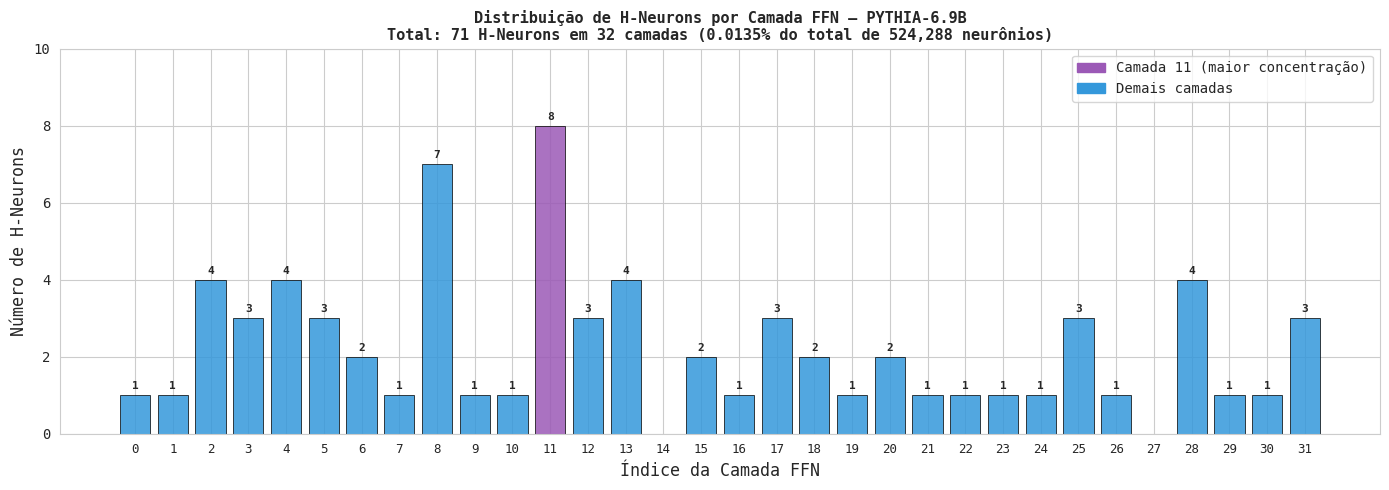

✓ Figura 1 salva: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fig1_h_neurons_por_camada.png


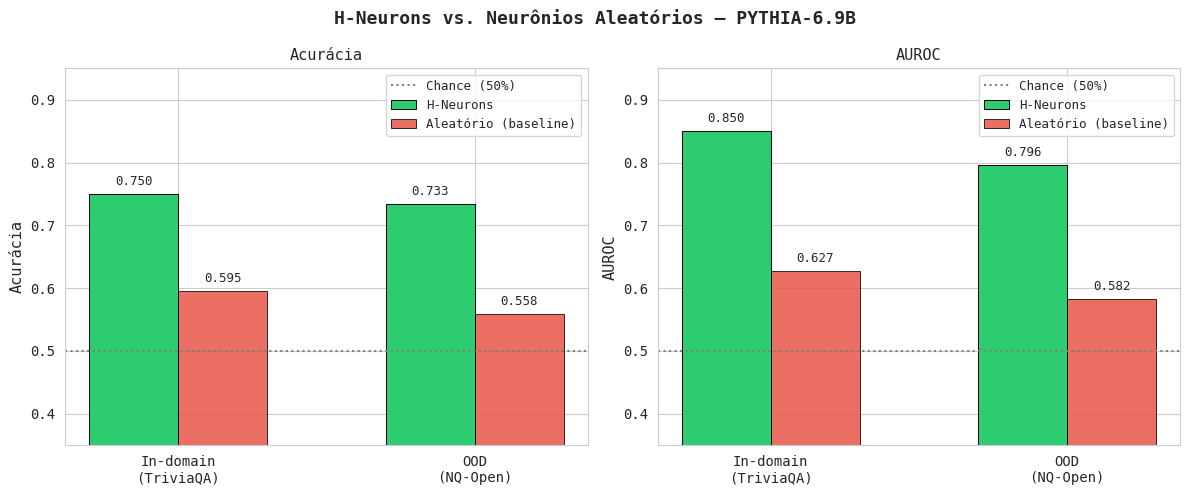

✓ Figura 2 salva: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fig2_h_neurons_vs_baseline.png


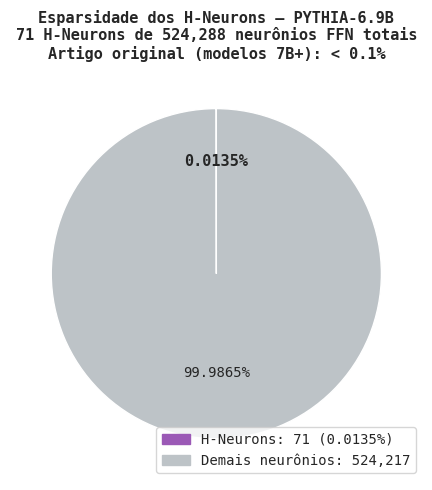

✓ Figura 3 salva: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fig3_esparsidade.png

TABELA DE RESULTADOS — PYTHIA-6.9B
Parâmetro                                  Valor
----------------------------------------------------------------------
Parâmetros totais                          6,857,302,016
Neurônios FFN totais                       524,288
Camadas FFN                                32
H-Neurons identificados                    71
H-Neurons (% do total)                     0.0135%
Referência artigo original                 < 0.1000%
----------------------------------------------------------------------
Acurácia in-domain (TriviaQA)              0.7500
Acurácia baseline in-domain                0.5951
Ganho de acurácia in-domain                +0.1549
----------------------------------------------------------------------
AUROC in-domain (TriviaQA)                 0.8500
AUROC baseline in-domain                   0.6271
Ganho de AUROC in-domain                   +0.222

In [51]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ============================================================
# VISUALIZAÇÕES DO MODELO ATUAL
# ============================================================

results_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_final_results.json"

with open(results_path, "r", encoding="utf-8") as f:
    r = json.load(f)

model_title = r.get("model_short", MODEL_SHORT).upper()

print(f"✓ Resultados carregados: {results_path}")
print(f"  Modelo: {r['model_id']}")
print(f"  H-Neurons: {r['n_h_neurons']} ({r['pct_h_neurons']:.4f}%)")

random_indomain = r.get("indomain_random_mean") or r.get("indomain_random")
assert random_indomain is not None, "Baseline aleatório in-domain não encontrado."

ood = r.get("ood_nq_open", {})
ood_random_mean = ood.get("ood_random_mean", {})
ood_random_rep = ood.get("ood_random_baseline_repeated", {})

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "monospace"

COLORS = {
    "h_neurons": "#2ecc71",
    "random": "#e74c3c",
    "reference": "#e67e22",
    "layer": "#3498db",
    "highlight": "#9b59b6",
}

# ============================================================
# FIGURA 1 — Distribuição de H-Neurons por camada
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

by_layer = r["h_neurons_by_layer"]
n_layers = r["n_ffn_layers"]
layers = list(range(n_layers))
counts = [by_layer.get(str(l), 0) for l in layers]

max_layer = int(max(by_layer, key=lambda k: by_layer[k]))
bar_colors = [
    COLORS["highlight"] if l == max_layer else COLORS["layer"]
    for l in layers
]

bars = ax.bar(
    layers,
    counts,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)

for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(count),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

ax.set_xlabel("Índice da Camada FFN", fontsize=12)
ax.set_ylabel("Número de H-Neurons", fontsize=12)
ax.set_title(
    f"Distribuição de H-Neurons por Camada FFN — {model_title}\n"
    f"Total: {r['n_h_neurons']} H-Neurons em {n_layers} camadas "
    f"({r['pct_h_neurons']:.4f}% do total de {r['total_ffn_neurons']:,} neurônios)",
    fontsize=11,
    fontweight="bold",
)
ax.set_xticks(layers)
ax.set_xticklabels([str(l) for l in layers], fontsize=9)

patch_h = mpatches.Patch(
    color=COLORS["highlight"],
    label=f"Camada {max_layer} (maior concentração)",
)
patch_n = mpatches.Patch(
    color=COLORS["layer"],
    label="Demais camadas",
)
ax.legend(handles=[patch_h, patch_n], fontsize=10)
ax.set_ylim(0, max(counts) + 2 if max(counts) > 0 else 1)

plt.tight_layout()
fig1_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fig1_h_neurons_por_camada.png"
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 1 salva: {fig1_path}")

# ============================================================
# FIGURA 2 — H-Neurons vs. Baseline: Acurácia e AUROC
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"H-Neurons vs. Neurônios Aleatórios — {model_title}",
    fontsize=13,
    fontweight="bold",
)

metrics = ["accuracy", "auroc"]
labels = ["Acurácia", "AUROC"]
domains = ["In-domain\n(TriviaQA)", "OOD\n(NQ-Open)"]

for ax, metric, label in zip(axes, metrics, labels):
    val_h_indomain = r["indomain_h_neurons"][metric]
    val_h_ood = ood.get(f"nq_open_{metric}", None)

    val_rand_indomain = random_indomain[metric]
    val_rand_ood = ood_random_mean.get(metric, 0.50)

    x = np.array([0, 1])
    width = 0.3

    bars_h = ax.bar(
        x - width / 2,
        [
            val_h_indomain if val_h_indomain is not None else 0,
            val_h_ood if val_h_ood is not None else 0,
        ],
        width,
        label="H-Neurons",
        color=COLORS["h_neurons"],
        edgecolor="black",
        linewidth=0.7,
    )

    bars_r = ax.bar(
        x + width / 2,
        [
            val_rand_indomain if val_rand_indomain is not None else 0,
            val_rand_ood if val_rand_ood is not None else 0.50,
        ],
        width,
        label="Aleatório (baseline)",
        color=COLORS["random"],
        edgecolor="black",
        linewidth=0.7,
        alpha=0.8,
    )

    ax.axhline(
        0.5,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label="Chance (50%)",
    )

    for bar in list(bars_h) + list(bars_r):
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(domains, fontsize=10)
    ax.set_ylim(0.35, 0.95)
    ax.legend(fontsize=9)

plt.tight_layout()
fig2_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fig2_h_neurons_vs_baseline.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 2 salva: {fig2_path}")

# ============================================================
# FIGURA 3 — Esparsidade: H-Neurons vs. total de neurônios
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

total = r["total_ffn_neurons"]
n_h = r["n_h_neurons"]
n_rest = total - n_h

sizes = [n_h, n_rest]
clrs = [COLORS["highlight"], "#bdc3c7"]
explode = (0.08, 0)

wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    colors=clrs,
    autopct="%1.4f%%",
    startangle=90,
    textprops={"fontsize": 10},
)

autotexts[0].set_fontweight("bold")
autotexts[0].set_fontsize(11)

ax.set_title(
    f"Esparsidade dos H-Neurons — {model_title}\n"
    f"{n_h} H-Neurons de {total:,} neurônios FFN totais\n"
    f"Artigo original (modelos 7B+): < 0.1%",
    fontsize=11,
    fontweight="bold",
)

patch_h = mpatches.Patch(
    color=COLORS["highlight"],
    label=f"H-Neurons: {n_h} ({r['pct_h_neurons']:.4f}%)",
)
patch_r = mpatches.Patch(
    color="#bdc3c7",
    label=f"Demais neurônios: {n_rest:,}",
)

ax.legend(handles=[patch_h, patch_r], fontsize=10, loc="lower right")

plt.tight_layout()
fig3_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fig3_esparsidade.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 3 salva: {fig3_path}")

# ============================================================
# TABELA — Resumo completo dos resultados
# ============================================================

print("\n" + "=" * 70)
print(f"TABELA DE RESULTADOS — {model_title}")
print("=" * 70)
print(f"{'Parâmetro':<42} {'Valor'}")
print("-" * 70)

print(f"{'Parâmetros totais':<42} {r['total_parameters']:,}")
print(f"{'Neurônios FFN totais':<42} {r['total_ffn_neurons']:,}")
print(f"{'Camadas FFN':<42} {r['n_ffn_layers']}")
print(f"{'H-Neurons identificados':<42} {r['n_h_neurons']}")
print(f"{'H-Neurons (% do total)':<42} {r['pct_h_neurons']:.4f}%")
print(f"{'Referência artigo original':<42} < 0.1000%")

print("-" * 70)
print(f"{'Acurácia in-domain (TriviaQA)':<42} {r['indomain_h_neurons']['accuracy']:.4f}")
print(f"{'Acurácia baseline in-domain':<42} {random_indomain['accuracy']:.4f}")
print(
    f"{'Ganho de acurácia in-domain':<42} "
    f"{r['indomain_h_neurons']['accuracy'] - random_indomain['accuracy']:+.4f}"
)

print("-" * 70)
print(f"{'AUROC in-domain (TriviaQA)':<42} {r['indomain_h_neurons']['auroc']:.4f}")
print(f"{'AUROC baseline in-domain':<42} {random_indomain['auroc']:.4f}")
print(
    f"{'Ganho de AUROC in-domain':<42} "
    f"{r['indomain_h_neurons']['auroc'] - random_indomain['auroc']:+.4f}"
)

print("-" * 70)

ood_acc = ood.get("nq_open_accuracy")
ood_auroc = ood.get("nq_open_auroc")

print(f"{'Acurácia OOD (NQ-Open)':<42} {ood_acc:.4f}" if ood_acc is not None else f"{'Acurácia OOD (NQ-Open)':<42} NA")

if "accuracy" in ood_random_mean:
    print(f"{'Acurácia baseline OOD':<42} {ood_random_mean['accuracy']:.4f}")
    print(
        f"{'Ganho de acurácia OOD':<42} "
        f"{ood_acc - ood_random_mean['accuracy']:+.4f}"
    )

print(f"{'AUROC OOD (NQ-Open)':<42} {ood_auroc:.4f}" if ood_auroc is not None else f"{'AUROC OOD (NQ-Open)':<42} NA")

if "auroc" in ood_random_mean:
    print(f"{'AUROC baseline OOD médio':<42} {ood_random_mean['auroc']:.4f}")
    print(
        f"{'Ganho de AUROC OOD':<42} "
        f"{ood_auroc - ood_random_mean['auroc']:+.4f}"
    )

if "auroc" in ood_random_rep:
    print(f"{'AUROC baseline OOD std':<42} {ood_random_rep['auroc']['std']:.4f}")
    print(f"{'p-valor empírico AUROC OOD':<42} {ood_random_rep['auroc']['p_value']:.4f}")

print(f"{'Camada com mais H-Neurons':<42} Camada {max_layer} ({max(counts)} neurônios)")
print("=" * 70)

print(f"\n✓ Figuras salvas em: {CONFIG['results_dir']}")
print(f"  {fig1_path}")
print(f"  {fig2_path}")
print(f"  {fig3_path}")

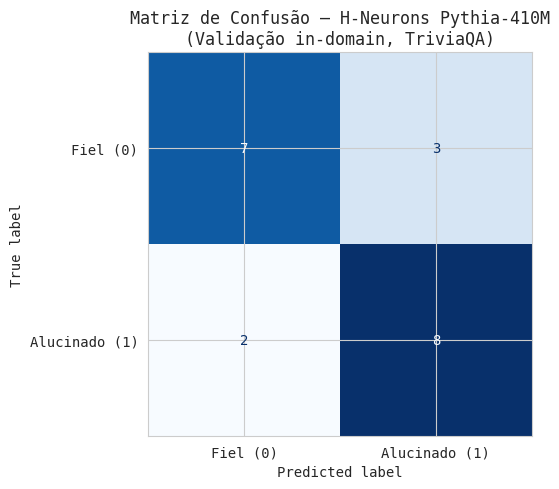

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fiel (0)", "Alucinado (1)"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — H-Neurons Pythia-410M\n(Validação in-domain, TriviaQA)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig4_matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

## Bloco 10 — Análise Comparativa entre Modelos

**Este bloco só deve ser executado após rodar os Blocos 1–9 para os três modelos (pythia-70m, pythia-160m, pythia-410m).**

Lê os arquivos de resultados salvos e gera visualizações comparativas que respondem às hipóteses do projeto:

- **H1:** H-Neurons existem nos três modelos? (gráfico de acurácia vs. baseline)
- **H2:** A acurácia aumenta com o tamanho do modelo? (curva de escala)
- **H3:** A proporção de H-Neurons se mantém? (análise de esparsidade)
- **Bônus:** Os H-Neurons se concentram nas mesmas camadas relativas? (heatmap)

In [53]:
# Carrega resultados dos três modelos
results_dir = CONFIG["results_dir"]
model_names = ["pythia-70m", "pythia-160m", "pythia-410m","pythia-1b","pythia-1.4b","pythia-2.8b","pythia-6.9b"]
# model_names = ["pythia-160m", "pythia-410m"]

all_results = {}
for model_name in model_names:
    path = f"{results_dir}/{model_name}_final_results.json"
    if os.path.exists(path):
        with open(path) as f:
            all_results[model_name] = json.load(f)
        print(f"✓ Carregado: {model_name}")
    else:
        print(f"⚠ Não encontrado: {path} — execute o pipeline para este modelo primeiro")

available_models = list(all_results.keys())
print(f"\nModelos disponíveis para análise: {available_models}")

✓ Carregado: pythia-70m
✓ Carregado: pythia-160m
✓ Carregado: pythia-410m
✓ Carregado: pythia-1b
✓ Carregado: pythia-1.4b
✓ Carregado: pythia-2.8b
✓ Carregado: pythia-6.9b

Modelos disponíveis para análise: ['pythia-70m', 'pythia-160m', 'pythia-410m', 'pythia-1b', 'pythia-1.4b', 'pythia-2.8b', 'pythia-6.9b']


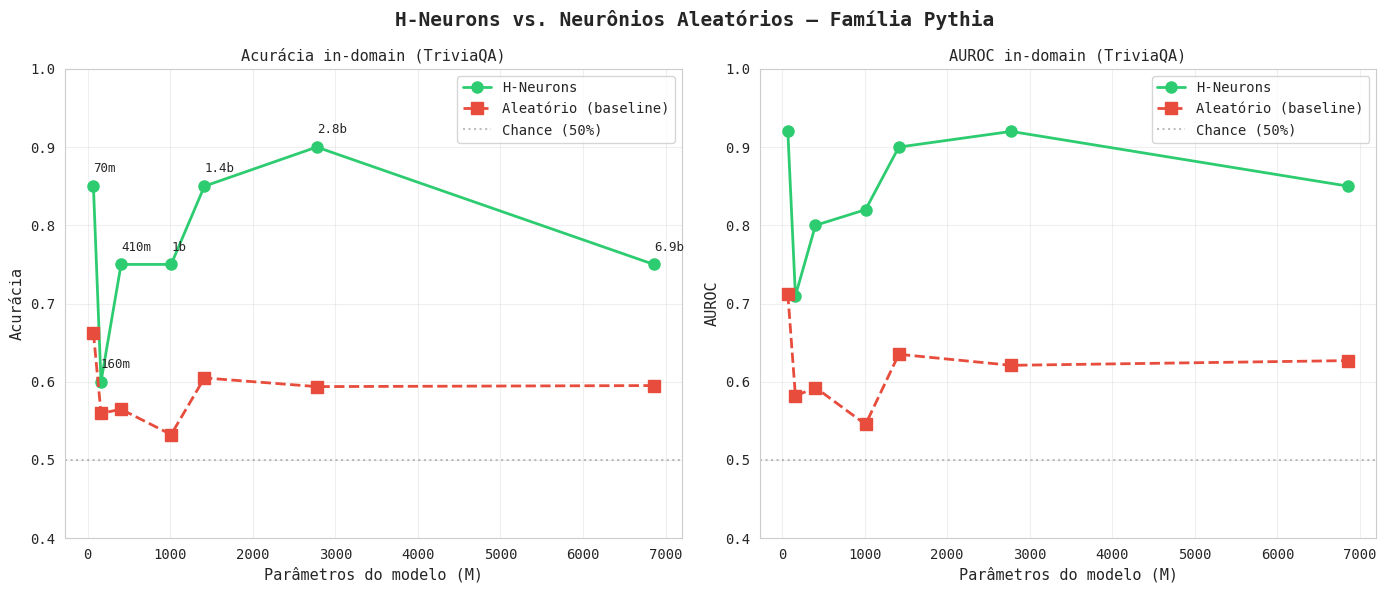

✓ Figura 1 salva em: /content/drive/MyDrive/IA376/h_neurons_project/fig1_accuracy_by_scale.png


In [54]:
# === FIGURA 1: Acurácia e AUROC por modelo (H-Neurons vs. Baseline) ===

if len(available_models) < 1:
    print("Nenhum resultado disponível ainda.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("H-Neurons vs. Neurônios Aleatórios — Família Pythia",
                 fontsize=14, fontweight="bold")

    # Prepara dados para o gráfico
    params = [all_results[m]["total_parameters"] / 1e6 for m in available_models]  # em milhões
    acc_h = [all_results[m]["indomain_h_neurons"]["accuracy"] for m in available_models]
    acc_r = [all_results[m]["indomain_random_mean"]["accuracy"] for m in available_models]
    auroc_h = [all_results[m]["indomain_h_neurons"]["auroc"] for m in available_models]
    auroc_r = [all_results[m]["indomain_random_mean"]["auroc"] for m in available_models]

    # Subplot 1: Acurácia
    ax = axes[0]
    ax.plot(params, acc_h, 'o-', color='#2ecc71', linewidth=2,
            markersize=8, label='H-Neurons')
    ax.plot(params, acc_r, 's--', color='#e74c3c', linewidth=2,
            markersize=8, label='Aleatório (baseline)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (50%)')
    ax.set_xlabel("Parâmetros do modelo (M)", fontsize=11)
    ax.set_ylabel("Acurácia", fontsize=11)
    ax.set_title("Acurácia in-domain (TriviaQA)", fontsize=11)
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

    for i, m in enumerate(available_models):
        ax.annotate(m.split('-')[1], (params[i], acc_h[i]),
                    textcoords="offset points", xytext=(0, 10), fontsize=9)

    # Subplot 2: AUROC
    ax = axes[1]
    ax.plot(params, auroc_h, 'o-', color='#2ecc71', linewidth=2,
            markersize=8, label='H-Neurons')
    ax.plot(params, auroc_r, 's--', color='#e74c3c', linewidth=2,
            markersize=8, label='Aleatório (baseline)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (50%)')
    ax.set_xlabel("Parâmetros do modelo (M)", fontsize=11)
    ax.set_ylabel("AUROC", fontsize=11)
    ax.set_title("AUROC in-domain (TriviaQA)", fontsize=11)
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = f"{results_dir}/fig1_accuracy_by_scale.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 1 salva em: {fig_path}")

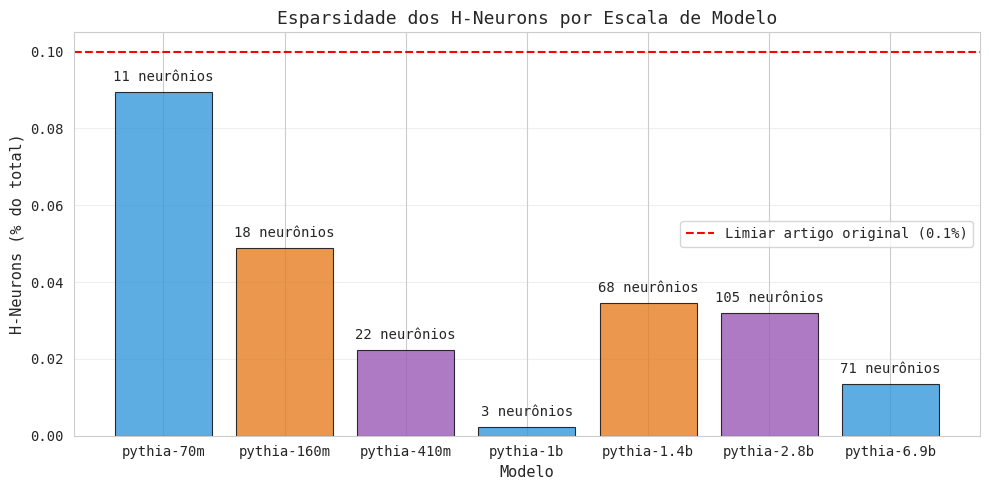

✓ Figura 2 salva em: /content/drive/MyDrive/IA376/h_neurons_project/fig2_sparsity_by_scale.png


In [55]:
# === FIGURA 2: Esparsidade dos H-Neurons por modelo ===

if len(available_models) >= 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    pct_h = [all_results[m]["pct_h_neurons"] for m in available_models]
    n_h = [all_results[m]["n_h_neurons"] for m in available_models]
    colors = ['#3498db', '#e67e22', '#9b59b6']

    bars = ax.bar(available_models, pct_h, color=colors[:len(available_models)],
                  alpha=0.8, edgecolor='black', linewidth=0.8)

    # Linha de referência: 0.1% (limiar do artigo original)
    ax.axhline(0.1, color='red', linestyle='--', linewidth=1.5,
               label='Limiar artigo original (0.1%)')

    # Anota o número absoluto de H-Neurons em cada barra
    for bar, n in zip(bars, n_h):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{n} neurônios', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel("Modelo", fontsize=11)
    ax.set_ylabel("H-Neurons (% do total)", fontsize=11)
    ax.set_title("Esparsidade dos H-Neurons por Escala de Modelo", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig_path = f"{results_dir}/fig2_sparsity_by_scale.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 2 salva em: {fig_path}")

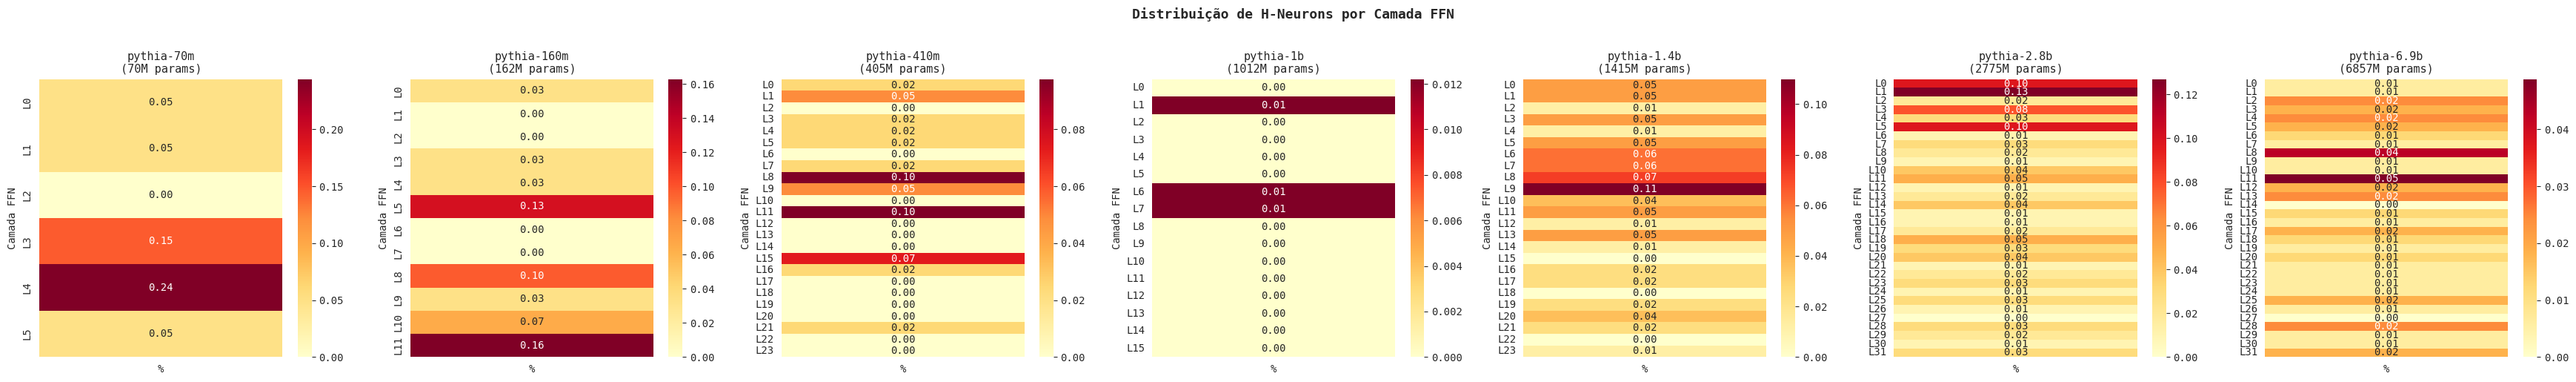

✓ Figura 3 salva em: /content/drive/MyDrive/IA376/h_neurons_project/fig3_h_neurons_by_layer.png


In [56]:
# === FIGURA 3: Distribuição de H-Neurons por camada (heatmap) ===
# Mostra em quais camadas FFN os H-Neurons se concentram
# e se esse padrão é consistente entre os modelos

if len(available_models) >= 1:
    fig, axes = plt.subplots(1, len(available_models),
                              figsize=(5 * len(available_models), 5))

    if len(available_models) == 1:
        axes = [axes]  # garante que axes seja sempre lista

    for ax, model_name in zip(axes, available_models):
        res = all_results[model_name]
        by_layer = res["h_neurons_by_layer"]

        # Converte para arrays ordenados por índice de camada
        layers = sorted([int(k) for k in by_layer.keys()])
        counts = [by_layer[str(l)] for l in layers]

        # Normaliza pelo número de neurônios por camada para comparação justa
        total_per_layer = res["total_ffn_neurons"] / max(len(layers), 1)
        pcts = [c / total_per_layer * 100 for c in counts]

        # Heatmap vertical: camada no eixo y, intensidade = % de H-Neurons
        heatmap_data = np.array(pcts).reshape(-1, 1)
        sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd',
                    yticklabels=[f"L{l}" for l in layers],
                    xticklabels=["%"],
                    annot=True, fmt='.2f', cbar=True)

        ax.set_title(f"{model_name}\n({res['total_parameters']/1e6:.0f}M params)",
                     fontsize=11)
        ax.set_ylabel("Camada FFN")

    fig.suptitle("Distribuição de H-Neurons por Camada FFN",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_path = f"{results_dir}/fig3_h_neurons_by_layer.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 3 salva em: {fig_path}")

In [57]:
# === TABELA FINAL: Resumo comparativo ===

print("\n" + "=" * 90)
print("TABELA COMPARATIVA FINAL — H-NEURONS NA FAMÍLIA PYTHIA")
print("=" * 90)
print(f"{'Modelo':<18} {'Params':<10} {'H-Neur.':<10} {'%Total':<10} "
      f"{'Acc H':<10} {'Acc Rand':<10} {'AUROC H':<10} {'AUROC OOD'}")
print("-" * 90)

for model_name in available_models:
    r = all_results[model_name]
    ood_auroc = r["ood_nq_open"].get("nq_open_auroc") or 0.0
    print(
        f"{model_name:<18} "
        f"{r['total_parameters']/1e6:.0f}M{'':<5} "
        f"{r['n_h_neurons']:<10} "
        f"{r['pct_h_neurons']:.4f}%{'':<2} "
        f"{r['indomain_h_neurons']['accuracy']:.4f}{'':<4} "
        f"{r['indomain_random_mean']['accuracy']:.4f}{'':<4} "
        f"{r['indomain_h_neurons']['auroc']:.4f}{'':<4} "
        f"{ood_auroc:.4f}"
    )

print("=" * 90)
print("\nInterpretação:")
print("  Acc H > Acc Rand → H-Neurons carregam sinal real de alucinação")
print("  %Total próximo de 0.1% → esparsidade compatível com o artigo original")
print("  AUROC OOD > 0.5 → generalização para domínios não vistos")
print("  Tendência crescente com escala → fenômeno se fortalece com mais parâmetros")


TABELA COMPARATIVA FINAL — H-NEURONS NA FAMÍLIA PYTHIA
Modelo             Params     H-Neur.    %Total     Acc H      Acc Rand   AUROC H    AUROC OOD
------------------------------------------------------------------------------------------
pythia-70m         70M      11         0.0895%   0.8500     0.6626     0.9200     0.5000
pythia-160m        162M      18         0.0488%   0.6000     0.5596     0.7100     0.7244
pythia-410m        405M      22         0.0224%   0.7500     0.5648     0.8000     0.8444
pythia-1b          1012M      3          0.0023%   0.7500     0.5325     0.8200     0.7956
pythia-1.4b        1415M      68         0.0346%   0.8500     0.6049     0.9000     0.8400
pythia-2.8b        2775M      105        0.0320%   0.9000     0.5938     0.9200     0.8978
pythia-6.9b        6857M      71         0.0135%   0.7500     0.5951     0.8500     0.7956

Interpretação:
  Acc H > Acc Rand → H-Neurons carregam sinal real de alucinação
  %Total próximo de 0.1% → esparsidade compa

### Template de Discussão dos Resultados

Use esta seção para registrar a interpretação dos resultados encontrados.

**Sobre a existência de H-Neurons (H1):**
> *[Preencher após execução: os H-Neurons foram identificados nos três modelos? A acurácia supera o baseline aleatório em todos os casos?]*

**Sobre a relação com escala (H2):**
> *[Preencher: a acurácia e o AUROC aumentam monotonicamente de 70M para 410M? Qual a magnitude do ganho?]*

**Sobre a esparsidade:**
> *[Preencher: a proporção de H-Neurons (% do total) é consistente entre os modelos, ou varia? Está próxima do limiar de 0.1% reportado no artigo para modelos maiores?]*

**Sobre a distribuição por camada:**
> *[Preencher: os H-Neurons se concentram em camadas específicas? O padrão é consistente entre os três modelos?]*

**Sobre a generalização (H3):**
> *[Preencher: o AUROC no NQ-Open supera 0.5? Qual a magnitude da queda em relação ao in-domain?]*

**Conclusão geral:**
> *[Preencher: os resultados suportam H1 (existência), H2 (escala) e H3 (generalização)? O que isso implica sobre a natureza dos H-Neurons em modelos pequenos?]*

---
*Notebook desenvolvido para o projeto da disciplina IA376N — Inteligência Artificial Generativa, UNICAMP 2026.*
*Baseado em: Gao et al. (2025). H-Neurons: On the Existence, Impact, and Origin of Hallucination-Associated Neurons in LLMs. arXiv:2512.01797.*